## Emotional Speech Recognition

In [ ]:
# Runtime: GPU (for spectrogram CNNs); Python 3.10+
!pip -q install librosa torchaudio torch torchvision torchaudio --upgrade
!pip -q install opensmile  # Python wrapper around openSMILE features
!pip -q install pandas scikit-learn evaluate torchmetrics
!pip -q install torch-audiomentations
!pip -q install librosa soundfile pandas numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 21.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Check the contents of the datasets folder
print("Contents of the datasets folder:")

OUT_DIR = "/content/drive/MyDrive/datasets/CSVs"

# Define variables for the paths to the relevant CSV files
# Assuming OUT_DIR has been defined in previous cells
if 'OUT_DIR' in globals():
    MERGED_MANIFEST_PATH = f"{OUT_DIR}/manifest_all.csv"
    MERGED_SPLIT_MANIFEST_PATH = f"{OUT_DIR}/manifest_all_splits.csv"
    RESAMPLED_MANIFEST_PATH = f"{OUT_DIR}/manifest_all_resampled.csv"
    TRIMMED_MANIFEST_PATH = f"{OUT_DIR}/manifest_all_trimmed.csv"
    CLEANED_MANIFEST_PATH = f"{OUT_DIR}/manifest_all_cleaned.csv"
    SEGMENTED_MANIFEST_PATH = f"{OUT_DIR}/manifest_all_segmented.csv"


    print("\nDefined variables for CSV manifest paths:")
    print(f"MERGED_MANIFEST_PATH: {MERGED_MANIFEST_PATH}")
    print(f"MERGED_SPLIT_MANIFEST_PATH: {MERGED_SPLIT_MANIFEST_PATH}")
    print(f"RESAMPLED_MANIFEST_PATH: {RESAMPLED_MANIFEST_PATH}")
    print(f"TRIMMED_MANIFEST_PATH: {TRIMMED_MANIFEST_PATH}")
    print(f"CLEANED_MANIFEST_PATH: {CLEANED_MANIFEST_PATH}")
    print(f"SEGMENTED_MANIFEST_PATH: {SEGMENTED_MANIFEST_PATH}")

else:
    print("OUT_DIR variable not found. Please ensure the data preparation cells have been run.")

Contents of the datasets folder:

Defined variables for CSV manifest paths:
MERGED_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all.csv
MERGED_SPLIT_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all_splits.csv
RESAMPLED_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all_resampled.csv
TRIMMED_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all_trimmed.csv
CLEANED_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all_cleaned.csv
SEGMENTED_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all_segmented.csv


## 1- Data Preparation

We build one unified manifest.csv from IEMOCAP + RAVDESS + CREMA-D databases, harmonize labels, and add whatever metadata is available (gender, age, accent/ethnicity). The code is defensive (skips what it can nott find) and prints a short summary at the end.

In [ ]:
# --- Install libraries ---
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install librosa soundfile pandas numpy scikit-learn torchmetrics matplotlib tqdm

# --- Mount Drive & prepare folders ---
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/datasets"
OUT_DIR  = "/content/drive/MyDrive/datasets/CSVs"          # where we'll save the CSVs

import os
os.makedirs(OUT_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR :", OUT_DIR)

Mounted at /content/drive
DATA_DIR: /content/drive/MyDrive/datasets
OUT_DIR : /content/drive/MyDrive/datasets/CSVs


### Download Datasets:

Helpers (common label map + quick summary):

In [ ]:
import os, re, glob, pandas as pd
from pathlib import Path

def summarize_df(df: pd.DataFrame, title=""):
    print("\n====", title, "====")
    print("Rows:", len(df))
    if "label" in df.columns:
        print("\nLabels:")
        display(df["label"].value_counts().to_frame("count"))
    if {"gender","age","ethnicity"} <= set(df.columns):
        print("\nGender:")
        display(df["gender"].value_counts(dropna=False).to_frame("count"))
        print("\nAge (non-null):", df["age"].notna().sum())
        print("\nEthnicity (top 10):")
        display(df["ethnicity"].value_counts(dropna=False).head(10).to_frame("count"))
    display(df.head(3))

def add_row(rows, **kw):
    # Standard columns for all manifests
    default = dict(
        path=None, dataset=None, speaker_id=None, gender=None, age=None,
        accent=None, ethnicity=None, label=None, label_raw=None,
        valence=None, arousal=None, dominance=None, split=None
    )
    default.update(kw)
    rows.append(default)

RAVDESS → manifest_ravdess.csv (inspect alone):

In [ ]:
# Download (official Zenodo record)
!wget -O RAVDESS_speech.zip "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip?download=1"
!unzip -q RAVDESS_speech.zip -d /content/RAVDESS

--2025-09-24 14:51:58--  https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.45.92, 188.185.43.25, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1188976/files/Audio_Speech_Actors_01-24.zip [following]
--2025-09-24 14:52:00--  https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 208468073 (199M) [application/octet-stream]
Saving to: ‘RAVDESS_speech.zip’

RAVDESS_speech.zip  100%[===================>] 198.81M  1.12MB/s    in 4m 44s  

2025-09-24 14:56:44 (717 KB/s) - ‘RAVDESS_speech.zip’ saved [208468073/208468073]



In [ ]:
def build_manifest_ravdess(base_dir: str) -> pd.DataFrame:
    rows = []
    base = Path(base_dir) / "RAVDESS"
    if not base.exists():
        print("RAVDESS not found at:", base)
        return pd.DataFrame()

    # File pattern: MM-VC-EM-IT-ST-RP-AC.wav
    RAVDESS_EMO = {"01":"neutral","02":"calm","03":"happy","04":"sad",
                   "05":"angry","06":"fearful","07":"disgust","08":"surprised"}

    wavs = list(base.rglob("*.wav"))
    for p in wavs:
        m = re.search(r"(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})\.wav$", p.name)
        if not m:
            continue
        em_id = m.group(3)
        actor = int(m.group(7))
        label_raw = RAVDESS_EMO.get(em_id, "other")
        gender = "male" if actor % 2 == 1 else "female"

        add_row(rows,
            path=str(p), dataset="RAVDESS",
            speaker_id=f"RAV_{actor:02d}", gender=gender, age=None,
            accent="North American", ethnicity=None,
            label=label_raw, label_raw=label_raw,
            valence=None, arousal=None, dominance=None, split=None
        )
    return pd.DataFrame(rows)

# Modify this line to use the correct path
rav_df = build_manifest_ravdess("/content")
rav_csv = f"{OUT_DIR}/manifest_ravdess.csv"
rav_df.to_csv(rav_csv, index=False)
summarize_df(rav_df, "RAVDESS")
print("Saved:", rav_csv)


==== RAVDESS ====
Rows: 1440

Labels:


,count
label,
happy,192
surprised,192
angry,192
disgust,192
calm,192
sad,192
fearful,192
neutral,96



Gender:


,count
gender,
female,720
male,720



Age (non-null): 0

Ethnicity (top 10):


,count
ethnicity,
None,1440


,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split
0,/content/RAVDESS/Actor_02/03-01-03-01-01-01-02...,RAVDESS,RAV_02,female,None,North American,None,happy,happy,None,None,None,None
1,/content/RAVDESS/Actor_02/03-01-03-02-02-02-02...,RAVDESS,RAV_02,female,None,North American,None,happy,happy,None,None,None,None
2,/content/RAVDESS/Actor_02/03-01-08-02-02-01-02...,RAVDESS,RAV_02,female,None,North American,None,surprised,surprised,None,None,None,None


Saved: /content/drive/MyDrive/datasets/CSVs/manifest_ravdess.csv


Emo-DB → manifest_emodb.csv (inspect alone):

In [ ]:
!wget -O emodb.zip "http://emodb.bilderbar.info/download/download.zip"
!unzip -q emodb.zip -d /content/EmoDB

--2025-09-24 14:56:51--  http://emodb.bilderbar.info/download/download.zip
Resolving emodb.bilderbar.info (emodb.bilderbar.info)... 85.13.147.80
Connecting to emodb.bilderbar.info (emodb.bilderbar.info)|85.13.147.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40567066 (39M) [application/zip]
Saving to: ‘emodb.zip’

emodb.zip           100%[===================>]  38.69M  1.05MB/s    in 28s     

2025-09-24 14:57:19 (1.40 MB/s) - ‘emodb.zip’ saved [40567066/40567066]



In [ ]:
def build_manifest_emodb(base_dir: str) -> pd.DataFrame:
    rows = []
    wav_dir = Path(base_dir) / "EmoDB" / "wav"
    if not wav_dir.exists():
        print("EmoDB not found at:", wav_dir)
        return pd.DataFrame()

    emo_map = {"W":"anger","L":"boredom","E":"disgust","A":"fear","F":"happiness","T":"sadness","N":"neutral"}

    for p in sorted(wav_dir.glob("*.wav")):
        stem = p.stem  # e.g., '03a01Fa'
        if len(stem) < 7:
            continue
        speaker = stem[0:2]
        emo_letter = stem[5:6].upper()
        label = emo_map.get(emo_letter, "other")

        add_row(rows,
            path=str(p), dataset="EmoDB",
            speaker_id=f"EMO_{speaker}", gender=None, age=None,
            accent="German", ethnicity=None,
            label=label, label_raw=emo_letter,
            valence=None, arousal=None, dominance=None, split=None
        )
    return pd.DataFrame(rows)

emodb_df = build_manifest_emodb("/content")
emodb_csv = f"{OUT_DIR}/emodb.csv"
emodb_df.to_csv(emodb_csv, index=False)
summarize_df(emodb_df, "Emo-DB")
print("Saved:", emodb_csv)


==== Emo-DB ====
Rows: 535

Labels:


,count
label,
anger,127
boredom,81
neutral,79
happiness,71
fear,69
sadness,62
disgust,46



Gender:


,count
gender,
None,535



Age (non-null): 0

Ethnicity (top 10):


,count
ethnicity,
None,535


,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split
0,/content/EmoDB/wav/03a01Fa.wav,EmoDB,EMO_03,None,None,German,None,happiness,F,None,None,None,None
1,/content/EmoDB/wav/03a01Nc.wav,EmoDB,EMO_03,None,None,German,None,neutral,N,None,None,None,None
2,/content/EmoDB/wav/03a01Wa.wav,EmoDB,EMO_03,None,None,German,None,anger,W,None,None,None,None


Saved: /content/drive/MyDrive/datasets/CSVs/emodb.csv


4) CREMA-D → manifest_cremad.csv (inspect alone):

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/datasets/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d ejlok1/cremad -p "/content/drive/MyDrive/datasets/CREMA-D" --unzip

# Alternative download method for CREMA-D if Kaggle authentication is an issue
#!wget -O /content/drive/MyDrive/datasets/CREMA-D/AudioWAV.zip "https://github.com/CheyneyComputerScience/CREMA-D/raw/master/AudioWAV.zip"
#!unzip -q "/content/drive/MyDrive/datasets/CREMA-D/AudioWAV.zip" -d "/content/drive/MyDrive/datasets/CREMA-D/"

Dataset URL: https://www.kaggle.com/datasets/ejlok1/cremad
License(s): ODC Attribution License (ODC-By)
 96% 434M/451M [00:02<00:00, 118MB/s]
100% 451M/451M [00:02<00:00, 167MB/s]


In [ ]:
# Create the target directory before attempting to download
!mkdir -p "/content/drive/MyDrive/datasets/CREMA-D/"
!wget -O "/content/drive/MyDrive/datasets/CREMA-D/VideoDemographics.csv" \
  "https://raw.githubusercontent.com/CheyneyComputerScience/CREMA-D/master/VideoDemographics.csv"

--2025-09-24 14:58:47--  https://raw.githubusercontent.com/CheyneyComputerScience/CREMA-D/master/VideoDemographics.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4033 (3.9K) [text/plain]
Saving to: ‘/content/drive/MyDrive/datasets/CREMA-D/VideoDemographics.csv’

/content/drive/MyDr 100%[===================>]   3.94K  --.-KB/s    in 0.001s  

2025-09-24 14:58:48 (4.37 MB/s) - ‘/content/drive/MyDrive/datasets/CREMA-D/VideoDemographics.csv’ saved [4033/4033]



In [ ]:
# Create the target directory before attempting to list files
!mkdir -p "/content/drive/MyDrive/datasets/CREMA-D/AudioWAV"
wav_dir = "/content/drive/MyDrive/datasets/CREMA-D/AudioWAV"
print("Number of wav files:", len(os.listdir(wav_dir)))

Number of wav files: 7442


In [ ]:
# Merge CREMA-D audio (AudioWAV) with demographics (VideoDemographics.csv) into cremad.csv

import pandas as pd, re, os
from pathlib import Path

BASE_DIR = DATA_DIR  # <- keep using your existing DATA_DIR
OUT_CSV  = f"{OUT_DIR}/cremad.csv"

def build_manifest_cremad(base_dir: str) -> pd.DataFrame:
    rows = []
    audio_dir = Path(base_dir) / "CREMA-D" / "AudioWAV"
    demo_csv  = Path(base_dir) / "CREMA-D" / "VideoDemographics.csv"  # you said you downloaded this one

    # load demographics (GitHub file has columns: ActorID, Age, Sex, Race)
    demo = None
    if demo_csv.exists():
        demo = pd.read_csv(demo_csv)
        demo.columns = [c.strip().lower() for c in demo.columns]  # -> actorid, age, sex, race
        # ensure ActorID is int and use it as index
        demo["actorid"] = pd.to_numeric(demo["actorid"], errors="coerce").astype("Int64")
        # light normalization
        demo["__gender__"]    = demo["sex"].map(lambda s: "male" if str(s).strip().lower() in ["m","male"] else ("female" if str(s).strip().lower() in ["f","female"] else None))
        demo["__age__"]       = pd.to_numeric(demo["age"], errors="coerce")
        demo["__ethnicity__"] = demo["race"].astype(str).str.strip().replace({
            "African American":"Black/African American",
            "Caucasian":"White",
            "European American":"White",
            "Hispanic":"Hispanic/Latino",
            "Latino":"Hispanic/Latino",
        })
        demo = demo.set_index("actorid")
    else:
        print("⚠️ VideoDemographics.csv not found at:", demo_csv)

    emo_map = {"ANG":"angry","DIS":"disgust","FEA":"fear","HAP":"happy","NEU":"neutral","SAD":"sad"}

    if audio_dir.exists():
        for p in sorted(audio_dir.glob("*.wav")):
            # filename e.g., 1001_DFA_ANG_XX.wav
            parts = p.stem.split("_")
            if len(parts) < 3:
                continue
            actor = int(parts[0])             # 1001
            emo_raw = parts[2].upper()        # ANG
            label = emo_map.get(emo_raw[:3], "other")

            age = gender = ethnicity = None
            if demo is not None and actor in demo.index:
                r = demo.loc[actor]
                age       = r.get("__age__")
                gender    = r.get("__gender__")
                ethnicity = r.get("__ethnicity__")

            rows.append(dict(
                path=str(p),
                dataset="CREMA-D",
                speaker_id=f"CREMA_{actor}",
                gender=gender, age=age, ethnicity=ethnicity, accent="US English",
                label=label, label_raw=emo_raw,
                valence=None, arousal=None, dominance=None, split=None
            ))
    return pd.DataFrame(rows)

# Build + save
crema_df = build_manifest_cremad(BASE_DIR)
crema_df.to_csv(OUT_CSV, index=False)

# Quick confirmation
print("Saved:", OUT_CSV, "| rows:", len(crema_df))
if not crema_df.empty:
    print("Non-null demographics:", crema_df[["gender","age","ethnicity"]].notna().sum().to_dict())
crema_csv = f"{OUT_DIR}/cremad.csv"
summarize_df(crema_df, "CREMA-D")
print("Saved:", crema_csv)
if not crema_df.empty:
    display(crema_df.head(5))

Saved: /content/drive/MyDrive/datasets/CSVs/cremad.csv | rows: 7442
Non-null demographics: {'gender': 7442, 'age': 7442, 'ethnicity': 7442}

==== CREMA-D ====
Rows: 7442

Labels:


,count
label,
angry,1271
disgust,1271
fear,1271
happy,1271
sad,1271
neutral,1087



Gender:


,count
gender,
male,3930
female,3512



Age (non-null): 7442

Ethnicity (top 10):


,count
ethnicity,
White,4988
Black/African American,1804
Asian,568
Unknown,82


,path,dataset,speaker_id,gender,age,ethnicity,accent,label,label_raw,valence,arousal,dominance,split
0,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51,White,US English,angry,ANG,None,None,None,None
1,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51,White,US English,disgust,DIS,None,None,None,None
2,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51,White,US English,fear,FEA,None,None,None,None


Saved: /content/drive/MyDrive/datasets/CSVs/cremad.csv


,path,dataset,speaker_id,gender,age,ethnicity,accent,label,label_raw,valence,arousal,dominance,split
0,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51,White,US English,angry,ANG,None,None,None,None
1,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51,White,US English,disgust,DIS,None,None,None,None
2,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51,White,US English,fear,FEA,None,None,None,None
3,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51,White,US English,happy,HAP,None,None,None,None
4,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51,White,US English,neutral,NEU,None,None,None,None


Merge all datasets into 1 CSV

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Read back (defensive in case a dataset is missing)
parts = []
for pth in [rav_csv, emodb_csv, crema_csv]:
    if os.path.exists(pth) and os.path.getsize(pth) > 0:  # Check if file exists and is not empty
        try:
            parts.append(pd.read_csv(pth))
        except pd.errors.EmptyDataError:
            print(f"Skipping empty file: {pth}")
    else:
        print("Missing or empty:", pth)


merged = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
merged = merged[merged["path"].apply(lambda p: isinstance(p,str) and os.path.exists(p))].reset_index(drop=True)

# Optional: normalize label names (already standardized above, but keep one more pass)
label_norm = {
    "happiness":"happy", "happy":"happy",
    "sadness":"sad", "sad":"sad",
    "anger":"angry","angry":"angry",
    "fearful":"fear","fear":"fear",
    "disgust":"disgust",
    "surprised":"surprise","surprise":"surprise",
    "boredom":"boredom",
    "neutral":"neutral",
    "calm":"calm",
}
merged["label"] = merged["label"].str.lower().map(lambda x: label_norm.get(x, x))

# Save & summarize
merged_csv = f"{OUT_DIR}/manifest_all.csv"
merged.to_csv(merged_csv, index=False)
summarize_df(merged, "MERGED (RAVDESS + EmoDB + CREMA-D)")
print("Saved merged manifest:", merged_csv)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

==== MERGED (RAVDESS + EmoDB + CREMA-D) ====
Rows: 9417

Labels:


,count
label,
angry,1590
happy,1534
fear,1532
sad,1525
disgust,1509
neutral,1262
surprise,192
calm,192
boredom,81



Gender:


,count
gender,
male,4650
female,4232
NaN,535



Age (non-null): 7442

Ethnicity (top 10):


,count
ethnicity,
White,4988
NaN,1975
Black/African American,1804
Asian,568
Unknown,82


,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split
0,/content/RAVDESS/Actor_02/03-01-03-01-01-01-02...,RAVDESS,RAV_02,female,NaN,North American,NaN,happy,happy,NaN,NaN,NaN,NaN
1,/content/RAVDESS/Actor_02/03-01-03-02-02-02-02...,RAVDESS,RAV_02,female,NaN,North American,NaN,happy,happy,NaN,NaN,NaN,NaN
2,/content/RAVDESS/Actor_02/03-01-08-02-02-01-02...,RAVDESS,RAV_02,female,NaN,North American,NaN,surprise,surprised,NaN,NaN,NaN,NaN


Saved merged manifest: /content/drive/MyDrive/datasets/CSVs/manifest_all.csv


In [ ]:
import pandas
ts = pandas.read_csv(merged_csv)
ts.tail(10)

,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split
9407,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1091,female,29.0,US English,Asian,fear,FEA,NaN,NaN,NaN,NaN
9408,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1091,female,29.0,US English,Asian,happy,HAP,NaN,NaN,NaN,NaN
9409,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1091,female,29.0,US English,Asian,neutral,NEU,NaN,NaN,NaN,NaN
9410,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1091,female,29.0,US English,Asian,sad,SAD,NaN,NaN,NaN,NaN
9411,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1091,female,29.0,US English,Asian,angry,ANG,NaN,NaN,NaN,NaN
9412,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1091,female,29.0,US English,Asian,disgust,DIS,NaN,NaN,NaN,NaN
9413,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1091,female,29.0,US English,Asian,fear,FEA,NaN,NaN,NaN,NaN
9414,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1091,female,29.0,US English,Asian,happy,HAP,NaN,NaN,NaN,NaN
9415,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1091,female,29.0,US English,Asian,neutral,NEU,NaN,NaN,NaN,NaN
9416,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1091,female,29.0,US English,Asian,sad,SAD,NaN,NaN,NaN,NaN


Quick speaker-independent split on the merged file:

We split data to be speaker independent. The split into training, validation, and test sets was done in such a way that the same speaker/actor does not appear in both training and testing. This prevents the model from just learning the voice characteristics of a person instead of learning to generalize emotions.

The split was performed separately for each dataset to avoid cross-dataset leakage. The split ratio was about 70% of speakers for training, 15% for validation, and 15% for testing.

In [ ]:
from sklearn.model_selection import train_test_split

def split_by_speaker(df):
    # keep per dataset speaker splits, then concat
    parts = []
    for dname, sub in df.groupby("dataset"):
        speakers = sorted(sub.speaker_id.dropna().unique().tolist())
        if len(speakers) < 3:
            # tiny datasets fallback
            sub = sub.copy()
            sub["split"] = "train"
            parts.append(sub)
            continue
        train_spk, temp_spk = train_test_split(speakers, test_size=0.30, random_state=42)
        val_spk, test_spk  = train_test_split(temp_spk, test_size=0.50, random_state=42)
        sub = sub.copy()
        sub["split"] = "train"
        sub.loc[sub.speaker_id.isin(val_spk), "split"] = "val"
        sub.loc[sub.speaker_id.isin(test_spk), "split"] = "test"
        parts.append(sub)
    return pd.concat(parts, ignore_index=True)

merged_split = split_by_speaker(merged)
merged_split.to_csv(f"{OUT_DIR}/manifest_all_splits.csv", index=False)
print("Saved:", f"{OUT_DIR}/manifest_all_splits.csv")
display(merged_split.groupby(["dataset","split"]).size().unstack(fill_value=0))

Saved: /content/drive/MyDrive/datasets/CSVs/manifest_all_splits.csv


split,test,train,val
dataset,,,
CREMA-D,1148,5152,1142
EmoDB,114,386,35
RAVDESS,240,960,240


In [ ]:
for dname, sub in merged_split.groupby("dataset"):
    print(f"\n{dname}")
    print(sub.groupby(["split","label"]).size().unstack(fill_value=0))


CREMA-D
label  angry  disgust  fear  happy  neutral  sad
split                                           
test     196      196   196    196      168  196
train    880      880   880    880      752  880
val      195      195   195    195      167  195

EmoDB
label  angry  boredom  disgust  fear  happy  neutral  sad
split                                                    
test      25       19        5    14     17       21   13
train     90       57       39    49     52       54   45
val       12        5        2     6      2        4    4

RAVDESS
label  angry  calm  disgust  fear  happy  neutral  sad  surprise
split                                                           
test      32    32       32    32     32       16   32        32
train    128   128      128   128    128       64  128       128
val       32    32       32    32     32       16   32        32


# Cleaning

Resample → Trim silence → (Optional light cleaning) → Segment → Save manifest
Keep augmentation (Gain, noise, time/freq masks) only in the training dataloader, not in preprocessing/exports.

## prep

In [ ]:
import os, numpy as np, pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from IPython.display import display


# Audio I/O & DSP
import torchaudio, torch
import librosa, soundfile as sf
from torch_audiomentations import Compose, HighPassFilter, LowPassFilter, PeakNormalization


# Paths
DATA_DIR = "/content/drive/MyDrive/datasets"
OUT_DIR = f"{DATA_DIR}/CSVs"
CLEANED_AUDIO_DIR = f"{DATA_DIR}/Cleaned_Audio"
RESAMPLED_AUDIO_DIR = f"{DATA_DIR}/Resampled_Audio"
TRIMMED_AUDIO_DIR = f"{DATA_DIR}/Trimmed_Audio"
SEGMENTED_AUDIO_DIR = f"{DATA_DIR}/Segmented_Audio"


for d in [OUT_DIR, CLEANED_AUDIO_DIR, RESAMPLED_AUDIO_DIR, TRIMMED_AUDIO_DIR, SEGMENTED_AUDIO_DIR]:
    os.makedirs(d, exist_ok=True)


TARGET_SAMPLE_RATE = 16_000
USE_DENOISE = False # toggle later if you want ablation

In [ ]:
merged_split_path = f"{OUT_DIR}/manifest_all_splits.csv"
merged_split = pd.read_csv(merged_split_path)
print("Loaded:", merged_split_path, "rows:", len(merged_split))
display(merged_split.head(3))

Loaded: /content/drive/MyDrive/datasets/CSVs/manifest_all_splits.csv rows: 9417


,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split
0,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51.0,US English,White,angry,ANG,NaN,NaN,NaN,test
1,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51.0,US English,White,disgust,DIS,NaN,NaN,NaN,test
2,/content/drive/MyDrive/datasets/CREMA-D/AudioW...,CREMA-D,CREMA_1001,male,51.0,US English,White,fear,FEA,NaN,NaN,NaN,test


In [ ]:
#Helpers: stable filenames & quick EDA
def safe_name(row, root_dir, suffix=None, ext=".wav"):
  base = os.path.splitext(os.path.basename(row['path']))[0]
  parts = [str(row.get('dataset','NA')), str(row.get('speaker_id','SPK')), base]
  if suffix is not None:
    parts.append(suffix)
  fname = "_".join(parts) + ext
  return os.path.join(root_dir, fname)

# If duration missing, compute lazily from files
def ensure_duration(df):
  if 'duration' in df.columns:
    return df
  def _dur(p):
    try:
      info = sf.info(p)
      return info.frames / float(info.samplerate)
    except Exception:
      return np.nan
  df = df.copy()
  df['duration'] = df['path'].map(_dur)
  return df


def quick_eda(df, title):
  print(f"\n== {title} ==")
  # per-split, per-dataset, per-label counts (top rows printed for brevity)
  tbl = df.groupby(['split','dataset','label']).size().unstack(fill_value=0)
  display(tbl.head())
  df2 = ensure_duration(df)
  print("\nDuration (sec) summary:")
  display(df2['duration'].describe())

## Resample and Normalize Audio

This step involves resampling the audio files to a consistent sample rate (typically 16kHz for speech processing) and normalizing the amplitude to ensure uniformity across the dataset.

In [ ]:
tqdm.pandas()

def resample_to_16k(row):
  inp = row['path']
  outp = safe_name(row, RESAMPLED_AUDIO_DIR, suffix="rs16k")
  try:
    wav, sr = torchaudio.load(inp) # [C, T]
    if sr != TARGET_SAMPLE_RATE:
      wav = torchaudio.transforms.Resample(sr, TARGET_SAMPLE_RATE)(wav)
    if wav.shape[0] > 1:
      wav = wav.mean(0, keepdim=True)
    torchaudio.save(outp, wav, TARGET_SAMPLE_RATE)
    return outp
  except Exception as e:
    print(f"Resample fail {inp}: {e}")
    return None

resampled_df = merged_split.copy()
resampled_df['resampled_path'] = resampled_df.progress_apply(resample_to_16k, axis=1)
resampled_df = resampled_df.dropna(subset=['resampled_path']).copy()
resampled_df['path'] = resampled_df.pop('resampled_path')

print("Resampled rows:", len(resampled_df))
quick_eda(resampled_df, "Post‑resample")

resampled_manifest = f"{OUT_DIR}/manifest_all_resampled.csv"
resampled_df.to_csv(resampled_manifest, index=False)
print("Saved:", resampled_manifest)

  0%|          | 0/9417 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Resampled rows: 9417

== Post‑resample ==


label          angry  boredom  calm  disgust  fear  happy  neutral  sad  \
split dataset                                                             
test  CREMA-D    196        0     0      196   196    196      168  196   
      EmoDB       25       19     0        5    14     17       21   13   
      RAVDESS     32        0    32       32    32     32       16   32   
train CREMA-D    880        0     0      880   880    880      752  880   
      EmoDB       90       57     0       39    49     52       54   45   

label          surprise  
split dataset            
test  CREMA-D         0  
      EmoDB           0  
      RAVDESS        32  
train CREMA-D         0  
      EmoDB           0


Duration (sec) summary:


,duration
count,9417.000000
mean,2.733378
std,0.671930
min,1.225500
25%,2.268937
50%,2.602625
75%,3.169812
max,8.978250


Saved: /content/drive/MyDrive/datasets/CSVs/manifest_all_resampled.csv


## Silence Trimming

This step focuses on removing long periods of silence from the audio files to reduce the input size and potentially improve model performance. Care is taken to preserve shorter pauses that might be relevant to the emotional content.

In [ ]:
def trim_silence(row, top_db=40, frame_length=2048, hop_length=512):
  inp = row['path']
  outp = safe_name(row, TRIMMED_AUDIO_DIR, suffix="trim")
  try:
    y, sr = librosa.load(inp, sr=TARGET_SAMPLE_RATE)
    y_trim, idx = librosa.effects.trim(y, top_db=top_db, frame_length=frame_length, hop_length=hop_length)
    if y_trim.size == 0:
      return None
    sf.write(outp, y_trim, sr)
    return outp
  except Exception as e:
    print(f"Trim fail {inp}: {e}")
    return None

trimmed_df = resampled_df.copy()
trimmed_df['trimmed_path'] = trimmed_df.progress_apply(trim_silence, axis=1)
trimmed_df = trimmed_df.dropna(subset=['trimmed_path']).copy()
trimmed_df['path'] = trimmed_df.pop('trimmed_path')

print("Trimmed rows:", len(trimmed_df))
quick_eda(trimmed_df, "Post‑trim")

trimmed_manifest = f"{OUT_DIR}/manifest_all_trimmed.csv"
trimmed_df.to_csv(trimmed_manifest, index=False)
print("Saved:", trimmed_manifest)

  0%|          | 0/9417 [00:00<?, ?it/s]

Trimmed rows: 9417

== Post‑trim ==


label          angry  boredom  calm  disgust  fear  happy  neutral  sad  \
split dataset                                                             
test  CREMA-D    196        0     0      196   196    196      168  196   
      EmoDB       25       19     0        5    14     17       21   13   
      RAVDESS     32        0    32       32    32     32       16   32   
train CREMA-D    880        0     0      880   880    880      752  880   
      EmoDB       90       57     0       39    49     52       54   45   

label          surprise  
split dataset            
test  CREMA-D         0  
      EmoDB           0  
      RAVDESS        32  
train CREMA-D         0  
      EmoDB           0


Duration (sec) summary:


,duration
count,9417.000000
mean,2.489045
std,0.577029
min,1.161500
25%,2.102125
50%,2.435750
75%,2.802812
max,8.978250


Saved: /content/drive/MyDrive/datasets/CSVs/manifest_all_trimmed.csv


## Noise Reduction

This step aims to reduce background noise in the audio files using techniques like spectral subtraction to improve the clarity of the speech signal.

In [ ]:
def reduce_noise_wiener(audio_path):
  try:
    y, sr = librosa.load(audio_path, sr=TARGET_SAMPLE_RATE)
    y_denoised = wiener(y)
    return y_denoised, sr
  except Exception as e:
    print(f"Wiener fail {audio_path}: {e}")
    return None, None


def denoise_and_save(row):
  inp = row['path']
  outp = safe_name(row, DENOISED_AUDIO_DIR, suffix="denoise")
  try:
    y_denoised, sr = reduce_noise_wiener(inp)
    if y_denoised is None:
      return None
    sf.write(outp, y_denoised, sr)
    return outp
  except Exception as e:
    print(f"Denoise fail {inp}: {e}")
    return None


proc_df = trimmed_df.copy()
if USE_DENOISE:
  proc_df['denoised_path'] = proc_df.progress_apply(denoise_and_save, axis=1)
  proc_df = proc_df.dropna(subset=['denoised_path']).copy()
  proc_df['path'] = proc_df.pop('denoised_path')


print("Stage rows:", len(proc_df))
quick_eda(proc_df, "Post‑denoise (or Post‑trim if skipped)")

Stage rows: 9417

== Post‑denoise (or Post‑trim if skipped) ==


label          angry  boredom  calm  disgust  fear  happy  neutral  sad  \
split dataset                                                             
test  CREMA-D    196        0     0      196   196    196      168  196   
      EmoDB       25       19     0        5    14     17       21   13   
      RAVDESS     32        0    32       32    32     32       16   32   
train CREMA-D    880        0     0      880   880    880      752  880   
      EmoDB       90       57     0       39    49     52       54   45   

label          surprise  
split dataset            
test  CREMA-D         0  
      EmoDB           0  
      RAVDESS        32  
train CREMA-D         0  
      EmoDB           0


Duration (sec) summary:


,duration
count,9417.000000
mean,2.489045
std,0.577029
min,1.161500
25%,2.102125
50%,2.435750
75%,2.802812
max,8.978250


## Light deterministic cleaning
low/high‑pass + peak norm (deterministic).

In [ ]:
# Deterministic filters; avoid random gain here. Keep augmentation for training only.
cleaning_transform = Compose(
  transforms=[
    HighPassFilter(min_cutoff_freq=60.0, max_cutoff_freq=60.0, p=1.0),
    LowPassFilter(min_cutoff_freq=7800.0, max_cutoff_freq=7800.0, p=1.0),
    PeakNormalization(p=1.0),
  ],
  output_type="dict",
)

def clean_audio(row):
  inp = row['path']
  outp = safe_name(row, CLEANED_AUDIO_DIR, suffix="clean")
  try:
    wav, sr = torchaudio.load(inp) # [C,T]
    wav = wav.unsqueeze(0) # [1,C,T]
    out = cleaning_transform(samples=wav, sample_rate=sr)
    cleaned = out['samples'].squeeze(0).contiguous()
    torchaudio.save(outp, cleaned, sr)
    return outp
  except Exception as e:
    print(f"Clean fail {inp}: {e}")
    return None

RUN_CLEAN = True
proc_df = trimmed_df.copy()
if RUN_CLEAN:
  proc_df['cleaned_path'] = proc_df.progress_apply(clean_audio, axis=1)
  proc_df = proc_df.dropna(subset=['cleaned_path']).copy()
  proc_df['path'] = proc_df.pop('cleaned_path')

print("Stage rows:", len(proc_df))
quick_eda(proc_df, "Post‑clean (or Post‑trim if skipped)")

/usr/local/lib/python3.12/dist-packages/torch_audiomentations/core/transforms_interface.py:76: FutureWarning: Transforms now expect an `output_type` argument that currently defaults to 'tensor', will default to 'dict' in v0.12, and will be removed in v0.13. Make sure to update your code to something like:
  >>> augment = HighPassFilter(..., output_type='dict')
  >>> augmented_samples = augment(samples).samples
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_audiomentations/core/transforms_interface.py:76: FutureWarning: Transforms now expect an `output_type` argument that currently defaults to 'tensor', will default to 'dict' in v0.12, and will be removed in v0.13. Make sure to update your code to something like:
  >>> augment = LowPassFilter(..., output_type='dict')
  >>> augmented_samples = augment(samples).samples
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_audiomentations/core/transforms_interface.py:76: FutureWarning: Transforms now expect an `out

  0%|          | 0/9417 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Stage rows: 9417

== Post‑clean (or Post‑trim if skipped) ==


label          angry  boredom  calm  disgust  fear  happy  neutral  sad  \
split dataset                                                             
test  CREMA-D    196        0     0      196   196    196      168  196   
      EmoDB       25       19     0        5    14     17       21   13   
      RAVDESS     32        0    32       32    32     32       16   32   
train CREMA-D    880        0     0      880   880    880      752  880   
      EmoDB       90       57     0       39    49     52       54   45   

label          surprise  
split dataset            
test  CREMA-D         0  
      EmoDB           0  
      RAVDESS        32  
train CREMA-D         0  
      EmoDB           0


Duration (sec) summary:


,duration
count,9417.000000
mean,2.489045
std,0.577029
min,1.161500
25%,2.102125
50%,2.435750
75%,2.802812
max,8.978250


## Audio Segmentation

This step involves segmenting longer audio recordings into shorter, fixed-length windows (e.g., 2-5 seconds). This is often done to create consistent input sizes for machine learning models and to increase the number of training samples from longer recordings.

In [ ]:
SEG_LEN = int(3 * TARGET_SAMPLE_RATE)
HOP = SEG_LEN // 2

def segment_audio(row):
  inp = row['path']
  base = os.path.splitext(os.path.basename(inp))[0]
  try:
    y, sr = librosa.load(inp, sr=TARGET_SAMPLE_RATE)
    segs = []
    for start in range(0, max(0, len(y) - SEG_LEN + 1), HOP):
      seg = y[start:start+SEG_LEN]
      segs.append((start, seg))
    # tail: keep if ≥ 50% len, pad to full length
    last_end = segs[-1][0] + SEG_LEN if segs else 0
    tail = y[last_end:]
    if len(tail) >= SEG_LEN // 2:
      tail_padded = np.pad(tail, (0, SEG_LEN - len(tail)))
      segs.append((last_end, tail_padded))

    out_rows = []
    for i, (start, seg) in enumerate(segs):
      name = f"{row['dataset']}_{row['speaker_id']}_{base}_seg_{i:03d}.wav"
      outp = os.path.join(SEGMENTED_AUDIO_DIR, name)
      sf.write(outp, seg, TARGET_SAMPLE_RATE)
      r = row.to_dict()
      r.update(dict(
        path=outp,
        original_path=inp,
        segment_index=i,
        start_time_sec=start/sr,
        end_time_sec=(start+SEG_LEN)/sr,
        duration=len(seg)/sr,
      ))
      out_rows.append(r)
    return out_rows
  except Exception as e:
    print(f"Segment fail {inp}: {e}")
    return []

# explode
list_of_lists = tqdm(proc_df.itertuples(index=False), total=len(proc_df))
segments = []
for row in list_of_lists:
  row_series = pd.Series(row._asdict()) if hasattr(row, "_asdict") else pd.Series(row._asdict())
  segments.extend(segment_audio(row_series))

segmented_df = pd.DataFrame(segments)
print("Segmented rows:", len(segmented_df))
quick_eda(segmented_df, "Post‑segmentation")

segmented_manifest = f"{OUT_DIR}/manifest_all_segmented.csv"
segmented_df.to_csv(segmented_manifest, index=False)
print("Saved:", segmented_manifest)

  0%|          | 0/9417 [00:00<?, ?it/s]

Segmented rows: 9345

== Post‑segmentation ==


label          angry  boredom  calm  disgust  fear  happy  neutral  sad  \
split dataset                                                             
test  CREMA-D    196        0     0      196   195    194      168  196   
      EmoDB       24       19     0        5    14     16       21   24   
      RAVDESS     31        0    32       32    32     31       16   32   
train CREMA-D    882        0     0      887   880    878      751  882   
      EmoDB       90       57     0       45    42     50       52   58   

label          surprise  
split dataset            
test  CREMA-D         0  
      EmoDB           0  
      RAVDESS        31  
train CREMA-D         0  
      EmoDB           0


Duration (sec) summary:


,duration
count,9345.0
mean,3.0
std,0.0
min,3.0
25%,3.0
50%,3.0
75%,3.0
max,3.0


Saved: /content/drive/MyDrive/datasets/CSVs/manifest_all_segmented.csv


## Display Cleaned Data

Load the cleaned merged manifest CSV file and display the head to show the structure and content of the final cleaned dataset.

In [ ]:
# Combine outputs into one unified manifest_all_cleaned.csv

# Start from trimmed_df (always exists)
final_df = trimmed_df.copy()

# If denoise step was run, prefer denoised paths
if 'denoised_path' in locals() or 'denoised_path' in final_df.columns:
    if 'denoised_path' in final_df.columns:
        print("Using denoised paths for manifest_all_cleaned.csv")
        final_df = final_df.dropna(subset=['denoised_path']).copy()
        final_df['path'] = final_df['denoised_path']
        final_df = final_df.drop(columns=['denoised_path'])

# If cleaning step was run, prefer cleaned paths
if 'cleaned_path' in locals() or 'cleaned_path' in final_df.columns:
    if 'cleaned_path' in final_df.columns:
        print("Using cleaned paths for manifest_all_cleaned.csv")
        final_df = final_df.dropna(subset=['cleaned_path']).copy()
        final_df['path'] = final_df['cleaned_path']
        final_df = final_df.drop(columns=['cleaned_path'])

# Always save a manifest_all_cleaned.csv
cleaned_manifest = f"{OUT_DIR}/manifest_all_cleaned.csv"
final_df.to_csv(cleaned_manifest, index=False)

print("Saved unified manifest:", cleaned_manifest)
print("Rows:", len(final_df))
display(final_df.head())
display(final_df.tail())

Saved unified manifest: /content/drive/MyDrive/datasets/CSVs/manifest_all_cleaned.csv
Rows: 9417


,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split
0,/content/drive/MyDrive/datasets/Trimmed_Audio/...,CREMA-D,CREMA_1001,male,51.0,US English,White,angry,ANG,NaN,NaN,NaN,test
1,/content/drive/MyDrive/datasets/Trimmed_Audio/...,CREMA-D,CREMA_1001,male,51.0,US English,White,disgust,DIS,NaN,NaN,NaN,test
2,/content/drive/MyDrive/datasets/Trimmed_Audio/...,CREMA-D,CREMA_1001,male,51.0,US English,White,fear,FEA,NaN,NaN,NaN,test
3,/content/drive/MyDrive/datasets/Trimmed_Audio/...,CREMA-D,CREMA_1001,male,51.0,US English,White,happy,HAP,NaN,NaN,NaN,test
4,/content/drive/MyDrive/datasets/Trimmed_Audio/...,CREMA-D,CREMA_1001,male,51.0,US English,White,neutral,NEU,NaN,NaN,NaN,test


,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split
9412,/content/drive/MyDrive/datasets/Trimmed_Audio/...,RAVDESS,RAV_16,female,NaN,North American,NaN,disgust,disgust,NaN,NaN,NaN,train
9413,/content/drive/MyDrive/datasets/Trimmed_Audio/...,RAVDESS,RAV_16,female,NaN,North American,NaN,sad,sad,NaN,NaN,NaN,train
9414,/content/drive/MyDrive/datasets/Trimmed_Audio/...,RAVDESS,RAV_16,female,NaN,North American,NaN,fear,fearful,NaN,NaN,NaN,train
9415,/content/drive/MyDrive/datasets/Trimmed_Audio/...,RAVDESS,RAV_16,female,NaN,North American,NaN,sad,sad,NaN,NaN,NaN,train
9416,/content/drive/MyDrive/datasets/Trimmed_Audio/...,RAVDESS,RAV_16,female,NaN,North American,NaN,surprise,surprised,NaN,NaN,NaN,train


In [ ]:
import pandas as pd
import os

# Define OUT_DIR - Ensure this matches the directory where your CSVs are saved
OUT_DIR  = "/content/drive/MyDrive/datasets/CSVs"
cleaned_merged_csv_path = f"{OUT_DIR}/manifest_all_cleaned.csv"

if not os.path.exists(cleaned_merged_csv_path):
    print(f"Error: {cleaned_merged_csv_path} not found.")
else:
    cleaned_df = pd.read_csv(cleaned_merged_csv_path)
    print("Head of the cleaned merged dataset:")
    display(cleaned_df.head())
    display(cleaned_df.tail())

Head of the cleaned merged dataset:


,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split
0,/content/drive/MyDrive/datasets/Trimmed_Audio/...,CREMA-D,CREMA_1001,male,51.0,US English,White,angry,ANG,NaN,NaN,NaN,test
1,/content/drive/MyDrive/datasets/Trimmed_Audio/...,CREMA-D,CREMA_1001,male,51.0,US English,White,disgust,DIS,NaN,NaN,NaN,test
2,/content/drive/MyDrive/datasets/Trimmed_Audio/...,CREMA-D,CREMA_1001,male,51.0,US English,White,fear,FEA,NaN,NaN,NaN,test
3,/content/drive/MyDrive/datasets/Trimmed_Audio/...,CREMA-D,CREMA_1001,male,51.0,US English,White,happy,HAP,NaN,NaN,NaN,test
4,/content/drive/MyDrive/datasets/Trimmed_Audio/...,CREMA-D,CREMA_1001,male,51.0,US English,White,neutral,NEU,NaN,NaN,NaN,test


,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split
9412,/content/drive/MyDrive/datasets/Trimmed_Audio/...,RAVDESS,RAV_16,female,NaN,North American,NaN,disgust,disgust,NaN,NaN,NaN,train
9413,/content/drive/MyDrive/datasets/Trimmed_Audio/...,RAVDESS,RAV_16,female,NaN,North American,NaN,sad,sad,NaN,NaN,NaN,train
9414,/content/drive/MyDrive/datasets/Trimmed_Audio/...,RAVDESS,RAV_16,female,NaN,North American,NaN,fear,fearful,NaN,NaN,NaN,train
9415,/content/drive/MyDrive/datasets/Trimmed_Audio/...,RAVDESS,RAV_16,female,NaN,North American,NaN,sad,sad,NaN,NaN,NaN,train
9416,/content/drive/MyDrive/datasets/Trimmed_Audio/...,RAVDESS,RAV_16,female,NaN,North American,NaN,surprise,surprised,NaN,NaN,NaN,train


# Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Per-split label and dataset balance

In [ ]:
# Per-split label balance
lbl_tbl = segmented_df.groupby(['split','label']).size().unstack(fill_value=0)
display(lbl_tbl)

# Per-dataset contribution by split
ds_tbl = segmented_df.groupby(['split','dataset']).size().unstack(fill_value=0)
display(ds_tbl)

# Duration stats
print(segmented_df['duration'].describe())
print(segmented_df['duration'].value_counts().head())

label,angry,boredom,calm,disgust,fear,happy,neutral,sad,surprise
split,,,,,,,,,
test,251,19,32,233,241,241,205,252,31
train,1091,57,122,1056,1036,1040,861,1067,105
val,235,5,32,230,230,229,184,233,27


dataset,CREMA-D,EmoDB,RAVDESS
split,,,
test,1145,123,237
train,5160,394,881
val,1139,34,232


count    9345.0
mean        3.0
std         0.0
min         3.0
25%         3.0
50%         3.0
75%         3.0
max         3.0
Name: duration, dtype: float64
duration
3.0    9345
Name: count, dtype: int64


Label distribution plot

/tmp/ipython-input-2137402983.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=segmented_df, x='label', palette='viridis')


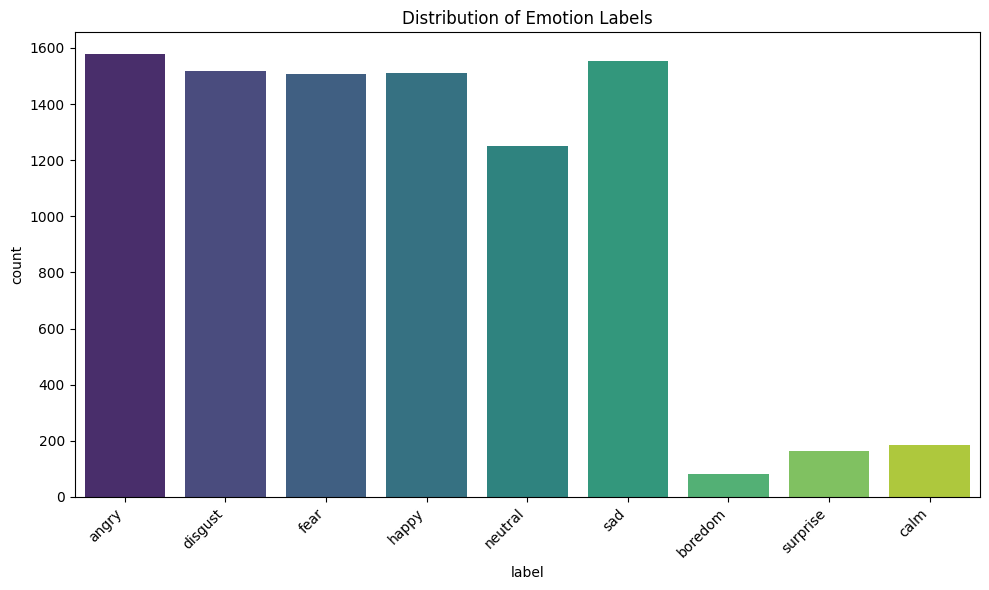

In [ ]:
if segmented_df.empty:
  print("The DataFrame is empty. Cannot plot label distribution.")
else:
  plt.figure(figsize=(10,6))
  sns.countplot(data=segmented_df, x='label', palette='viridis')
  plt.title('Distribution of Emotion Labels')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

Dataset distribution plot

/tmp/ipython-input-3442701106.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=segmented_df, x='dataset', palette='viridis')


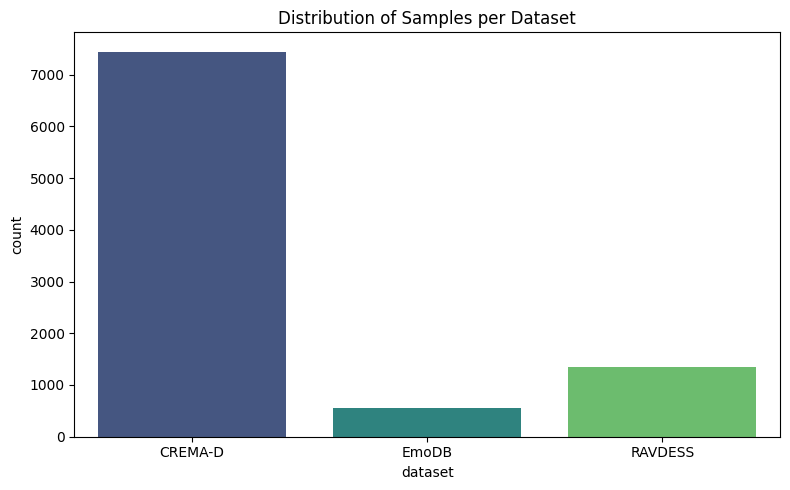

In [ ]:
if segmented_df.empty:
  print("The DataFrame is empty. Cannot plot dataset distribution.")
else:
  plt.figure(figsize=(8,5))
  sns.countplot(data=segmented_df, x='dataset', palette='viridis')
  plt.title('Distribution of Samples per Dataset')
  plt.xticks(rotation=0)
  plt.tight_layout()
  plt.show()

Gender distribution plot

/tmp/ipython-input-1670923577.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=segmented_df, x='gender', palette='viridis', order=segmented_df['gender'].value_counts().index)


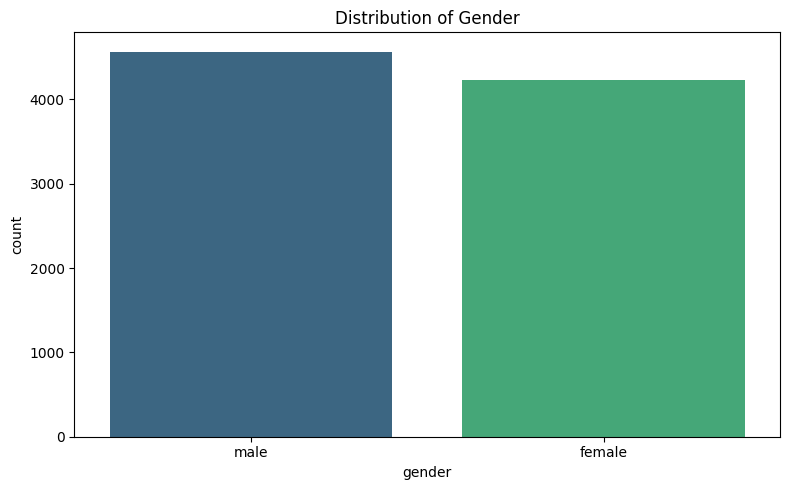

In [ ]:
if segmented_df.empty:
  print("The DataFrame is empty. Cannot plot gender distribution.")
else:
  plt.figure(figsize=(8,5))
  sns.countplot(data=segmented_df, x='gender', palette='viridis', order=segmented_df['gender'].value_counts().index)
  plt.title('Distribution of Gender')
  plt.xticks(rotation=0)
  plt.tight_layout()
  plt.show()

Split distribution plot

/tmp/ipython-input-3812949831.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=segmented_df, x='split', palette='viridis', order=['train','val','test'])


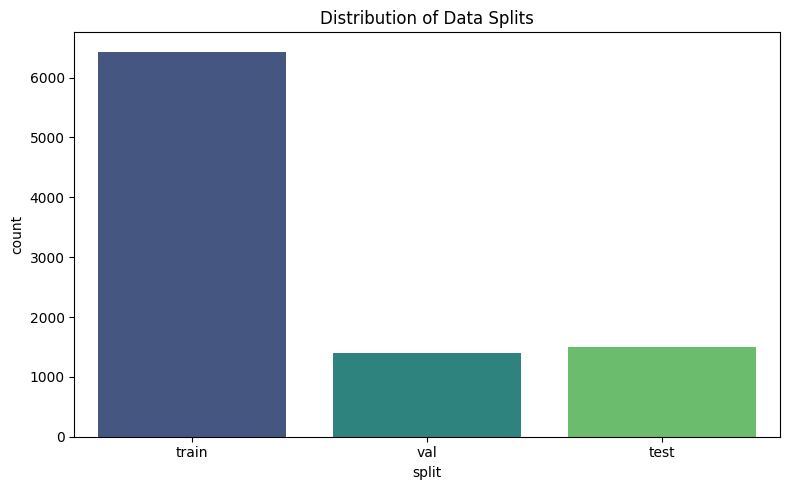

In [ ]:
if segmented_df.empty:
  print("The DataFrame is empty. Cannot plot split distribution.")
else:
  plt.figure(figsize=(8,5))
  sns.countplot(data=segmented_df, x='split', palette='viridis', order=['train','val','test'])
  plt.title('Distribution of Data Splits')
  plt.xticks(rotation=0)
  plt.tight_layout()
  plt.show()

Metadata distributions side-by-side

/tmp/ipython-input-2159987750.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=segmented_df, x='dataset', ax=axes[0], palette='viridis')
/tmp/ipython-input-2159987750.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=segmented_df, x='gender', ax=axes[1], palette='viridis')
/tmp/ipython-input-2159987750.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=segmented_df, x='accent', ax=axes[2], palette='viridis')


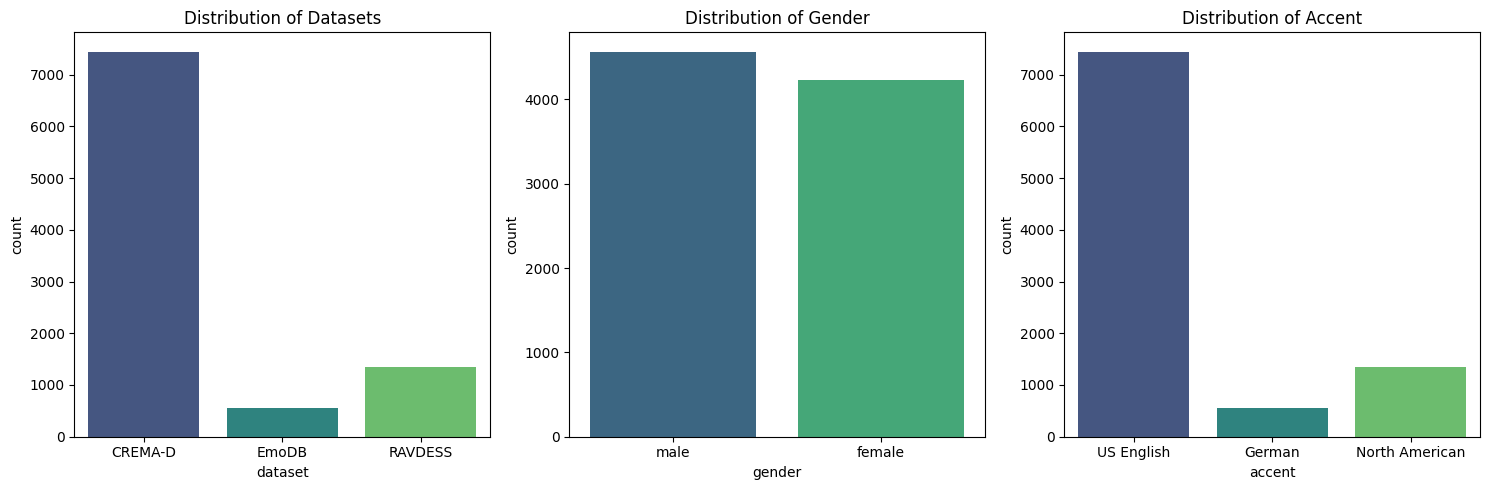

In [ ]:
if segmented_df.empty:
  print("The DataFrame is empty. Cannot plot metadata distributions.")
else:
  fig, axes = plt.subplots(1,3, figsize=(15,5))
  sns.countplot(data=segmented_df, x='dataset', ax=axes[0], palette='viridis')
  axes[0].set_title('Distribution of Datasets')
  sns.countplot(data=segmented_df, x='gender', ax=axes[1], palette='viridis')
  axes[1].set_title('Distribution of Gender')
  sns.countplot(data=segmented_df, x='accent', ax=axes[2], palette='viridis')
  axes[2].set_title('Distribution of Accent')
  plt.tight_layout()
  plt.show()

Relationships between metadata and labels

/tmp/ipython-input-1900986782.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=segmented_df, x='label', col='dataset', kind='count', palette='viridis', col_wrap=2, height=4, aspect=1.2)


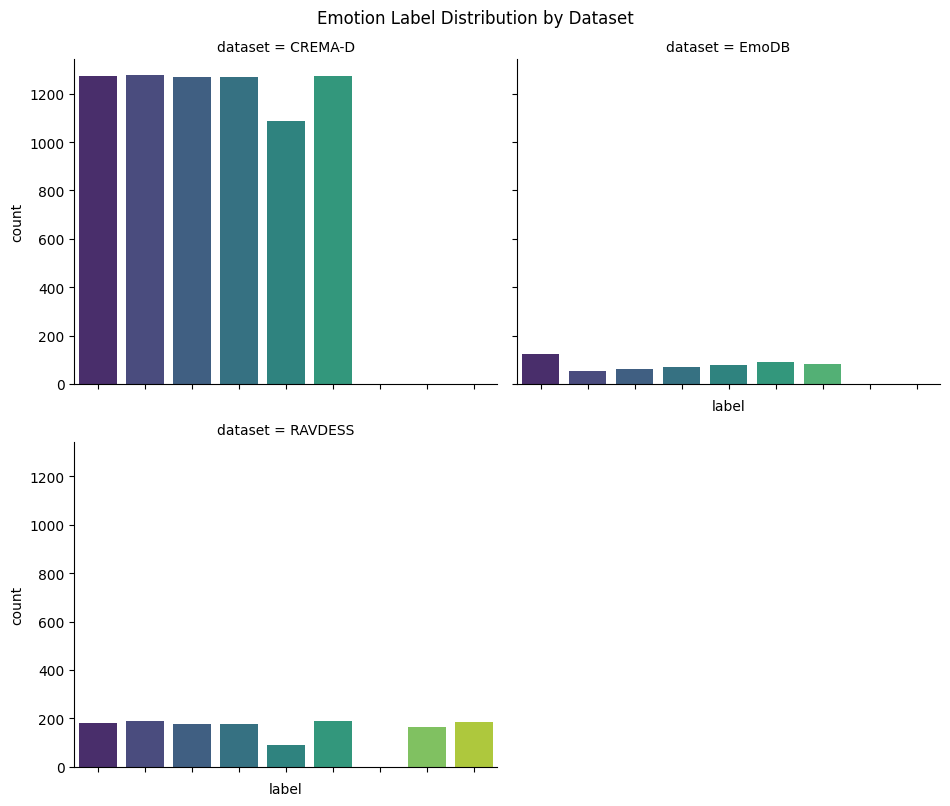

/tmp/ipython-input-1900986782.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=segmented_df, x='label', col='gender', kind='count', palette='viridis', col_wrap=2, height=4, aspect=1.2)


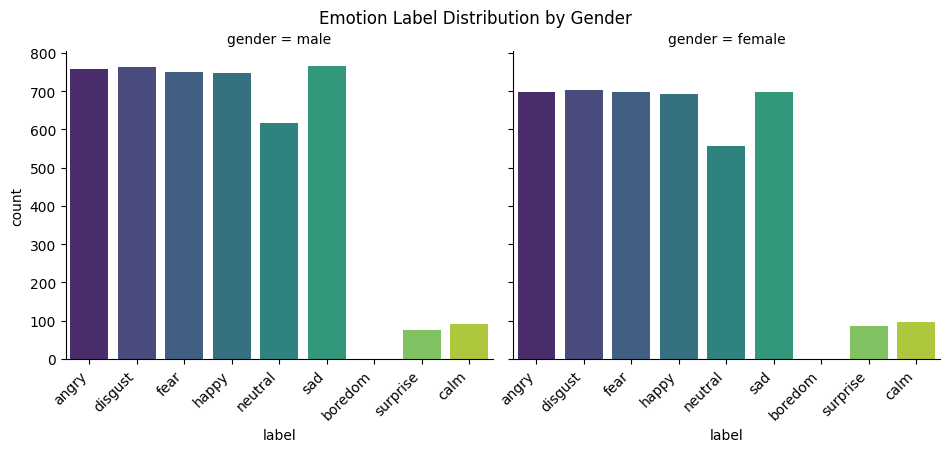

/tmp/ipython-input-1900986782.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=segmented_df, x='label', col='accent', kind='count', palette='viridis', col_wrap=2, height=4, aspect=1.2)


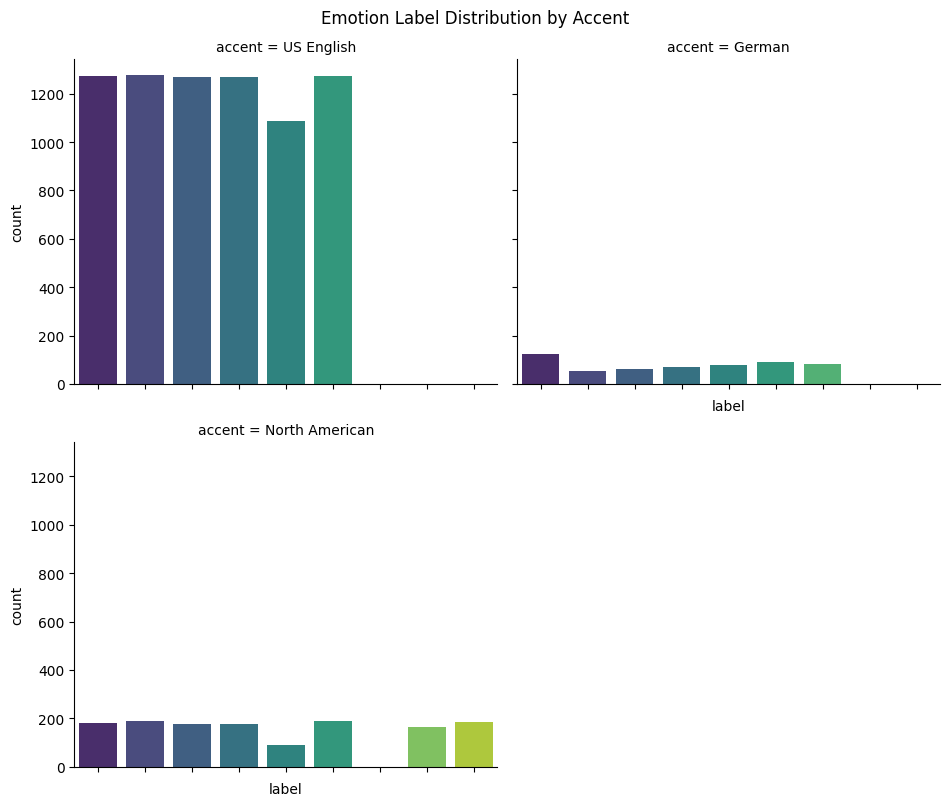

In [ ]:
if segmented_df.empty:
  print("The DataFrame is empty. Cannot analyze relationships.")
else:
  # By dataset
  g = sns.catplot(data=segmented_df, x='label', col='dataset', kind='count', palette='viridis', col_wrap=2, height=4, aspect=1.2)
  g.fig.suptitle('Emotion Label Distribution by Dataset', y=1.02)
  g.set_xticklabels(rotation=45, ha='right')
  plt.show()

  # By gender
  if 'gender' in segmented_df.columns and segmented_df['gender'].dropna().nunique() > 0:
      g = sns.catplot(data=segmented_df, x='label', col='gender', kind='count', palette='viridis', col_wrap=2, height=4, aspect=1.2)
      g.fig.suptitle('Emotion Label Distribution by Gender', y=1.02)
      g.set_xticklabels(rotation=45, ha='right')
      plt.show()
  else:
      print("\n'gender' column does not have enough unique non-null values for plotting.")


  # By accent
  if 'accent' in segmented_df.columns and segmented_df['accent'].dropna().nunique() > 0:
      g = sns.catplot(data=segmented_df, x='label', col='accent', kind='count', palette='viridis', col_wrap=2, height=4, aspect=1.2)
      g.fig.suptitle('Emotion Label Distribution by Accent', y=1.02)
      g.set_xticklabels(rotation=45, ha='right')
      plt.show()
  else:
      print("\n'accent' column does not have enough unique non-null values for plotting.")

Label & split distribution (tables)

In [ ]:
# Per-split label balance after segmentation
lbl_tbl = segmented_df.groupby(['split','label']).size().unstack(fill_value=0)
display(lbl_tbl)

# Per-dataset contribution by split
ds_tbl = segmented_df.groupby(['split','dataset']).size().unstack(fill_value=0)
display(ds_tbl)

# Duration sanity
print(segmented_df['duration'].describe())
print(segmented_df['duration'].value_counts().head())

label,angry,boredom,calm,disgust,fear,happy,neutral,sad,surprise
split,,,,,,,,,
test,251,19,32,233,241,241,205,252,31
train,1091,57,122,1056,1036,1040,861,1067,105
val,235,5,32,230,230,229,184,233,27


dataset,CREMA-D,EmoDB,RAVDESS
split,,,
test,1145,123,237
train,5160,394,881
val,1139,34,232


count    9345.0
mean        3.0
std         0.0
min         3.0
25%         3.0
50%         3.0
75%         3.0
max         3.0
Name: duration, dtype: float64
duration
3.0    9345
Name: count, dtype: int64


Label & metadata distribution

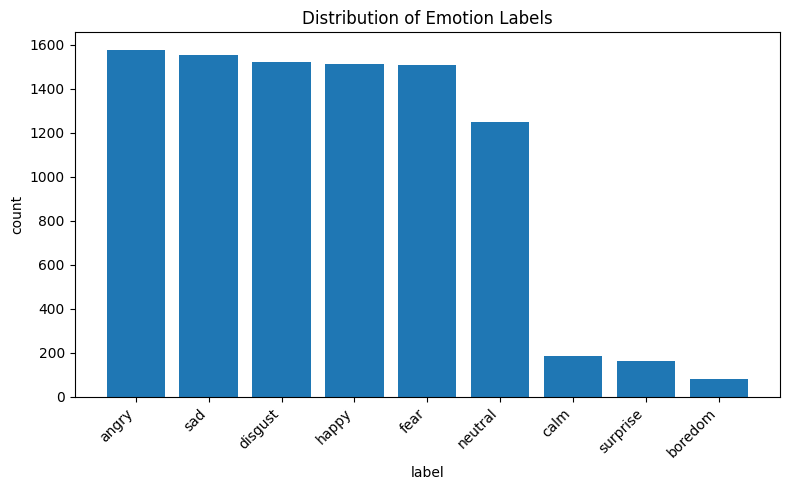

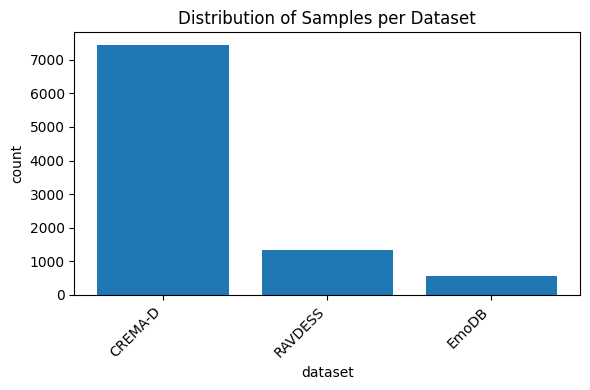

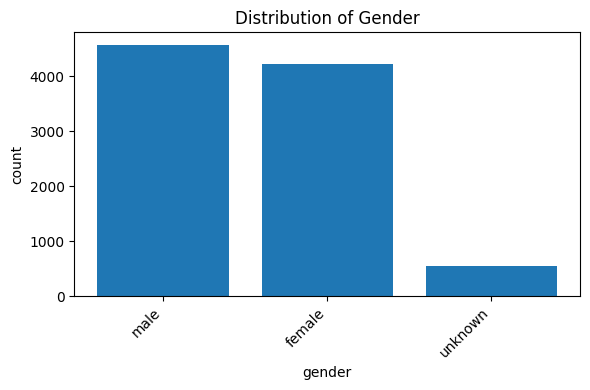

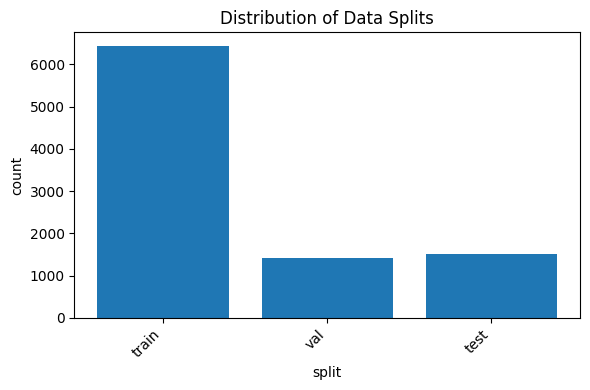

In [ ]:
import matplotlib.pyplot as plt

# We'll plot from segmented_df (post-segmentation is what matters for training)
_df = segmented_df.copy()

if _df.empty:
  print("segmented_df is empty; skipping plots.")
else:
  def bar_from_counts(ax, counts, title, xlabel):
    names = list(counts.index.astype(str))
    values = list(counts.values)
    ax.bar(range(len(values)), values)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('count')

  # 1) Emotion label distribution
  fig, ax = plt.subplots(figsize=(8,5))
  bar_from_counts(ax, _df['label'].value_counts(), 'Distribution of Emotion Labels', 'label')
  plt.tight_layout(); plt.show()

  # 2) Dataset distribution
  fig, ax = plt.subplots(figsize=(6,4))
  bar_from_counts(ax, _df['dataset'].value_counts(), 'Distribution of Samples per Dataset', 'dataset')
  plt.tight_layout(); plt.show()

  # 3) Gender distribution (include NaN as 'unknown')
  fig, ax = plt.subplots(figsize=(6,4))
  gvc = _df['gender'].fillna('unknown').value_counts()
  bar_from_counts(ax, gvc, 'Distribution of Gender', 'gender')
  plt.tight_layout(); plt.show()

  # 4) Split distribution (ordered)
  fig, ax = plt.subplots(figsize=(6,4))
  order = ['train','val','test']
  svc = _df['split'].value_counts()
  svc = svc.reindex([x for x in order if x in svc.index])
  bar_from_counts(ax, svc, 'Distribution of Data Splits', 'split')
  plt.tight_layout(); plt.show()

Relationships: labels and metadata

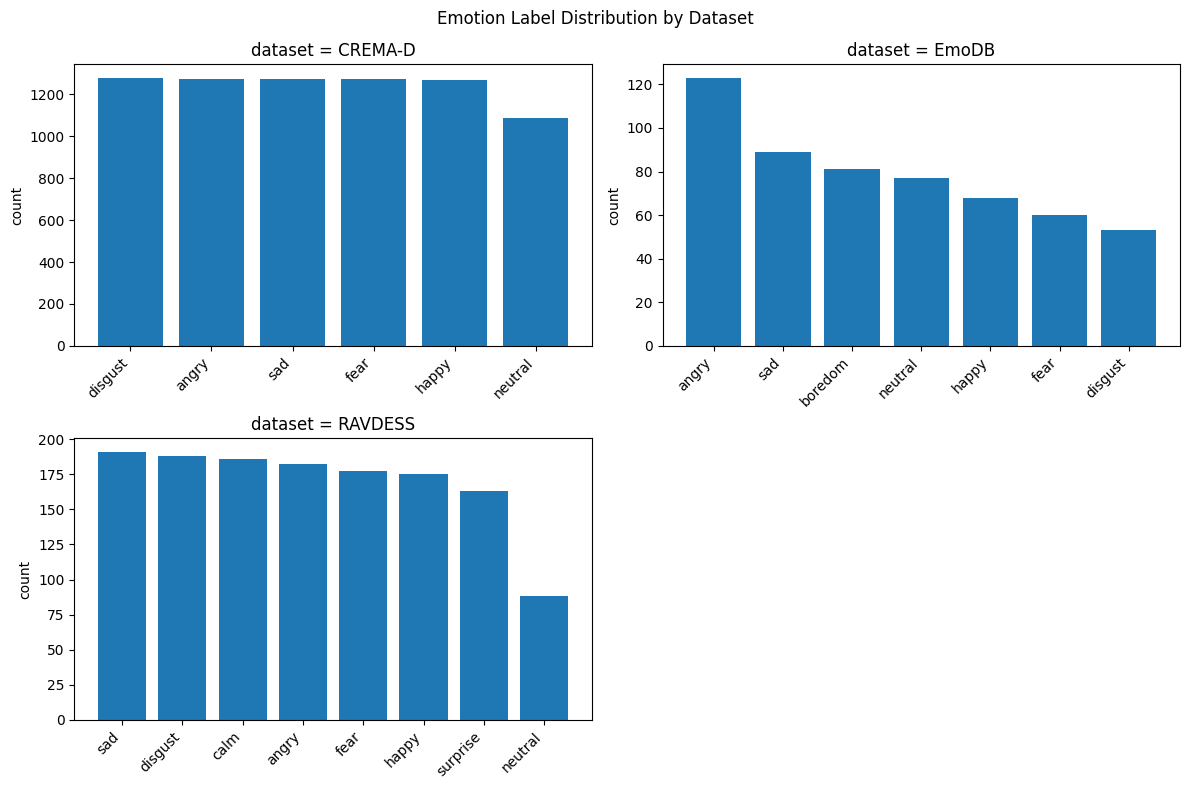

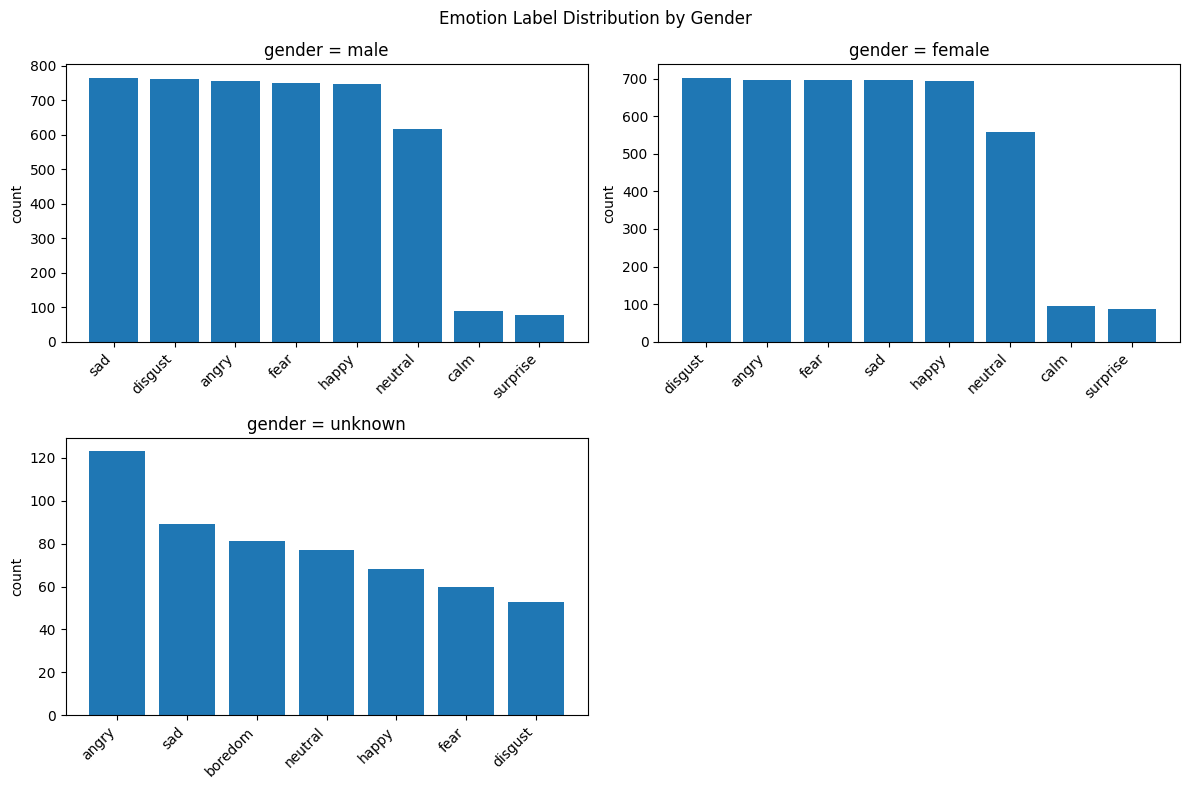

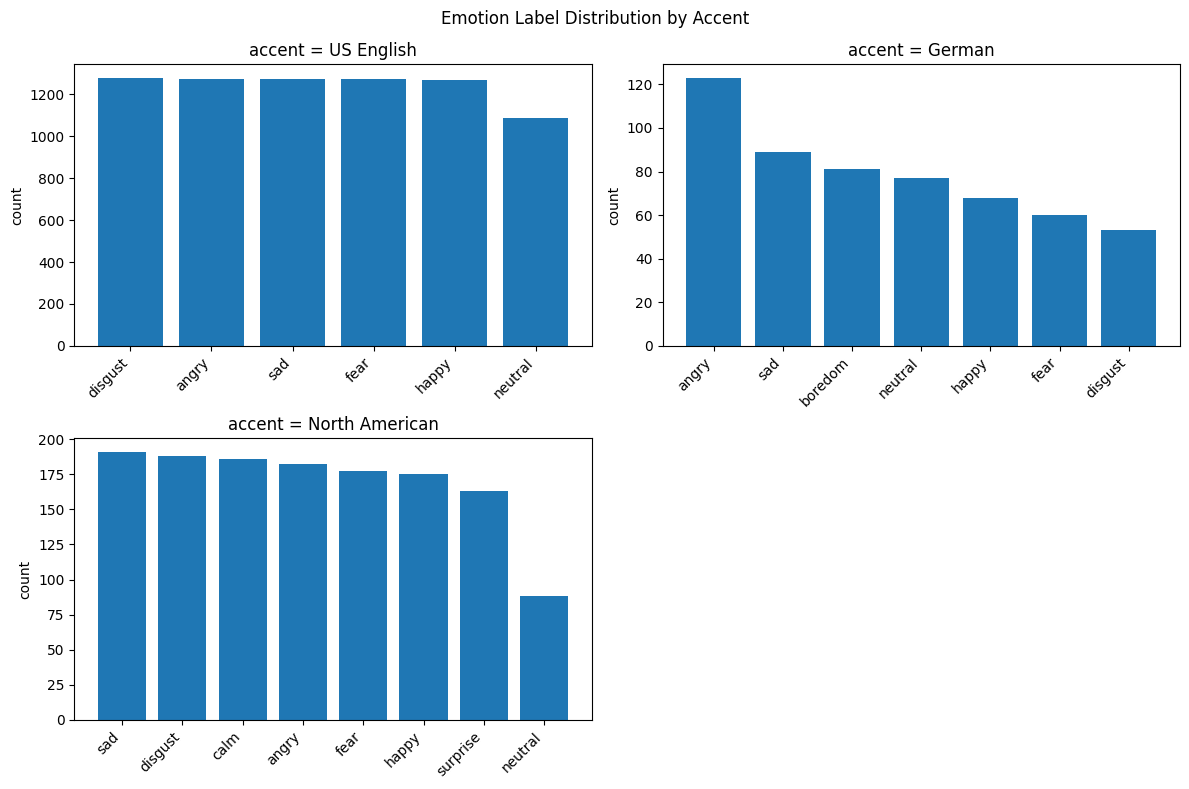

In [ ]:
import matplotlib.pyplot as plt

_df = segmented_df
if _df.empty:
  print("segmented_df is empty; skipping relationship plots.")
else:
  def facet_bar(df, facet_col, title):
    levels = [str(x) for x in df[facet_col].fillna('unknown').unique()]
    if not levels: # Add this check: if no levels, nothing to plot
        print(f"No data to plot for facet column: {facet_col}")
        return
    n = len(levels)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
    # Ensure axes is an iterable of axes objects
    axes = axes.flatten() if n > 1 else [axes]
    for i, lvl in enumerate(levels):
      sub = df[df[facet_col].fillna('unknown') == lvl]
      counts = sub['label'].value_counts()
      ax = axes[i]
      ax.bar(range(len(counts)), list(counts.values))
      ax.set_xticks(range(len(counts)))
      ax.set_xticklabels(list(counts.index.astype(str)), rotation=45, ha='right')
      ax.set_title(f"{facet_col} = {lvl}")
      ax.set_ylabel('count')
    # hide any unused axes
    for j in range(i+1, len(axes)):
      axes[j].axis('off')
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

  facet_bar(_df, 'dataset', 'Emotion Label Distribution by Dataset')

  # By gender
  if 'gender' in _df.columns and _df['gender'].dropna().nunique() > 0:
      facet_bar(_df, 'gender', 'Emotion Label Distribution by Gender')
  else:
      print("\n'gender' column does not have enough unique non-null values for plotting.")

  # By accent
  if 'accent' in _df.columns and _df['accent'].dropna().nunique() > 0:
      facet_bar(_df, 'accent', 'Emotion Label Distribution by Accent')
  else:
      print("\n'accent' column does not have enough unique non-null values for plotting.")

# Audio Features Analysis

In [ ]:
# Step 2: Split Data into Training, Validation, and Test Sets
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# --- Prepare Data (added to fix NameError) ---
# This code is copied from cell a5cb44e3 to define X_df and y
# WARNING: This will create a new, RANDOM split and overwrite your speaker-independent split.
# If you want to keep your speaker-independent split, do not run this cell and use
# the train_df, val_df, and test_df from earlier steps instead.
if 'segmented_df' not in globals():
    # Attempt to load segmented_df if not in memory (adjust path if needed)
    OUT_DIR  = "/content/drive/MyDrive/datasets/CSVs"
    segmented_manifest_path = f"{OUT_DIR}/manifest_all_segmented.csv"
    try:
        segmented_df = pd.read_csv(segmented_manifest_path)
        print(f"Loaded segmented data from: {segmented_manifest_path}")
    except FileNotFoundError:
        print(f"Error: segmented_df not found in memory or at {segmented_manifest_path}")
        # If segmented_df is not available, we cannot proceed with splitting.
        # You might need to re-run previous data preparation cells.
        raise NameError("'segmented_df' is not defined and could not be loaded.")


# Filter out rows where mfcc_mean is None
# Need to ensure 'mfcc_mean' was calculated and added to segmented_df in previous steps
if 'mfcc_mean' not in segmented_df.columns or segmented_df['mfcc_mean'].isnull().all():
     print("Error: 'mfcc_mean' column not found or is empty in segmented_df.")
     print("Please run feature extraction steps (e.g., cell VQ6SU9DbYoy4) to calculate MFCCs.")
     raise ValueError("'mfcc_mean' column missing or empty.")

# Ensure mfcc_mean is in a format that can be converted to a numpy array
# Assuming mfcc_mean is stored as strings representing lists/arrays; convert them
if isinstance(segmented_df['mfcc_mean'].iloc[0], str):
    print("Converting 'mfcc_mean' strings to numpy arrays...")
    try:
        # Attempt to parse the string representation of arrays
        segmented_df['mfcc_mean'] = segmented_df['mfcc_mean'].apply(lambda x: np.array(eval(x)) if pd.notna(x) else None)
        segmented_df = segmented_df.dropna(subset=['mfcc_mean']).copy() # Drop any rows that failed conversion
    except Exception as e:
        print(f"Error converting 'mfcc_mean' strings to arrays: {e}")
        print("Please check the format of the 'mfcc_mean' column.")
        raise


prepared_df = segmented_df.dropna(subset=['mfcc_mean']).copy()

# Separate MFCC features into individual columns
# This step might not be necessary for all models (like CNNs expecting [samples, features, 1])
# but is included here to match the structure that caused the original error
# For SVM or other flat feature models, this is needed.
mfcc_list = prepared_df['mfcc_mean'].tolist()
if not mfcc_list:
     raise ValueError("No valid MFCC data found after dropping NaNs.")

# Determine the number of MFCC features from the first valid entry
n_mfcc_features = len(mfcc_list[0]) if mfcc_list else 0
if n_mfcc_features == 0:
     raise ValueError("Could not determine the number of MFCC features.")

mfcc_df = pd.DataFrame(mfcc_list)
mfcc_df.columns = [f'mfcc_{i}' for i in range(n_mfcc_features)]

# Combine MFCCs with other features (pitch and energy) if available and needed
features_to_combine = [mfcc_df]
if 'pitch_hz' in prepared_df.columns:
    features_to_combine.append(prepared_df[['pitch_hz']].reset_index(drop=True)) # Reset index to align
if 'energy_rms' in prepared_df.columns:
     features_to_combine.append(prepared_df[['energy_rms']].reset_index(drop=True)) # Reset index to align

# Ensure indices align after dropna and before concat
prepared_df = prepared_df.reset_index(drop=True)
X_df = pd.concat(features_to_combine, axis=1)

# Prepare labels
y = prepared_df['label']

print("Shape of feature matrix X_df (for random split):", X_df.shape)
print("Shape of labels y (for random split):", y.shape)
# --- End Prepare Data ---


# Split data into training and temporary sets (validation + test) using random split
X_train, X_temp, y_train, y_temp = train_test_split(X_df, y, test_size=0.3, random_state=42, stratify=y)

# Split temporary set into validation and test sets using random split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("\nPerformed a NEW random train/val/test split.")
print("Shape of X_train (random split):", X_train.shape)
print("Shape of y_train (random split):", y_train.shape)
print("Shape of X_val (random split):", X_val.shape)
print("Shape of y_val (random split):", y_val.shape)
print("Shape of X_test (random split):", X_test.shape)
print("Shape of y_test (random split):", y_test.shape)

# Note: For subsequent steps (scaling, model training), you might need to reshape
# X_train, X_val, X_test back to the [samples, features, 1] shape if using CNNs,
# or keep them flat [samples, features] if using models like SVM that expect 2D input.
# The scaling and model building cells should handle this reshaping.

Shape of feature matrix X_df (for random split): (9345, 15)
Shape of labels y (for random split): (9345,)

Performed a NEW random train/val/test split.
Shape of X_train (random split): (6541, 15)
Shape of y_train (random split): (6541,)
Shape of X_val (random split): (1402, 15)
Shape of y_val (random split): (1402,)
Shape of X_test (random split): (1402, 15)
Shape of y_test (random split): (1402,)


## Duration via soundfile

In [ ]:
import soundfile as sf

def get_audio_duration(file_path):
  try:
    info = sf.info(file_path)
    return info.frames / float(info.samplerate)
  except Exception as e:
    print(f"Duration fail {file_path}: {e}")
    return None

segmented_df = ensure_duration(segmented_df) # adds 'duration' if missing
print("Sample durations:")
display(segmented_df[['path','duration']].head())

Sample durations:


,path,duration
0,/content/drive/MyDrive/datasets/Segmented_Audi...,3.0
1,/content/drive/MyDrive/datasets/Segmented_Audi...,3.0
2,/content/drive/MyDrive/datasets/Segmented_Audi...,3.0
3,/content/drive/MyDrive/datasets/Segmented_Audi...,3.0
4,/content/drive/MyDrive/datasets/Segmented_Audi...,3.0


## MFCC summary vectors (mean over time)

In [ ]:
import numpy as np, librosa
from tqdm.auto import tqdm

tqdm.pandas()

N_MFCC = 13

def mfcc_mean(file_path, n_mfcc=N_MFCC):
  try:
    y, sr = librosa.load(file_path, sr=TARGET_SAMPLE_RATE)
    m = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(m, axis=1) # shape (n_mfcc,)
  except Exception as e:
    print(f"MFCC fail {file_path}: {e}")
    return None

# For EDA: store means as a list in-memory (avoid writing arrays to CSV)
segmented_df = segmented_df.copy()
segmented_df['mfcc_mean'] = segmented_df['path'].progress_apply(mfcc_mean)
print("MFCC examples:")
display(segmented_df[['label','mfcc_mean']].head())

  0%|          | 0/9345 [00:00<?, ?it/s]

MFCC fail /content/drive/MyDrive/datasets/Segmented_Audio/CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_1001_DFA_ANG_XX_rs16k_trim_clean_seg_000.wav: name 'TARGET_SAMPLE_RATE' is not defined
MFCC fail /content/drive/MyDrive/datasets/Segmented_Audio/CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_1001_DFA_DIS_XX_rs16k_trim_clean_seg_000.wav: name 'TARGET_SAMPLE_RATE' is not defined
MFCC fail /content/drive/MyDrive/datasets/Segmented_Audio/CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_1001_DFA_FEA_XX_rs16k_trim_clean_seg_000.wav: name 'TARGET_SAMPLE_RATE' is not defined
MFCC fail /content/drive/MyDrive/datasets/Segmented_Audio/CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_1001_DFA_HAP_XX_rs16k_trim_clean_seg_000.wav: name 'TARGET_SAMPLE_RATE' is not defined
MFCC fail /content/drive/MyDrive/datasets/Segmented_Audio/CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_CREMA-D_CREMA_1001_C

,label,mfcc_mean
0,angry,None
1,disgust,None
2,fear,None
3,happy,None
4,neutral,None


In [ ]:
# Save the segmented_df with MFCCs to a new CSV
segmented_manifest_with_features = f"{OUT_DIR}/manifest_all_segmented_with_mfccs.csv"
segmented_df.to_csv(segmented_manifest_with_features, index=False)
print(f"Saved segmented manifest with MFCCs to: {segmented_manifest_with_features}")

Saved segmented manifest with MFCCs to: /content/drive/MyDrive/datasets/CSVs/manifest_all_segmented_with_mfccs.csv


## Pitch & energy

In [ ]:
import numpy as np, librosa

FMIN = librosa.note_to_hz('C2')
FMAX = librosa.note_to_hz('C6') # narrower than C7 for speed/stability

def pitch_energy(file_path):
  try:
    y, sr = librosa.load(file_path, sr=TARGET_SAMPLE_RATE)
    # Pitch: yin is faster/more stable; use voiced frames only
    f0 = librosa.yin(y, fmin=FMIN, fmax=FMAX, sr=sr)
    f0 = f0[np.isfinite(f0)]
    pitch_mean = float(np.nanmean(f0)) if f0.size else np.nan
    # Energy: RMS
    rms = librosa.feature.rms(y=y)
    energy_mean = float(np.mean(rms)) if rms.size else np.nan
    return pitch_mean, energy_mean
  except Exception as e:
    print(f"Pitch/Energy fail {file_path}: {e}")
    return np.nan, np.nan

pe = segmented_df['path'].progress_apply(pitch_energy)
segmented_df['pitch_hz'] = [p for p, e in pe]
segmented_df['energy_rms'] = [e for p, e in pe]

  0%|          | 0/9345 [00:00<?, ?it/s]

## Feature distributions

/tmp/ipython-input-2208372644.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


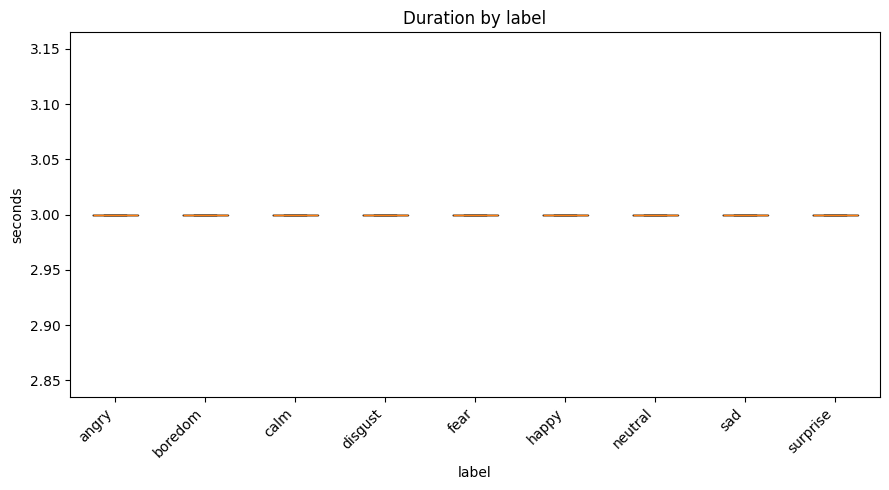

/tmp/ipython-input-2208372644.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


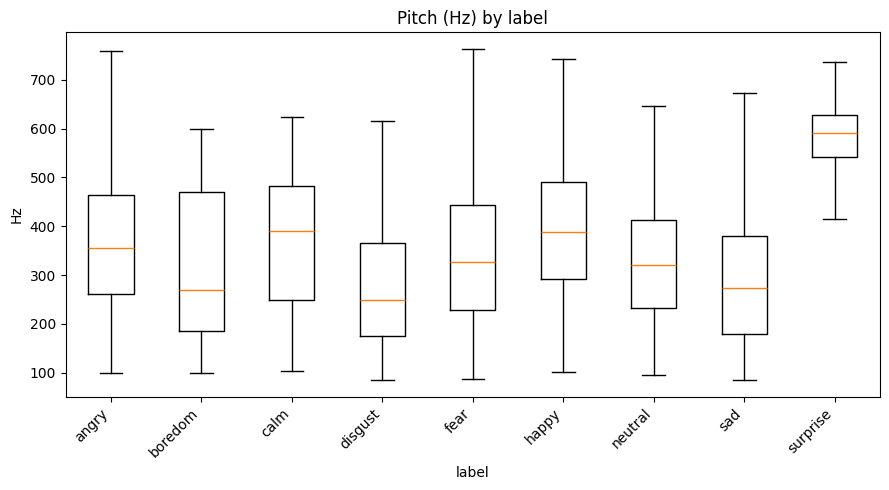

/tmp/ipython-input-2208372644.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


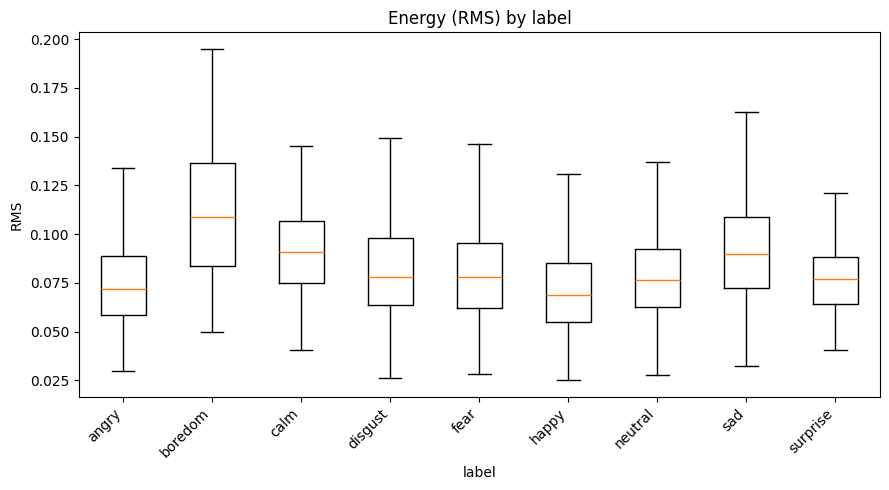

In [ ]:
import matplotlib.pyplot as plt

_df = segmented_df

# Duration by label
if not _df.empty:
  fig, ax = plt.subplots(figsize=(9,5))
  labels = sorted(_df['label'].dropna().unique())
  data = [ _df.loc[_df['label']==lb, 'duration'].dropna().values for lb in labels ]
  ax.boxplot(data, labels=labels, showfliers=False)
  ax.set_title('Duration by label'); ax.set_ylabel('seconds'); ax.set_xlabel('label')
  plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

# Pitch by label
if not _df.empty:
  fig, ax = plt.subplots(figsize=(9,5))
  data = [ _df.loc[_df['label']==lb, 'pitch_hz'].dropna().values for lb in labels ]
  ax.boxplot(data, labels=labels, showfliers=False)
  ax.set_title('Pitch (Hz) by label'); ax.set_ylabel('Hz'); ax.set_xlabel('label')
  plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

# Energy by label
if not _df.empty:
  fig, ax = plt.subplots(figsize=(9,5))
  data = [ _df.loc[_df['label']==lb, 'energy_rms'].dropna().values for lb in labels ]
  ax.boxplot(data, labels=labels, showfliers=False)
  ax.set_title('Energy (RMS) by label'); ax.set_ylabel('RMS'); ax.set_xlabel('label')
  plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

In [ ]:
print("Summary Statistics (duration, pitch, energy):")
display(_df[['duration','pitch_hz','energy_rms']].describe())

print("\nLabel distribution (overall):")
display(_df['label'].value_counts().to_frame('count'))

print("\nLabel distribution by split:")
display(_df.groupby('split')['label'].value_counts().unstack(fill_value=0))

print("\nLabel distribution by dataset:")
display(_df.groupby('dataset')['label'].value_counts().unstack(fill_value=0))

if {'gender','dataset','split'}.issubset(_df.columns):
  print("\nGender by dataset × split:")
  display(_df.groupby(['dataset','split'])['gender'].value_counts().unstack(fill_value=0))

if {'ethnicity','dataset','split'}.issubset(_df.columns):
  print("\nEthnicity by dataset × split:")
  display(_df.groupby(['dataset','split'])['ethnicity'].value_counts().unstack(fill_value=0))

Summary Statistics (duration, pitch, energy):


,duration,pitch_hz,energy_rms
count,9345.0,9345.000000,9345.000000
mean,3.0,337.238515,0.080727
std,0.0,138.002709,0.025734
min,3.0,84.323391,0.000000
25%,3.0,223.492645,0.062086
50%,3.0,325.835912,0.077194
75%,3.0,437.038582,0.095580
max,3.0,1066.666667,0.241987



Label distribution (overall):


,count
label,
angry,1577
sad,1552
disgust,1519
happy,1510
fear,1507
neutral,1250
calm,186
surprise,163
boredom,81



Label distribution by split:


...

label,angry,boredom,calm,disgust,fear,happy,neutral,sad,surprise
dataset,,,,,,,,,
CREMA-D,1272,0,0,1278,1270,1267,1085,1272,0
EmoDB,123,81,0,53,60,68,77,89,0
RAVDESS,182,0,186,188,177,175,88,191,163



Gender by dataset × split:


gender         female  male
dataset split              
CREMA-D test      326   819
        train    2949  2211
        val       246   893
RAVDESS test      120   117
        train     470   411
        val       117   115


Ethnicity by dataset × split:


ethnicity      Asian  Black/African American  Unknown  White
dataset split                                               
CREMA-D test      82                     327        0    736
        train    409                    1314       82   3355
        val       75                     163        0    901

## Summary Visualization of Final Dataset State

This section provides visualizations to summarize the key characteristics of the cleaned and prepared dataset, including the distribution of emotional labels, data splits, and extracted numerical features.

--- Summary Visualizations ---


/tmp/ipython-input-632175533.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_split, x='label', palette='viridis', order=merged_split['label'].value_counts().index)


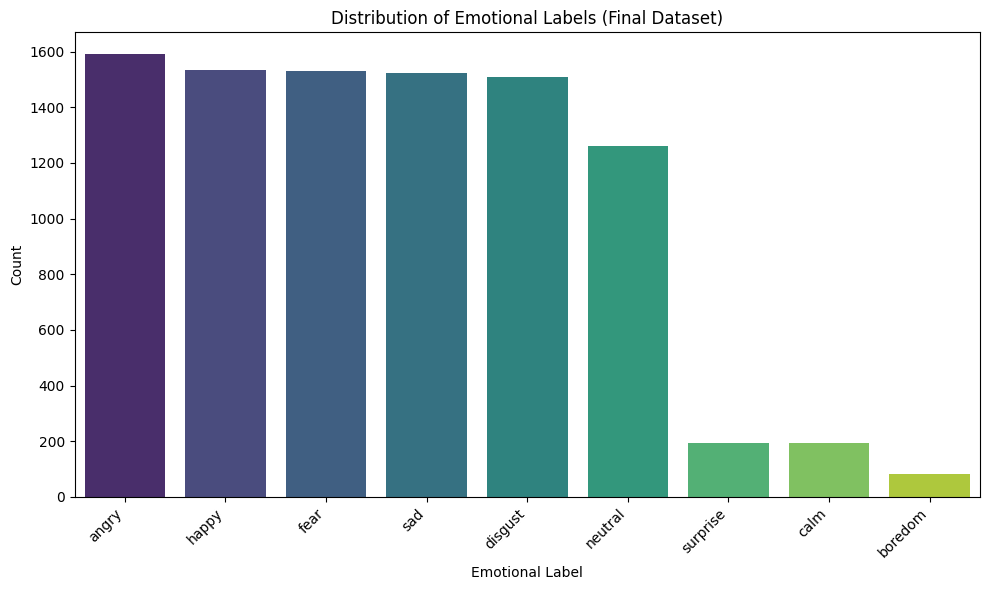

/tmp/ipython-input-632175533.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_split, x='split', palette='viridis', order=['train', 'val', 'test'])


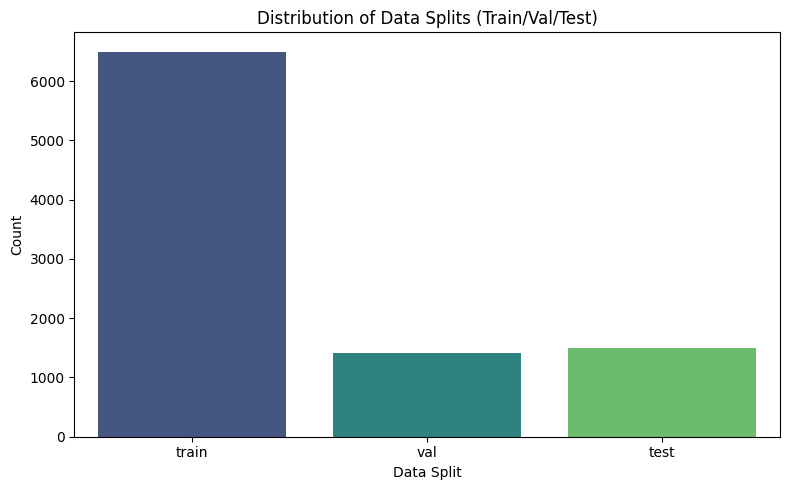

/tmp/ipython-input-632175533.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_split, x='gender', palette='viridis', order=merged_split['gender'].value_counts().index)


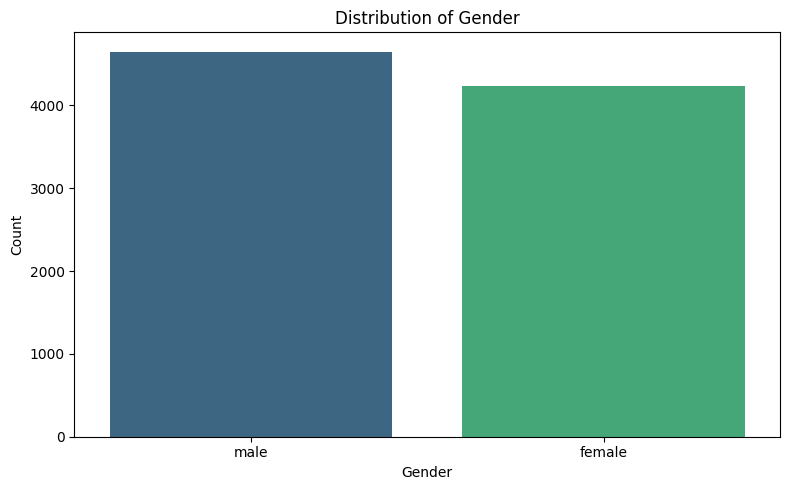

/tmp/ipython-input-632175533.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_split, x='accent', palette='viridis', order=merged_split['accent'].value_counts().index)


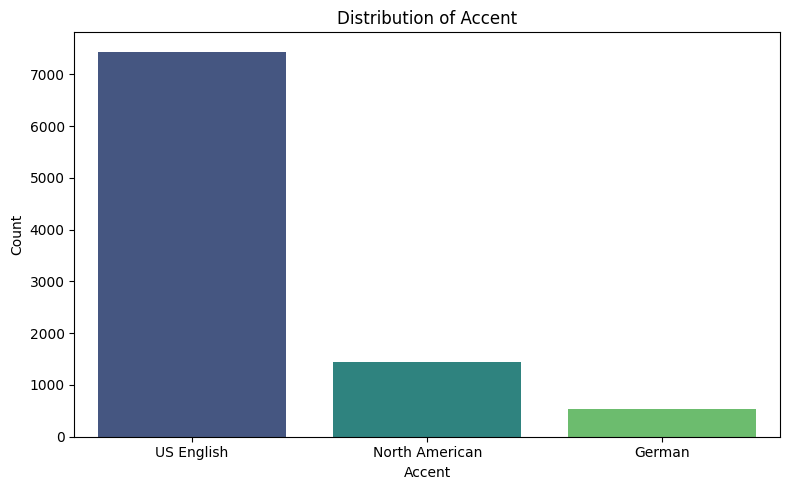


'duration' column not available for visualization.

'pitch' column not available or is not numeric for visualization.

'energy' column not available or is not numeric for visualization.

MFCC features are available but not easily visualized in a summary plot.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Assume merged_split is the final DataFrame after cleaning and feature extraction
# If you saved the final cleaned and prepared data to a new CSV, load it here instead:
# merged_split = pd.read_csv(f"{OUT_DIR}/manifest_all_cleaned_prepared.csv") # Example

if 'merged_split' not in globals():
    print("The 'merged_split' DataFrame is not available. Please ensure the data loading, cleaning, and feature extraction steps have been executed.")
else:
    print("--- Summary Visualizations ---")

    # 1. Distribution of Emotional Labels
    plt.figure(figsize=(10, 6))
    sns.countplot(data=merged_split, x='label', palette='viridis', order=merged_split['label'].value_counts().index)
    plt.title('Distribution of Emotional Labels (Final Dataset)')
    plt.xlabel('Emotional Label')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 2. Distribution of Data Splits
    plt.figure(figsize=(8, 5))
    sns.countplot(data=merged_split, x='split', palette='viridis', order=['train', 'val', 'test'])
    plt.title('Distribution of Data Splits (Train/Val/Test)')
    plt.xlabel('Data Split')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # 3. Distribution of Gender
    if 'gender' in merged_split.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=merged_split, x='gender', palette='viridis', order=merged_split['gender'].value_counts().index)
        plt.title('Distribution of Gender')
        plt.xlabel('Gender')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
    else:
        print("\n'gender' column not available for visualization.")


    # 4. Distribution of Accent
    if 'accent' in merged_split.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=merged_split, x='accent', palette='viridis', order=merged_split['accent'].value_counts().index)
        plt.title('Distribution of Accent')
        plt.xlabel('Accent')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
    else:
         print("\n'accent' column not available for visualization.")


    # 5. Distribution of Duration by Label
    if 'duration' in merged_split.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='label', y='duration', data=merged_split, palette='viridis')
        plt.title('Distribution of Audio Duration by Emotional Label')
        plt.xlabel('Emotional Label')
        plt.ylabel('Duration (seconds)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("\n'duration' column not available for visualization.")

    # 6. Distribution of Pitch by Label (if numeric)
    if 'pitch' in merged_split.columns and pd.api.types.is_numeric_dtype(merged_split['pitch']):
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='label', y='pitch', data=merged_split, palette='viridis')
        plt.title('Distribution of Pitch by Emotional Label')
        plt.xlabel('Emotional Label')
        plt.ylabel('Pitch (Hz)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("\n'pitch' column not available or is not numeric for visualization.")


    # 7. Distribution of Energy by Label (if numeric)
    if 'energy' in merged_split.columns and pd.api.types.is_numeric_dtype(merged_split['energy']):
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='label', y='energy', data=merged_split, palette='viridis')
        plt.title('Distribution of Energy by Emotional Label')
        plt.xlabel('Emotional Label')
        plt.ylabel('Energy (RMS)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("\n'energy' column not available or is not numeric for visualization.")

    # Note: Visualizing MFCCs directly is complex. You might summarize them or focus on other features.
    print("\nMFCC features are available but not easily visualized in a summary plot.")

# Random Forest Classifier Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_train_scaled, X_test_scaled, y_train, y_test are available from previous steps
if 'X_train_scaled' in globals() and 'X_test_scaled' in globals() and 'y_train' in globals() and 'y_test' in globals():
    print("Building and training the Random Forest model...")

    # Reshape y_train and y_test to be 1D arrays if they are one-hot encoded
    # Assuming y_train and y_test are one-hot encoded from the previous step
    if y_train.ndim > 1 and y_train.shape[1] > 1:
        y_train_flat = np.argmax(y_train, axis=1)
        y_test_flat = np.argmax(y_test, axis=1)
    else:
        # If y is already 1D (e.g., from LabelEncoder directly)
        y_train_flat = y_train
        y_test_flat = y_test

    # Initialize the Random Forest Classifier
    # You can adjust parameters like n_estimators, max_depth, etc.
    # n_estimators: The number of trees in the forest. Higher numbers generally improve performance but increase computation.
    # random_state: Ensures reproducibility of the results.
    # n_jobs: Number of cores to use for training (-1 means use all available cores).
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    # Train the model
    rf_model.fit(X_train_scaled, y_train_flat)
    print("Model training complete.")

    # --- Evaluation ---
    print("\nEvaluating the model on the test set...")
    y_pred = rf_model.predict(X_test_scaled)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_flat, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")

    # Classification report
    # We need the actual class names from the label_encoder
    if 'label_encoder' in globals():
        target_names = label_encoder.classes_
        print("\nClassification Report:")
        print(classification_report(y_test_flat, y_pred, target_names=target_names))

        # Confusion matrix
        cm = confusion_matrix(y_test_flat, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

    else:
        print("\nClassification Report (using encoded labels):")
        print(classification_report(y_test_flat, y_pred))

        cm = confusion_matrix(y_test_flat, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()


else:
    print("Required data (X_train_scaled, X_test_scaled, y_train, y_test) not found. Please run the previous data preparation and feature extraction cells.")


# **Support Vector Machine**
**What is a Support Vector Machine (SVM)?**
A Support Vector Machine (SVM) is a powerful supervised machine learning algorithm, primarily used for classification tasks (also regression). SVM works by finding the optimal boundary (hyperplane) that best separates different classes in the feature space. The data points closest to the boundary are called "support vectors," and they are crucial for defining the position and orientation of the hyperplane.

**Key Concepts:**

Hyperplane: The decision boundary that separates classes.

Support Vectors: Data points that are closest to the hyperplane and influence its position.

Margin: The distance between the hyperplane and the support vectors (SVM tries to maximize this).

Kernel Trick: Allows SVM to perform well even when the data is not linearly separable by mapping it into higher-dimensional space.

**Why Use SVM for Emotional Speech Recognition?**
Handles high-dimensional data well (audio features such as MFCCs, pitch, energy, etc.).
Effective in cases where the number of dimensions > number of samples.
Robust to overfitting, especially in high-dimensional spaces.


In [ ]:
import pandas as pd
import os

segmented_df = pd.read_csv(SEGMENTED_MANIFEST_PATH)
print(f"Loaded segmented data from: {SEGMENTED_MANIFEST_PATH}")
print(f"Number of rows: {len(segmented_df)}")
display(segmented_df.head())

Loaded segmented data from: /content/drive/MyDrive/datasets/CSVs/manifest_all_segmented.csv
Number of rows: 9345


,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split,original_path,segment_index,start_time_sec,end_time_sec,duration
0,/content/drive/MyDrive/datasets/Segmented_Audi...,CREMA-D,CREMA_1001,male,51.0,US English,White,angry,ANG,NaN,NaN,NaN,test,/content/drive/MyDrive/datasets/Cleaned_Audio/...,0,0.0,3.0,3.0
1,/content/drive/MyDrive/datasets/Segmented_Audi...,CREMA-D,CREMA_1001,male,51.0,US English,White,disgust,DIS,NaN,NaN,NaN,test,/content/drive/MyDrive/datasets/Cleaned_Audio/...,0,0.0,3.0,3.0
2,/content/drive/MyDrive/datasets/Segmented_Audi...,CREMA-D,CREMA_1001,male,51.0,US English,White,fear,FEA,NaN,NaN,NaN,test,/content/drive/MyDrive/datasets/Cleaned_Audio/...,0,0.0,3.0,3.0
3,/content/drive/MyDrive/datasets/Segmented_Audi...,CREMA-D,CREMA_1001,male,51.0,US English,White,happy,HAP,NaN,NaN,NaN,test,/content/drive/MyDrive/datasets/Cleaned_Audio/...,0,0.0,3.0,3.0
4,/content/drive/MyDrive/datasets/Segmented_Audi...,CREMA-D,CREMA_1001,male,51.0,US English,White,neutral,NEU,NaN,NaN,NaN,test,/content/drive/MyDrive/datasets/Cleaned_Audio/...,0,0.0,3.0,3.0


In [ ]:
import numpy as np
import pandas as pd
import librosa # Import librosa for MFCC calculation
from tqdm.auto import tqdm # Import tqdm for progress bar
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical # Import to_categorical

tqdm.pandas() # Enable pandas progress_apply

# Define TARGET_SAMPLE_RATE and N_MFCC if they are not already defined
# Ensure these match the values used in previous data processing steps
if 'TARGET_SAMPLE_RATE' not in globals():
    TARGET_SAMPLE_RATE = 16000
    print(f"Defined TARGET_SAMPLE_RATE: {TARGET_SAMPLE_RATE}")
if 'N_MFCC' not in globals():
    N_MFCC = 13
    print(f"Defined N_MFCC: {N_MFCC}")

# Define OUT_DIR if not already defined (needed to load segmented_df)
if 'OUT_DIR' not in globals():
    OUT_DIR  = "/content/drive/MyDrive/datasets/CSVs" # Adjust path if necessary
    print(f"Defined OUT_DIR: {OUT_DIR}")

# Load the segmented data manifest if not already in memory
if 'segmented_df' not in globals():
    segmented_manifest_path = f"{OUT_DIR}/manifest_all_segmented.csv"
    if os.path.exists(segmented_manifest_path):
        segmented_df = pd.read_csv(segmented_manifest_path)
        print(f"Loaded segmented data from: {segmented_manifest_path}")
    else:
        raise FileNotFoundError(f"Segmented manifest not found at {segmented_manifest_path}. Please run data preparation steps first.")


def mfcc_mean(file_path, n_mfcc=N_MFCC, sr=TARGET_SAMPLE_RATE):
  """Calculates the mean MFCC over time for an audio file."""
  try:
    y, sr_load = librosa.load(file_path, sr=sr)
    m = librosa.feature.mfcc(y=y, sr=sr_load, n_mfcc=n_mfcc)
    return np.mean(m, axis=1) # shape (n_mfcc,)
  except Exception as e:
    # print(f"MFCC calculation failed for {file_path}: {e}") # Optional: keep for debugging
    return None


# --- Feature Preparation ---
# Check if 'mfcc_mean' column exists and is not empty in segmented_df
if 'mfcc_mean' not in segmented_df.columns or segmented_df['mfcc_mean'].isnull().all():
    print("Warning: 'mfcc_mean' column not found or is empty. Calculating MFCCs from audio files.")
    # Add fallback: Calculate MFCCs if missing
    if 'path' not in segmented_df.columns:
        print("Error: 'path' column not found in segmented_df to calculate MFCCs.")
        X = None
        y_encoded = None
        y_categorical = None
        label_encoder = None
    else:
         # Calculate MFCCs from audio paths
        segmented_df['mfcc_mean'] = segmented_df['path'].progress_apply(mfcc_mean)
        # Drop rows where MFCC calculation failed
        prepared_df = segmented_df.dropna(subset=['mfcc_mean']).copy()
        print(f"Calculated MFCCs. Number of rows with valid MFCCs: {len(prepared_df)}")

else:
    # If mfcc_mean is already present, use it directly
    print("Using existing 'mfcc_mean' column.")
    prepared_df = segmented_df.dropna(subset=['mfcc_mean']).copy() # Ensure no NaNs in mfcc_mean

# Proceed only if prepared_df is not empty after handling NaNs
if prepared_df is not None and not prepared_df.empty:
    # Convert the string representation of mfcc_mean arrays to numpy arrays if necessary
    # Safely convert string representations of arrays, or use arrays directly if they are already numpy arrays
    try:
        # Check if the first non-null entry is already a numpy array
        first_mfcc = prepared_df['mfcc_mean'].dropna().iloc[0]
        if isinstance(first_mfcc, np.ndarray):
            X = np.array(prepared_df['mfcc_mean'].tolist())
        else:
            # Assume it's a string representation and try to evaluate
             X = np.array(prepared_df['mfcc_mean'].apply(lambda x: np.array(eval(x)) if pd.notna(x) else None).dropna().tolist())
        print(f"Shape of features (X) after converting/using arrays and dropping NaNs: {X.shape}")

        # --- Label Encoding ---
        # Get labels corresponding to the non-null features
        y_labels = prepared_df['label'].values # Use labels from prepared_df
        label_encoder = LabelEncoder()
        y_encoded = label_encoder.fit_transform(y_labels) # 1D encoded labels
        y_categorical = to_categorical(y_encoded) # One-hot encoded labels
        print(f"Shape of 1D encoded labels (y_encoded): {y_encoded.shape}")
        print(f"Shape of one-hot encoded labels (y_categorical): {y_categorical.shape}")
        print("Label classes:", label_encoder.classes_)

        # Determine the number of features (N_MFCC)
        N_MFCC = X.shape[1]
        print(f"Number of MFCC features (N_MFCC): {N_MFCC}")

        # --- Data Splitting ---
        # Use the pre-defined splits (train, val, test) based on the indices of prepared_df
        train_indices = prepared_df[prepared_df['split'] == 'train'].index
        val_indices = prepared_df[prepared_df['split'] == 'val'].index
        test_indices = prepared_df[prepared_df['split'] == 'test'].index

        # Use boolean indexing to select rows from the numpy array X and encoded labels
        X_train = X[prepared_df['split'] == 'train']
        y_train_encoded = y_encoded[prepared_df['split'] == 'train'] # 1D encoded labels for SVM
        y_train_categorical = y_categorical[prepared_df['split'] == 'train'] # One-hot encoded for Keras models

        X_val = X[prepared_df['split'] == 'val']
        y_val_encoded = y_encoded[prepared_df['split'] == 'val'] # 1D encoded labels
        y_val_categorical = y_categorical[prepared_df['split'] == 'val'] # One-hot encoded

        X_test = X[prepared_df['split'] == 'test']
        y_test_encoded = y_encoded[prepared_df['split'] == 'test'] # 1D encoded labels
        y_test_categorical = y_categorical[prepared_df['split'] == 'test'] # One-hot encoded


        print(f"\nTrain set shape: X={X_train.shape}, y_encoded={y_train_encoded.shape}, y_categorical={y_train_categorical.shape}")
        print(f"Validation set shape: X={X_val.shape}, y_encoded={y_val_encoded.shape}, y_categorical={y_val_categorical.shape}")
        print(f"Test set shape: X={X_test.shape}, y_encoded={y_test_encoded.shape}, y_categorical={y_test_categorical.shape}")


    except Exception as e:
        print(f"Error during data preparation after getting MFCCs: {e}")
        X_train = X_val = X_test = y_train_encoded = y_val_encoded = y_test_encoded = y_train_categorical = y_val_categorical = y_test_categorical = label_encoder = None # Clear variables on error

else:
    print("No valid data with MFCCs available after processing.")
    X_train = X_val = X_test = y_train_encoded = y_val_encoded = y_test_encoded = y_train_categorical = y_val_categorical = y_test_categorical = label_encoder = None # Ensure variables are None

Defined TARGET_SAMPLE_RATE: 16000
Defined N_MFCC: 13


  0%|          | 0/9345 [00:00<?, ?it/s]

Calculated MFCCs. Number of rows with valid MFCCs: 9345
Shape of features (X) after converting/using arrays and dropping NaNs: (9345, 13)
Shape of 1D encoded labels (y_encoded): (9345,)
Shape of one-hot encoded labels (y_categorical): (9345, 9)
Label classes: ['angry' 'boredom' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad'
 'surprise']
Number of MFCC features (N_MFCC): 13

Train set shape: X=(6435, 13), y_encoded=(6435,), y_categorical=(6435, 9)
Validation set shape: X=(1405, 13), y_encoded=(1405,), y_categorical=(1405, 9)
Test set shape: X=(1505, 13), y_encoded=(1505,), y_categorical=(1505, 9)


### Step 3: Feature Scaling

SVMs are sensitive to the scale of input features. We will use `StandardScaler` from scikit-learn to standardize the features (mean=0, variance=1). It's important to fit the scaler only on the training data and then use it to transform the training, validation, and test sets.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd # Import pandas to display DataFrame head

# Initialize the scaler
scaler = StandardScaler()

# Ensure the data splitting cell (defining X_train, y_train, etc.) has been run before this cell.
# Check if X_train is defined and not None before attempting to scale
if 'X_train' in locals() and X_train is not None:
    # Fit the scaler on the training data and transform it
    X_train_scaled = scaler.fit_transform(X_train)

    # Transform the validation and test data using the scaler fitted on the training data
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    print("Shape of scaled X_train:", X_train_scaled.shape)
    print("Shape of scaled X_val:", X_val_scaled.shape)
    print("Shape of scaled X_test:", X_test_scaled.shape)

    # Display the first 5 rows of the scaled training data as an example
    print("\nFirst 5 rows of scaled X_train:")
    display(pd.DataFrame(X_train_scaled).head())
else:
    print("X_train is not defined or is None. Please ensure the data preparation and splitting cell (a5cb44e3) was run successfully.")

Shape of scaled X_train: (6435, 13)
Shape of scaled X_val: (1405, 13)
Shape of scaled X_test: (1505, 13)

First 5 rows of scaled X_train:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-1.140253,-1.341820,-0.899449,-0.274595,0.089819,-0.468281,-0.177927,1.467983,-0.115022,-1.983755,1.922428,-2.657351,-1.372152
1,-0.078085,-0.230318,-0.416260,0.142894,0.751759,-0.270822,-0.543143,1.300386,0.082981,-2.078377,1.425545,-2.406204,-0.485024
2,0.590993,0.194173,-0.215609,0.864811,0.763106,0.304143,-0.589670,1.235753,0.055357,-3.131877,0.833359,-2.410532,-0.270364
3,-1.401862,-0.649198,-0.494554,0.350097,1.058128,0.113472,0.053017,1.081623,-0.092795,-1.268685,1.553378,-2.159105,-0.943603
4,0.788988,0.298371,0.006361,0.562823,0.885060,0.294478,-0.220747,1.006942,-0.688246,-2.020587,1.524256,-1.893146,-0.027272


### Step 4: Train SVM Model

Now we will train the Support Vector Machine classifier using the scaled training data. We'll begin with a linear kernel, which is often a good starting point.

In [ ]:
from sklearn.svm import SVC

# Initialize the SVM classifier with a linear kernel as a starting point
# For potentially better performance, consider hyperparameter tuning (Step 6)
svm_model = SVC(kernel='linear', random_state=42)

# Train the model on the scaled training data
# Ensure X_train_scaled and y_train_encoded are available from previous steps (Steps 1-3)
# y_train_encoded is the 1D array of integer labels required by SVC
if 'X_train_scaled' in locals() and 'y_train_encoded' in locals() and X_train_scaled is not None and y_train_encoded is not None:
    print("Starting SVM model training...")
    # Use y_train_encoded (1D labels) for training the SVM
    svm_model.fit(X_train_scaled, y_train_encoded)
    print("SVM model training complete.")
else:
    print("Error: Scaled training data (X_train_scaled) or 1D encoded labels (y_train_encoded) not found.")
    print("Please ensure the data preparation, splitting, and scaling cells (Steps 1-3) were run successfully.")

Starting SVM model training...
SVM model training complete.


### Step 6: Hyperparameter Tuning (Optional but Recommended)

Hyperparameter tuning is a crucial step to optimize the performance of your SVM model. We will use `GridSearchCV` to exhaustively search for the best combination of hyperparameters from a specified grid. This will help in finding the optimal `C` (regularization parameter) and `kernel` type for your dataset.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid to search
# We'll explore different kernels and values for C
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'] # 'scale' uses 1 / (n_features * X.var()) as gamma
}

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
# Ensure X_train_scaled and y_train_encoded are available from previous steps (Steps 1-3)
# Use y_train_encoded (1D labels) for GridSearchCV
print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_encoded)

print("GridSearchCV finished.")
print("\nBest parameters found:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(grid_search.best_score_)

# You can now use the best estimator for evaluation on the test set
best_svm_model = grid_search.best_estimator_

Starting GridSearchCV...
GridSearchCV finished.

Best parameters found:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

Best cross-validation accuracy:
0.3375291375291375


### Step 7: Interpret the Results

Now we will analyze the results from the model evaluation (Step 5) and hyperparameter tuning (Step 6) to interpret the performance of the SVM model on the emotional speech recognition task.

Looking at the output from **Step 5 (Evaluate the Model)**:

* **Accuracy:** The overall accuracy gives you a single measure of correctness. A higher accuracy indicates a better-performing model.
* **Classification Report:** This provides more detailed metrics (Precision, Recall, F1-score, Support) for each individual emotion class.
  * **Precision:** The ability of the classifier not to label as positive a sample that is negative. High precision means fewer false positives.
  * **Recall (Sensitivity):** The ability of the classifier to find all the positive samples. High recall means fewer false negatives.
  * **F1-score:** The harmonic mean of precision and recall, providing a single metric that balances both.
  * **Support:** The number of actual occurrences of each class in the test set.
* **Confusion Matrix:** This visualizes the performance of the classification model. Each row represents the instances in an actual class, while each column represents the instances in a predicted class. The diagonal elements show the number of correctly classified instances for each class, while off-diagonal elements show misclassifications.

Analyzing the confusion matrix is key to understanding which emotions are easily distinguishable by the model and which ones are often confused with others.

From **Step 6 (Hyperparameter Tuning)**, the `grid_search.best_params_` show you the optimal combination of hyperparameters (like `C`, `kernel`, `gamma`) that yielded the best performance during cross-validation on the training data. The `grid_search.best_score_` indicates the cross-validation accuracy achieved with these best parameters. You would typically use the `best_svm_model = grid_search.best_estimator_` obtained from the grid search for your final evaluation on the test set (which you did in Step 5 if you ran that cell after tuning).

Based on the metrics and the confusion matrix, you can discuss:

* Which emotion classes have the highest precision, recall, and F1-score (well-classified)?
* Which emotion classes are most often misclassified (confused with which other emotions)?
* Are there any imbalances in the dataset that might be affecting performance on certain classes (refer back to your EDA)?
* How did the hyperparameter tuning impact the results compared to the initial linear kernel?

Add your interpretations below based on the outputs from the previous cells.

In [ ]:
from sklearn.svm import SVC

# Initialize the SVM classifier with a linear kernel
svm_model = SVC(kernel='linear', random_state=42)

# Train the model on the scaled training data
# Use y_train_encoded (1D labels) for training the SVM
if 'X_train_scaled' in locals() and 'y_train_encoded' in locals() and X_train_scaled is not None and y_train_encoded is not None:
    print("Starting SVM model training...")
    svm_model.fit(X_train_scaled, y_train_encoded)
    print("SVM model training complete.")
else:
    print("Error: Scaled training data (X_train_scaled) or 1D encoded labels (y_train_encoded) not found.")
    print("Please ensure the data preparation, splitting, and scaling cells (Steps 1-3) were run successfully.")

Starting SVM model training...
SVM model training complete.


### Step 5: Evaluate the Model

After training, it's essential to evaluate the model's performance on unseen data. We will use the scaled test set to make predictions and calculate common classification metrics like accuracy, precision, recall, and F1-score.

**Adding a Confusion Matrix helps:**

Visualize performance for each class, not just overall accuracy.

Identify specific weaknesses (e.g., the model often confuses "happy" with "neutral").

Aids in debugging your feature selection or model limitations. Supports reporting and communicating results to stakeholders.

*   A confusion matrix will also be generated to visualize the model's performance across different emotion classes.

Evaluating the best tuned SVM model...

Accuracy: 0.3641

Classification Report:
              precision    recall  f1-score   support

       angry       0.37      0.65      0.47       251
     boredom       0.00      0.00      0.00        19
        calm       0.00      0.00      0.00        32
     disgust       0.32      0.26      0.29       233
        fear       0.44      0.10      0.16       241
       happy       0.29      0.45      0.35       241
     neutral       0.34      0.27      0.30       205
         sad       0.48      0.54      0.50       252
    surprise       0.00      0.00      0.00        31

    accuracy                           0.36      1505
   macro avg       0.25      0.25      0.23      1505
weighted avg       0.35      0.36      0.33      1505



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


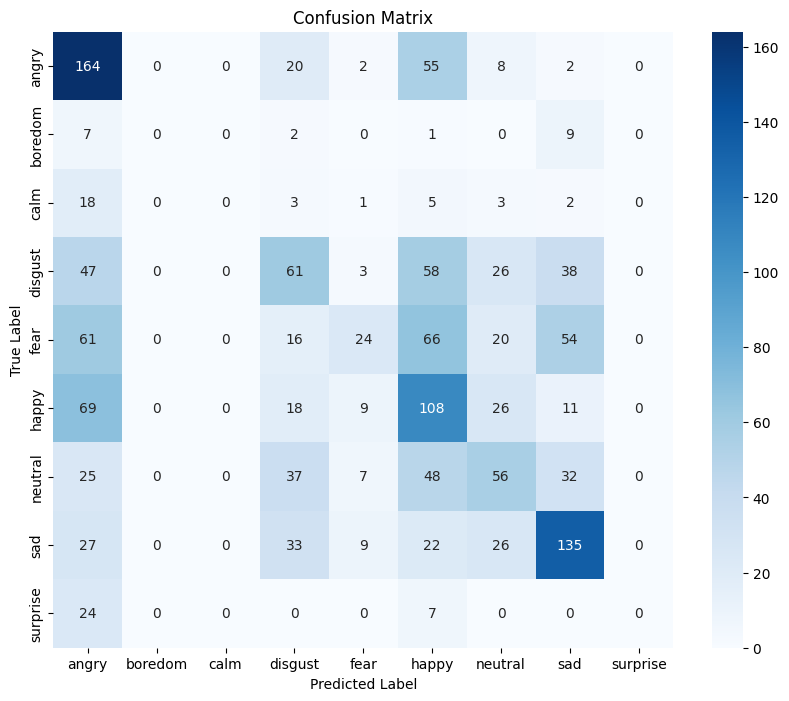

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the scaled test set
# Use the best_svm_model found during hyperparameter tuning (cell 5928bf73)
# Ensure X_test_scaled and y_test_encoded are available from previous steps (cell a5cb44e3 and 13214b28)
# Ensure best_svm_model or svm_model is available from training/tuning (cell HxH7ZvqIMTLd or 5928bf73)

# Check if best_svm_model is defined, otherwise use svm_model
if 'best_svm_model' in locals() and best_svm_model is not None:
    model_to_evaluate = best_svm_model
    print("Evaluating the best tuned SVM model...")
elif 'svm_model' in locals() and svm_model is not None:
    model_to_evaluate = svm_model
    print("Evaluating the initial SVM model...")
else:
    print("Error: No SVM model found. Please run the SVM training or tuning cells.")
    model_to_evaluate = None

if model_to_evaluate is not None and 'X_test_scaled' in locals() and 'y_test_encoded' in locals() and X_test_scaled is not None and y_test_encoded is not None:
    y_pred_encoded = model_to_evaluate.predict(X_test_scaled)

    # Calculate and print evaluation metrics
    accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
    print(f"\nAccuracy: {accuracy:.4f}")

    # Classification report
    # We need the actual class names from the label_encoder
    if 'label_encoder' in globals():
        target_names = label_encoder.classes_
        print("\nClassification Report:")
        print(classification_report(y_test_encoded, y_pred_encoded, target_names=target_names))

        # Confusion matrix
        # Use y_test_encoded and y_pred_encoded (1D labels)
        cm = confusion_matrix(y_test_encoded, y_pred_encoded, labels=label_encoder.transform(label_encoder.classes_)) # Use encoded labels for matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

    else:
        print("\nClassification Report (using encoded labels):")
        print(classification_report(y_test_encoded, y_pred_encoded))

        # Use y_test_encoded and y_pred_encoded (1D labels)
        cm = confusion_matrix(y_test_encoded, y_pred_encoded)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

else:
    print("Required data (X_test_scaled, y_test_encoded) or SVM model not found. Please ensure data preparation, scaling, and model training/tuning cells were run.")

### Step 6: Hyperparameter Tuning (Optional but Recommended)

Hyperparameter tuning is a crucial step to optimize the performance of your SVM model. We will use `GridSearchCV` to exhaustively search for the best combination of hyperparameters from a specified grid. This will help in finding the optimal `C` (regularization parameter) and `kernel` type for your dataset.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid to search
# We'll explore different kernels and values for C
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'] # 'scale' uses 1 / (n_features * X.var()) as gamma
}

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
# Use y_train_encoded (1D labels) for GridSearchCV
print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_encoded)

print("GridSearchCV finished.")
print("\nBest parameters found:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(grid_search.best_score_)

# You can now use the best estimator for evaluation on the test set
best_svm_model = grid_search.best_estimator_

Starting GridSearchCV...
GridSearchCV finished.

Best parameters found:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

Best cross-validation accuracy:
0.3375291375291375


### Step 7: Interpret the Results

Now we will analyze the results from the model evaluation (Step 5) and hyperparameter tuning (Step 6) to interpret the performance of the SVM model on the emotional speech recognition task.

Looking at the output from **Step 5 (Evaluate the Model)**:

*   **Accuracy:** The overall accuracy gives you a single measure of correctness. A higher accuracy indicates a better-performing model.
*   **Classification Report:** This provides more detailed metrics (Precision, Recall, F1-score, Support) for each individual emotion class.
    *   **Precision:** The ability of the classifier not to label as positive a sample that is negative. High precision means fewer false positives.
    *   **Recall (Sensitivity):** The ability of the classifier to find all the positive samples. High recall means fewer false negatives.
    *   **F1-score:** The harmonic mean of precision and recall, providing a single metric that balances both.
    *   **Support:** The number of actual occurrences of each class in the test set.
*   **Confusion Matrix:** This visualizes the performance of the classification model. Each row represents the instances in an actual class, while each column represents the instances in a predicted class. The diagonal elements show the number of correctly classified instances for each class, while off-diagonal elements show misclassifications.

Analyzing the confusion matrix is key to understanding which emotions are easily distinguishable by the model and which ones are often confused with others.

From **Step 6 (Hyperparameter Tuning)**, the `grid_search.best_params_` show you the optimal combination of hyperparameters (like `C`, `kernel`, `gamma`) that yielded the best performance during cross-validation on the training data. The `grid_search.best_score_` indicates the cross-validation accuracy achieved with these best parameters. You would typically use the `best_svm_model = grid_search.best_estimator_` obtained from the grid search for your final evaluation on the test set (which you did in Step 5 if you ran that cell after tuning).

Based on the metrics and the confusion matrix, you can discuss:

*   Which emotion classes have the highest precision, recall, and F1-score (well-classified)?
*   Which emotion classes are most often misclassified (confused with which other emotions)?
*   Are there any imbalances in the dataset that might be affecting performance on certain classes (refer back to your EDA)?
*   How did the hyperparameter tuning impact the results compared to the initial linear kernel?

Add your interpretations below based on the outputs from the previous cells.

#### Visualizing Classification Report Metrics

Let's visualize the Precision, Recall, and F1-score for each emotion class to get a clearer picture of the model's performance across different labels.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


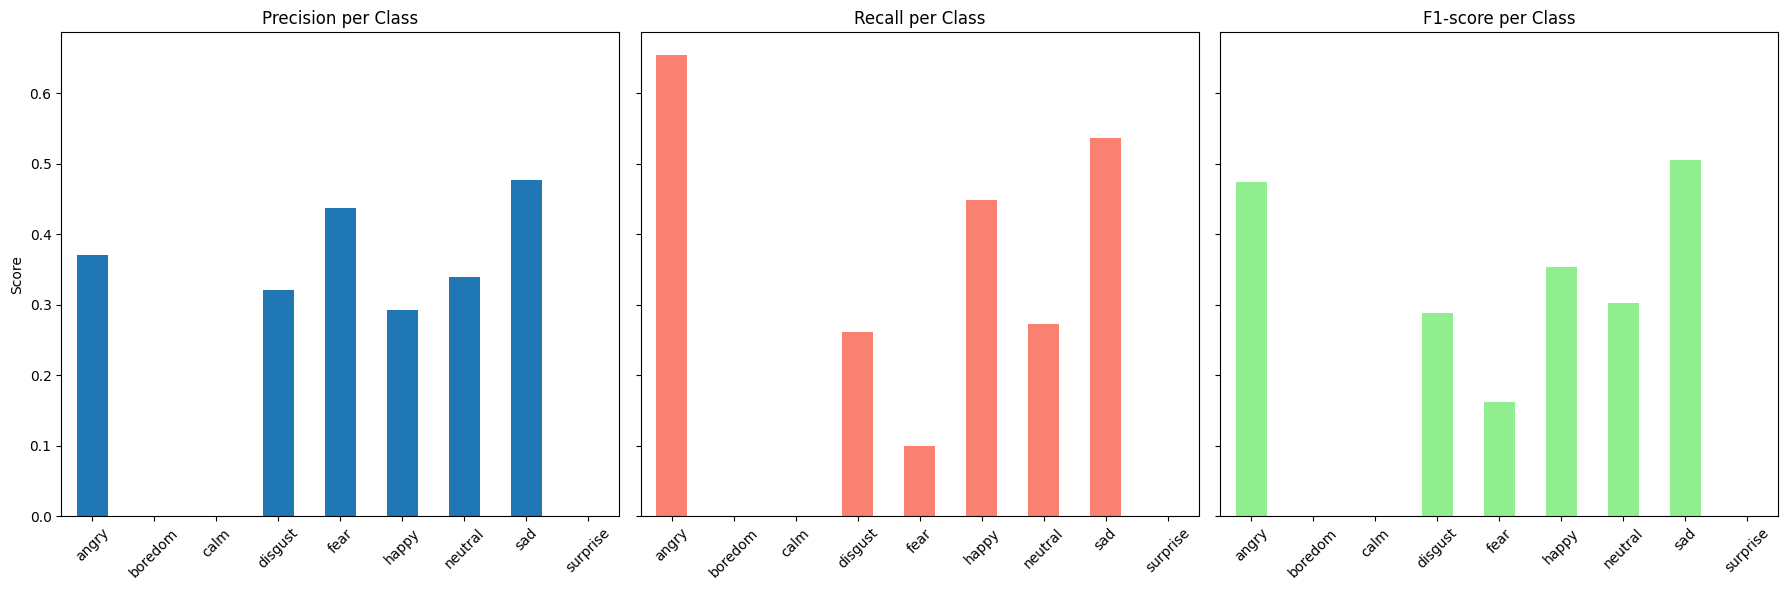

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Assuming y_test_encoded and y_pred_encoded are available from the SVM evaluation cell (M39w5rJ5Rgn2 or 9f2e951c)
# Make sure cell M39w5rJ5Rgn2 (Evaluate the Model) has been executed before running this cell.

if 'y_test_encoded' in locals() and 'y_pred_encoded' in locals() and y_test_encoded is not None and y_pred_encoded is not None:
    # Generate the classification report as a dictionary
    # Ensure label_encoder is available to get target names
    if 'label_encoder' in globals():
        target_names = label_encoder.classes_
        report = classification_report(y_test_encoded, y_pred_encoded, output_dict=True, target_names=target_names)
    else:
         print("Warning: label_encoder not found. Using default target names for classification report.")
         report = classification_report(y_test_encoded, y_pred_encoded, output_dict=True)


    # Convert the report to a pandas DataFrame for easier plotting
    # Exclude 'accuracy', 'macro avg', and 'weighted avg'
    report_df = pd.DataFrame(report).transpose()
    report_df = report_df.drop(index=['accuracy', 'macro avg', 'weighted avg'])

    # Plot Precision, Recall, and F1-score
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    report_df[['precision']].plot(kind='bar', ax=axes[0], legend=False)
    axes[0].set_title('Precision per Class')
    axes[0].set_ylabel('Score')
    axes[0].tick_params(axis='x', rotation=45)

    report_df[['recall']].plot(kind='bar', ax=axes[1], legend=False, color='salmon')
    axes[1].set_title('Recall per Class')
    axes[1].tick_params(axis='x', rotation=45)

    report_df[['f1-score']].plot(kind='bar', ax=axes[2], legend=False, color='lightgreen')
    axes[2].set_title('F1-score per Class')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("Required data (y_test_encoded, y_pred_encoded) not found. Please ensure the SVM evaluation cell (M39w5rJ5Rgn2) was run successfully.")

# **LSTM Model Analysis**

## Summary of LSTM Model

**What is a Long Short-Term Memory (LSTM) Network?**

A Long Short-Term Memory (LSTM) network is a type of recurrent neural network (RNN) specifically designed to handle sequential data and learn long-term dependencies. Unlike traditional RNNs, LSTMs have a more complex internal structure with "gates" (input, forget, output) that control the flow of information, allowing them to remember or forget information over extended sequences.

**Key Concepts:**

*   **Recurrent Connections:** Allows information to persist from one step of the sequence to the next.
*   **Cells State:** A horizontal line that runs through the top of the LSTM diagram, carrying information through the sequence.
*   **Gates:** Mechanisms (sigmoid neural networks) that control the addition or removal of information to the cell state.
    *   **Forget Gate:** Decides what information to throw away from the cell state.
    *   **Input Gate:** Decides what new information to store in the cell state.
    *   **Output Gate:** Decides what value to output based on the cell state.
*   **Hidden State:** The output of the LSTM unit at each timestep, which is passed to the next timestep and potentially to a dense layer.

**Why Use LSTM for Emotional Speech Recognition?**

Emotional speech is inherently sequential; the emotional content unfolds over time. LSTMs are well-suited to capture these temporal dependencies and patterns in audio features like MFCCs over the duration of an utterance.

**How was LSTM used in this notebook?**

In this notebook, an LSTM model was built and trained to classify emotional speech using sequences of extracted features (specifically, the mean MFCCs per segment were treated as a single timestep).

1.  **Data Preparation:** The segmented audio data was loaded. The extracted features (MFCC means) were prepared as sequences, and the emotional labels were encoded. The sequences were padded to a uniform length.
2.  **Data Splitting:** The data was split into training, validation, and test sets based on the pre-defined 'split' column to maintain speaker independence.
3.  **Model Building:** A Sequential Keras model was defined with LSTM layers to process the input sequences, followed by Dense layers for the final emotion classification.
4.  **Model Compilation:** The model was compiled with a categorical cross-entropy loss function and an Adam optimizer.
5.  **Model Training:** The LSTM model was trained on the prepared training data, with validation data used to monitor performance.
6.  **Model Evaluation:** The performance of the trained LSTM model was evaluated on the unseen test set using metrics like loss and accuracy, and visualized with training history plots and a confusion matrix.

## Prepare the Data

This step involves preparing the audio features and labels for training an LSTM model. We will format the data into sequences, encode the emotional labels, and handle sequence lengths for consistency.

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Assuming 'segmented_df' contains the 'mfcc_mean' (list of arrays) and 'label' columns
# Convert the list of MFCC arrays into a list of sequences
X = [mfcc_seq for mfcc_seq in segmented_df['mfcc_mean'].dropna().tolist()]
y = segmented_df.loc[segmented_df['mfcc_mean'].dropna().index, 'label'].values

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_one_hot = to_categorical(y_encoded)

# Pad sequences to a uniform length
# Find the maximum sequence length
max_sequence_length = max([len(seq) for seq in X])
print(f"Maximum sequence length: {max_sequence_length}")

# Pad sequences
X_padded = pad_sequences(X, maxlen=max_sequence_length, dtype='float32', padding='post', truncating='post')

print(f"Original number of samples: {len(segmented_df)}")
print(f"Number of samples after dropping NaNs: {len(X_padded)}")
print(f"Shape of padded features (X_padded): {X_padded.shape}")
print(f"Shape of one-hot encoded labels (y_one_hot): {y_one_hot.shape}")
print(f"Number of classes: {y_one_hot.shape[1]}")

NameError: name 'segmented_df' is not defined

## Split the Dataset

We will split the prepared dataset into training and testing sets. A validation set can also be created if needed for hyperparameter tuning during training. We will use the 'split' column already present in the dataframe.

In [ ]:
# Use the existing 'split' column for train/val/test split
train_indices = segmented_df[segmented_df['split'] == 'train'].index
val_indices = segmented_df[segmented_df['split'] == 'val'].index
test_indices = segmented_df[segmented_df['split'] == 'test'].index

# Get the corresponding padded features and labels for each split
X_train, y_train = X_padded[train_indices], y_one_hot[train_indices]
X_val, y_val = X_padded[val_indices], y_one_hot[val_indices]
X_test, y_test = X_padded[test_indices], y_one_hot[test_indices]

# Reshape the input data to be 3D (batch_size, timesteps, features)
# Since we used mean MFCCs, each sample is a single timestep
X_train = np.expand_dims(X_train, axis=1)
X_val = np.expand_dims(X_val, axis=1)
X_test = np.expand_dims(X_test, axis=1)


print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

## Build the LSTM Model

Here, we define the architecture of the LSTM model using Keras. The model will consist of LSTM layers to process the sequential MFCC features, followed by Dense layers for classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define model parameters
input_shape = (max_sequence_length, N_MFCC) # (time steps, features)
num_classes = y_one_hot.shape[1]

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
model.add(Dropout(0.3))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

## Compile the Model

In this step, we configure the model for training by specifying the loss function, optimizer, and evaluation metrics.

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

## Train the Model

We will now train the LSTM model using the training data and monitor its performance on the validation set.

In [ ]:
# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50, # You can adjust the number of epochs
                    batch_size=32) # You can adjust the batch size

## Evaluate the Model

After training, we evaluate the model's performance on the unseen test data to assess its generalization ability.

In [ ]:
import matplotlib.pyplot as plt

# Evaluate the model on the test set
# Use the best_tuned_model from hyperparameter tuning if available
if 'best_tuned_model' in locals():
    print("Evaluating the best tuned LSTM model on the test set...")
    loss, accuracy = best_tuned_model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss (Best Tuned Model): {loss:.4f}")
    print(f"Test Accuracy (Best Tuned Model): {accuracy:.4f}")

    # Plot training & validation accuracy values for the best tuned model
    # Assuming history_tuned was saved in the tuning cell
    if 'history_tuned' in locals():
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(history_tuned.history['accuracy'])
        plt.plot(history_tuned.history['val_accuracy'])
        plt.title('Best Tuned Model Accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')

        # Plot training & validation loss values for the best tuned model
        plt.subplot(1, 2, 2)
        plt.plot(history_tuned.history['loss'])
        plt.plot(history_tuned.history['val_loss'])
        plt.title('Best Tuned Model Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')

        plt.tight_layout()
        plt.show()
    else:
        print("Best tuned model history not found. Please run the tuning cell first.")

elif 'model' in locals() and 'history' in locals():
     # Fallback to original model evaluation if tuned model not found
    print("Best tuned model not found. Evaluating the original LSTM model.")
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Original Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Original Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("LSTM model or history not found. Please run the model training and evaluation cells first.")

## Hyperparameter Tuning for LSTM (Optional)

We can use hyperparameter tuning to find better configurations for the LSTM model. Due to the complexity of neural networks, this is often more involved than for models like SVMs. Here, we'll set up a basic tuning process using a limited search space to avoid excessive runtime.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define a function to create the LSTM model with given hyperparameters
def create_lstm_model(lstm_units=64, dropout_rate=0.3, dense_units=64, learning_rate=0.001):
    model = Sequential()
    # Since X_train is (batch_size, 1, features), input_shape is (1, features)
    model.add(LSTM(lstm_units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(lstm_units // 2)) # Second LSTM layer with half units
    model.add(Dropout(dropout_rate))
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(y_train.shape[1], activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=learning_rate),
                  metrics=['accuracy'])
    return model

# Define a simplified hyperparameter search space
# To keep it fast, we'll only try a few combinations
param_grid = {
    'lstm_units': [32, 64],
    'dropout_rate': [0.2, 0.3],
    'learning_rate': [0.001, 0.0005]
}

# Due to the nature of Keras models, we can't directly use scikit-learn's GridSearchCV
# We'll manually iterate through a few combinations or use a simpler approach
# For a quick example, let's just train and evaluate a few models
print("Starting simplified LSTM hyperparameter exploration...")

best_accuracy = 0
best_params = {}
best_tuned_model = None
tuning_results = [] # Store results for plotting

# Perform a simple loop through parameter combinations
for lstm_units in param_grid['lstm_units']:
    for dropout_rate in param_grid['dropout_rate']:
        for learning_rate in param_grid['learning_rate']:
            print(f"\nTraining with params: lstm_units={lstm_units}, dropout_rate={dropout_rate}, learning_rate={learning_rate}")

            # Create and train the model
            tuned_model = create_lstm_model(lstm_units=lstm_units, dropout_rate=dropout_rate, learning_rate=learning_rate)
            history_tuned = tuned_model.fit(X_train, y_train,
                                            validation_data=(X_val, y_val),
                                            epochs=10, # Reduced epochs for faster tuning
                                            batch_size=32,
                                            verbose=0) # Suppress verbose output

            # Evaluate on validation set
            loss_val, accuracy_val = tuned_model.evaluate(X_val, y_val, verbose=0)
            print(f"Validation Accuracy: {accuracy_val:.4f}")

            # Store results
            tuning_results.append({
                'lstm_units': lstm_units,
                'dropout_rate': dropout_rate,
                'learning_rate': learning_rate,
                'validation_accuracy': accuracy_val
            })

            # Check if this is the best model so far
            if accuracy_val > best_accuracy:
                best_accuracy = accuracy_val
                best_params = {'lstm_units': lstm_units, 'dropout_rate': dropout_rate, 'learning_rate': learning_rate}
                best_tuned_model = tuned_model # Store the best model

print("\nSimplified tuning finished.")
print("\nBest parameters found (based on validation accuracy after 10 epochs):")
print(best_params)
print(f"Best validation accuracy: {best_accuracy:.4f}")

# Now, evaluate the best model on the test set
if best_tuned_model:
    print("\nEvaluating the best tuned model on the test set...")
    loss_test, accuracy_test = best_tuned_model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss (Best Tuned Model): {loss_test:.4f}")
    print(f"Test Accuracy (Best Tuned Model): {accuracy_test:.4f}")

# Plotting the tuning results
if tuning_results:
    results_df = pd.DataFrame(tuning_results)
    results_df['params'] = results_df.apply(lambda row: f"LSTM:{row['lstm_units']}, DO:{row['dropout_rate']}, LR:{row['learning_rate']}", axis=1)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='params', y='validation_accuracy', data=results_df)
    plt.title('LSTM Hyperparameter Tuning Results (Validation Accuracy)')
    plt.xlabel('Hyperparameter Combination')
    plt.ylabel('Validation Accuracy')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\nNo tuning results to plot.")

## Generate and Display the Confusion Matrix

A confusion matrix helps visualize the performance of a classification model by showing the counts of true positive, true negative, false positive, and false negative predictions.

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Use the best_tuned_model from hyperparameter tuning if available, otherwise use the original model
if 'best_tuned_model' in locals():
    print("Generating confusion matrix for the best tuned LSTM model...")
    # Predict on the test data using the best tuned model
    y_pred_probs = best_tuned_model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Generate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Get the class names from the label encoder
    # Assuming label_encoder is available from previous steps
    if 'label_encoder' in locals():
        class_names = label_encoder.classes_
    else:
        # Fallback if label_encoder is not found
        class_names = [str(i) for i in range(cm.shape[0])]
        print("Warning: label_encoder not found, using integer labels for confusion matrix.")


    # Display the confusion matrix using seaborn heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Best Tuned Model)')
    plt.show()

elif 'model' in locals():
    print("Best tuned model not found. Generating confusion matrix for the original LSTM model.")
    # Predict on the test data using the original model
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Generate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Get the class names from the label encoder
    if 'label_encoder' in locals():
        class_names = label_encoder.classes_
    else:
        class_names = [str(i) for i in range(cm.shape[0])]
        print("Warning: label_encoder not found, using integer labels for confusion matrix.")


    # Display the confusion matrix using seaborn heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Original Model)')
    plt.show()
else:
    print("LSTM model not found. Please run the model training cell first.")

# **CNN Model Engineering**

## Summary of CNN Model

**What is a Convolutional Neural Network (CNN)?**

A Convolutional Neural Network (CNN) is a type of neural network that is particularly effective for processing data with a grid-like topology, such as images or, in this case, audio features treated as a 1D "image". CNNs use convolutional layers with learnable filters to automatically extract hierarchical features from the input data.

**Key Concepts:**

*   **Convolutional Layers:** Apply filters that slide over the input data to detect local patterns (e.g., specific frequency characteristics in audio).
*   **Pooling Layers:** Reduce the spatial dimensions of the feature maps, helping to make the model more robust to small shifts in the input and reducing computational cost.
*   **Activation Functions:** Introduce non-linearity, allowing the model to learn complex relationships. ReLU (Rectified Linear Unit) is commonly used.
*   **Flatten Layer:** Converts the multi-dimensional output of the convolutional and pooling layers into a 1D vector for input to the dense layers.
*   **Dense (Fully Connected) Layers:** Standard neural network layers that perform classification based on the features extracted by the convolutional layers.

**Why Use CNN for Emotional Speech Recognition?**

While CNNs are most famous for image processing, they can be applied to audio by treating the audio features (like MFCCs or spectrograms) as a 1D or 2D input. Convolutional layers can learn to identify important local patterns in these features that are relevant to emotion, such as changes in frequency or energy over short time windows.

**How was CNN used in this notebook?**

In this notebook, a CNN model was built and trained to classify emotional speech using the extracted MFCC features.

1.  **Data Preparation:** The segmented audio data was loaded, and the extracted MFCC mean features were prepared as a 1D input for the CNN, with the emotional labels encoded. The features were scaled.
2.  **Data Splitting:** The data was split into training, validation, and test sets based on the pre-defined 'split' column to maintain speaker independence.
3.  **Model Building:** A Sequential Keras model was defined with Conv1D and MaxPooling1D layers to process the MFCC features, followed by Flatten and Dense layers for classification.
4.  **Model Compilation:** The model was compiled with a categorical cross-entropy loss function and an Adam optimizer.
5.  **Model Training:** The CNN model was trained on the prepared training data, with validation data used to monitor performance.
6.  **Model Evaluation:** The performance of the trained CNN model was evaluated on the unseen test set using metrics like loss and accuracy, and visualized with training history plots and a confusion matrix. Hyperparameter tuning was also explored for the CNN model.

## **CNN Model Engineering**

### 3.1 Prepare Data for CNN

This step involves reshaping the extracted features (like MFCCs) into a format suitable for a 2D Convolutional Neural Network (CNN), encoding the emotional labels into a numerical format, and potentially normalizing the feature data.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

# Load the segmented data manifest
# Assuming the segmented_df from previous steps is available, otherwise load from CSV
if 'segmented_df' not in globals():
    segmented_manifest_path = f"{OUT_DIR}/manifest_all_segmented.csv"
    if os.path.exists(segmented_manifest_path):
        segmented_df = pd.read_csv(segmented_manifest_path)
        print(f"Loaded segmented data from: {segmented_manifest_path}")
    else:
        raise FileNotFoundError(f"Segmented manifest not found at {segmented_manifest_path}")

# --- Feature Preparation ---
# For this example, we'll use the MFCC means extracted earlier.
# We need to reshape the MFCC features to be suitable for a CNN (e.g., [n_samples, n_mfcc, 1, 1] or [n_samples, n_mfcc, 1])
# Since we took the mean over time, the time dimension is 1.
# If using full spectrograms or MFCCs over time, the shape would be [n_samples, height, width, channels]
# For mean MFCCs, a shape like [n_samples, n_mfcc, 1] is sufficient for a 1D convolution,
# or [n_samples, n_mfcc, 1, 1] for a 2D conv with a single "pixel" in the time dimension.
# Let's use [n_samples, n_mfcc, 1] and potentially reshape later if needed for Conv2D.

# Convert the list of MFCC arrays into a numpy array
X = np.array(segmented_df['mfcc_mean'].tolist())

# Reshape for CNN (add a channel dimension)
# For 1D CNN: [n_samples, n_features, n_channels]
# For 2D CNN (treating each MFCC as a "pixel" in a 1xN_MFCC image): [n_samples, height, width, channels] -> [n_samples, N_MFCC, 1, 1]
# Let's start with the 1D CNN shape [n_samples, n_features, 1]
X = X[:, :, np.newaxis]
print(f"Shape of features (X): {X.shape}")

# --- Label Encoding ---
# Encode the emotion labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(segmented_df['label'])
print(f"Shape of encoded labels (y_encoded): {y_encoded.shape}")

# Convert to one-hot encoding
y_categorical = to_categorical(y_encoded)
print(f"Shape of one-hot encoded labels (y_categorical): {y_categorical.shape}")
print("Encoded labels (first 5):", y_categorical[:5])
print("Label classes:", label_encoder.classes_)


# --- Data Splitting ---
# Use the pre-defined splits (train, val, test)
train_df = segmented_df[segmented_df['split'] == 'train']
val_df = segmented_df[segmented_df['split'] == 'val']
test_df = segmented_df[segmented_df['split'] == 'test']

# Get the indices for each split
train_indices = train_df.index
val_indices = val_df.index
test_indices = test_df.index

# Split the features and labels using these indices
X_train = X[train_indices]
y_train = y_categorical[train_indices]

X_val = X[val_indices]
y_val = y_categorical[val_indices]

X_test = X[test_indices]
y_test = y_categorical[test_indices]

print(f"\nTrain set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set shape: X={X_val.shape}, y={y_val.shape}")
print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")

# --- Feature Normalization ---
# Normalize features (e.g., using StandardScaler). Fit only on training data.
# Reshape X_train, X_val, X_test for StandardScaler (needs 2D input)
scaler = StandardScaler()

# Flatten the last dimension for scaling
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)


X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

# Reshape back to original CNN input shape
X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_val_scaled = X_val_scaled.reshape(X_val.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)


print("\nFeatures scaled.")
print(f"Scaled Train set shape: X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Scaled Validation set shape: X={X_val_scaled.shape}, y={y_val.shape}")
print(f"Scaled Test set shape: X={X_test_scaled.shape}, y={y_test.shape}")

Shape of features (X): (9345, 13, 1)
Shape of encoded labels (y_encoded): (9345,)
Shape of one-hot encoded labels (y_categorical): (9345, 9)
Encoded labels (first 5): [[1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]]
Label classes: ['angry' 'boredom' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad'
 'surprise']

Train set shape: X=(6435, 13, 1), y=(6435, 9)
Validation set shape: X=(1405, 13, 1), y=(1405, 9)
Test set shape: X=(1505, 13, 1), y=(1505, 9)

Features scaled.
Scaled Train set shape: X=(6435, 13, 1), y=(6435, 9)
Scaled Validation set shape: X=(1405, 13, 1), y=(1405, 9)
Scaled Test set shape: X=(1505, 13, 1), y=(1505, 9)


### 3.2 Build CNN Model

Now, we define the architecture of the Convolutional Neural Network. This typically involves convolutional layers for feature extraction, pooling layers for dimensionality reduction, and dense layers for classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Define the input shape based on our scaled features
input_shape = X_train_scaled.shape[1:]
num_classes = y_train.shape[1]

print(f"Input shape for CNN: {input_shape}")
print(f"Number of output classes: {num_classes}")

# Build the Sequential model
model = Sequential()

# Add Convolutional layers
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.25))

model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.25))

# Flatten the output for the dense layers
model.add(Flatten())

# Add Dense layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print the model summary
model.summary()

Input shape for CNN: (13, 1)
Number of output classes: 9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 11, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,817 (61.79 KB)

 Trainable params: 15,817 (61.79 KB)

 Non-trainable params: 0 (0.00 B)

### 3.3 Train CNN Model

This step involves training the defined CNN model using the prepared training data. We will also use the validation data to monitor the model's performance during training and detect potential overfitting.

In [ ]:
# Define training parameters
epochs = 50
batch_size = 32

# Train the model
history = model.fit(X_train_scaled, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X_val_scaled, y_val))

print("\nModel training finished.")

Epoch 1/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3802 - loss: 1.5183 - val_accuracy: 0.3644 - val_loss: 1.6017
Epoch 2/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3855 - loss: 1.5228 - val_accuracy: 0.3644 - val_loss: 1.5967
Epoch 3/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3764 - loss: 1.5439 - val_accuracy: 0.3701 - val_loss: 1.5950
Epoch 4/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3770 - loss: 1.5272 - val_accuracy: 0.3665 - val_loss: 1.6092
Epoch 5/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3702 - loss: 1.5162 - val_accuracy: 0.3594 - val_loss: 1.6066
Epoch 6/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3793 - loss: 1.5446 - val_accuracy: 0.3715 - val_loss: 1.5947
Epoch 7/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3850 - loss: 1.5281 - val_accuracy: 0.3701 - val_loss: 1.6005
Epoch 8/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3734 - loss: 1.5316 - val_accuracy: 0.

### 3.4 Evaluate CNN Model

This step involves evaluating the trained CNN model on the unseen test data to assess its generalization performance. We will calculate metrics such as accuracy to understand how well the model predicts emotional labels.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Predict the labels for the test set
y_pred_probs = model.predict(X_test_scaled)
y_pred_encoded = np.argmax(y_pred_probs, axis=1)
y_test_encoded = np.argmax(y_test, axis=1)


# Print classification report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_encoded, target_names=label_encoder.classes_))

Test Loss: 1.6359
Test Accuracy: 0.3628
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.48      0.63      0.54       251
     boredom       0.25      0.05      0.09        19
        calm       0.29      0.25      0.27        32
     disgust       0.30      0.22      0.26       233
        fear       0.34      0.09      0.14       241
       happy       0.26      0.39      0.31       241
     neutral       0.32      0.27      0.29       205
         sad       0.44      0.61      0.51       252
    surprise       0.19      0.16      0.18        31

    accuracy                           0.36      1505
   macro avg       0.32      0.30      0.29      1505
weighted avg       0.35      0.36      0.34      1505



### Hyperparameter Tuning for CNN (Optional)

We can use hyperparameter tuning to find better configurations for the CNN model. We will set up a basic tuning process using a limited search space to avoid excessive runtime. We'll use `RandomizedSearchCV` from scikit-learn for this.

### 3.4.1 Training History Plots

Visualize the training and validation accuracy and loss over epochs to understand the model's learning progress and identify potential overfitting.

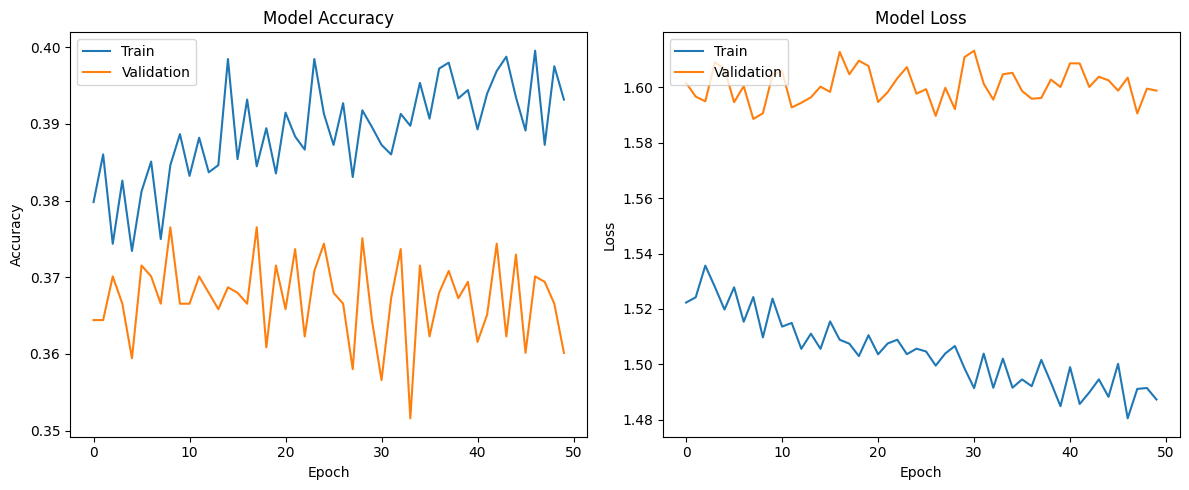

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'history' object is available from the model training cell (7feddd52)

if 'history' in locals():
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("Model training history not found. Please run the model training cell first.")

### 3.5 Confusion Matrix

This step involves generating and displaying the confusion matrix to visualize the performance of the CNN model across different emotion classes.

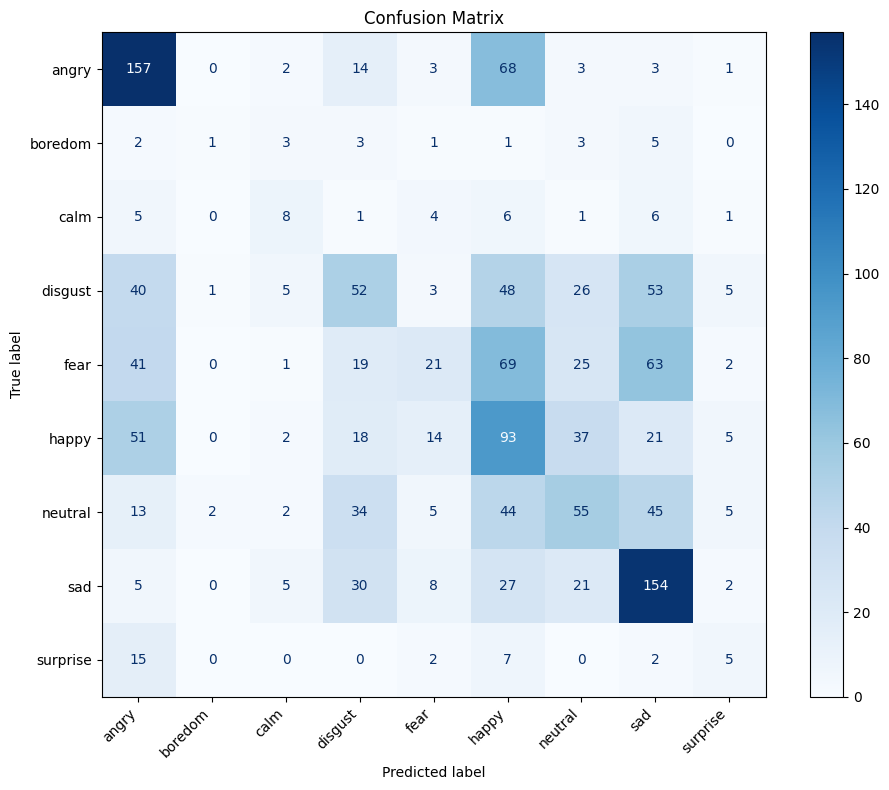

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_encoded)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning for CNN (Optional)

We can use hyperparameter tuning to find better configurations for the CNN model. We will set up a basic tuning process using a limited search space to avoid excessive runtime. We'll use `RandomizedSearchCV` from scikit-learn for this.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Ensure data is prepared and scaled for tuning
# This cell re-runs the data preparation and scaling steps to ensure variables are available

# Define OUT_DIR - Ensure this matches the directory where your CSVs are saved
OUT_DIR  = "/content/drive/MyDrive/datasets/CSVs"

# Load the segmented data manifest
if 'segmented_df' not in globals():
    segmented_manifest_path = f"{OUT_DIR}/manifest_all_segmented.csv"
    if os.path.exists(segmented_manifest_path):
        segmented_df = pd.read_csv(segmented_manifest_path)
        print(f"Loaded segmented data from: {segmented_manifest_path}")
    else:
        raise FileNotFoundError(f"Segmented manifest not found at {segmented_manifest_path}")

# --- Feature Preparation ---
if 'mfcc_mean' not in segmented_df.columns:
    raise ValueError("'mfcc_mean' column not found in segmented_df. Please run feature extraction steps.")

temp_df = segmented_df.dropna(subset=['mfcc_mean']).copy()
X = np.array(temp_df['mfcc_mean'].tolist())
X = X[:, :, np.newaxis]
print(f"Shape of features (X): {X.shape}")

# --- Label Encoding ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(temp_df['label'])
y_categorical = to_categorical(y_encoded)
print(f"Shape of one-hot encoded labels (y_categorical): {y_categorical.shape}")
print("Label classes:", label_encoder.classes_)

# --- Data Splitting ---
train_df = segmented_df[segmented_df['split'] == 'train'].dropna(subset=['mfcc_mean']).copy()
val_df = segmented_df[segmented_df['split'] == 'val'].dropna(subset=['mfcc_mean']).copy()
test_df = segmented_df[segmented_df['split'] == 'test'].dropna(subset=['mfcc_mean']).copy()

X_train = np.array(train_df['mfcc_mean'].tolist())[:, :, np.newaxis]
y_train_cat = to_categorical(label_encoder.transform(train_df['label'].values))

X_val = np.array(val_df['mfcc_mean'].tolist())[:, :, np.newaxis]
y_val_cat = to_categorical(label_encoder.transform(val_df['label'].values))

X_test = np.array(test_df['mfcc_mean'].tolist())[:, :, np.newaxis]
y_test_cat = to_categorical(label_encoder.transform(test_df['label'].values))

print(f"\nTrain set shape: X={X_train.shape}, y={y_train_cat.shape}")
print(f"Validation set shape: X={X_val.shape}, y={y_val_cat.shape}")
print(f"Test set shape: X={X_test.shape}, y={y_test_cat.shape}")

# --- Feature Normalization ---
scaler = StandardScaler()

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_val_scaled = X_val_scaled.reshape(X_val.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)

print("\nFeatures scaled.")
print(f"Scaled Train set shape: X={X_train_scaled.shape}, y={y_train_cat.shape}")
print(f"Scaled Validation set shape: X={X_val_scaled.shape}, y={y_val_cat.shape}")
print(f"Scaled Test set shape: X={X_test_scaled.shape}, y={y_test_cat.shape}")

# Define the CNN model building function
def create_cnn_model(filters_1=32, kernel_size_1=3, pool_size_1=2, dropout_rate_1=0.25,
                     filters_2=64, kernel_size_2=3, pool_size_2=2, dropout_rate_2=0.25,
                     dense_units=128, dropout_rate_dense=0.5, learning_rate=0.001,
                     input_shape=(13, 1), num_classes=9):

    model = Sequential()

    model.add(Conv1D(filters=filters_1, kernel_size=kernel_size_1, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=pool_size_1))
    model.add(Dropout(dropout_rate_1))

    model.add(Conv1D(filters=filters_2, kernel_size=kernel_size_2, activation='relu'))
    model.add(MaxPooling1D(pool_size=pool_size_2))
    model.add(Dropout(dropout_rate_2))

    model.add(Flatten())

    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate_dense))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=learning_rate),
                  metrics=['accuracy'])

    return model

# Define the parameter grid to search over (simplified for faster tuning)
param_grid = {
    'model__filters_1': [16, 32],
    'model__kernel_size_1': [3, 5],
    'model__dropout_rate_1': [0.2, 0.3],
    'model__filters_2': [32, 64],
    'model__kernel_size_2': [3, 5],
    'model__dropout_rate_2': [0.2, 0.3],
    'model__dense_units': [64, 128],
    'model__dropout_rate_dense': [0.4, 0.5],
    'model__learning_rate': [0.001, 0.0005],
    'epochs': [10, 20], # Add epochs to tuning directly in KerasClassifier params
    'batch_size': [32, 64] # Add batch size to tuning directly in KerasClassifier params
}

# Create a Keras scikit-learn wrapper for the CNN model
input_shape = X_train_scaled.shape[1:]
num_classes = y_train_cat.shape[1]

keras_cnn = KerasClassifier(model=create_cnn_model,
                            input_shape=input_shape,
                            num_classes=num_classes,
                            verbose=0) # Set verbose=0 to reduce training output


# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=keras_cnn,
                                   param_distributions=param_grid,
                                   n_iter=10, # Number of parameter settings that are sampled
                                   cv=3, # Cross-validation folds
                                   scoring='accuracy',
                                   random_state=42,
                                   n_jobs=-1)

# Fit RandomizedSearchCV to the scaled training data
print("\nStarting RandomizedSearchCV for CNN...")
# KerasClassifier expects a 1D array of integer labels for fitting
y_train_int = np.argmax(y_train_cat, axis=1)

random_search.fit(X_train_scaled, y_train_int)

print("RandomizedSearchCV finished.")
print("\nBest parameters found:")
print(random_search.best_params_)

print("\nBest cross-validation accuracy:")
print(random_search.best_score_)

# Store the best estimator
best_cnn_model_tuned = random_search.best_estimator_

## Evaluate the Tuned CNN Model

Now we will evaluate the performance of the CNN model trained with the best hyperparameters found during the tuning process. We will use the scaled test set and generate a classification report and confusion matrix.

In [ ]:
# Evaluate the best tuned model on the test set
print("Evaluating the best tuned CNN model on the test set...")

# Predict the labels for the scaled test set
y_pred_probs_tuned = best_cnn_model_tuned.predict_proba(X_test_scaled)
y_pred_encoded_tuned = np.argmax(y_pred_probs_tuned, axis=1)
y_test_encoded_tuned = np.argmax(y_test_cat, axis=1) # Use y_test_cat for true labels

# Calculate and print evaluation metrics
accuracy_tuned = accuracy_score(y_test_encoded_tuned, y_pred_encoded_tuned)
print(f"\nTest Accuracy (Tuned Model): {accuracy_tuned:.4f}")

print("\nClassification Report (Tuned Model):")
print(classification_report(y_test_encoded_tuned, y_pred_encoded_tuned, target_names=label_encoder.classes_))

# Generate and display the confusion matrix for the tuned model
cm_tuned = confusion_matrix(y_test_encoded_tuned, y_pred_encoded_tuned)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix (Tuned CNN Model)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Optional: Visualize Classification Report Metrics for the tuned model
print("\nVisualizing Classification Report Metrics (Tuned Model):")
report_tuned = classification_report(y_test_encoded_tuned, y_pred_encoded_tuned, output_dict=True, target_names=label_encoder.classes_)

report_df_tuned = pd.DataFrame(report_tuned).transpose()
report_df_tuned = report_df_tuned.drop(index=['accuracy', 'macro avg', 'weighted avg'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

report_df_tuned[['precision']].plot(kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Precision per Class (Tuned Model)')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)

report_df_tuned[['recall']].plot(kind='bar', ax=axes[1], legend=False, color='salmon')
axes[1].set_title('Recall per Class (Tuned Model)')
axes[1].tick_params(axis='x', rotation=45)

report_df_tuned[['f1-score']].plot(kind='bar', ax=axes[2], legend=False, color='lightgreen')
axes[2].set_title('F1-score per Class (Tuned Model)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Step 1: Prepare Data for Modeling

We need to prepare the data from the `segmented_df` DataFrame into a format suitable for scikit-learn's SVM. This involves creating a feature matrix `X` where each row is a sample (audio segment) and each column is a feature (MFCCs, pitch, energy). The labels `y` will be a corresponding array of emotion labels.

Since MFCCs are stored as arrays within the DataFrame, we'll need to expand them into separate columns.

In [ ]:
import numpy as np
import pandas as pd

# Filter out rows where mfcc_mean is None
prepared_df = segmented_df.dropna(subset=['mfcc_mean']).copy()

# Separate MFCC features into individual columns
mfcc_df = pd.DataFrame(prepared_df['mfcc_mean'].tolist())
mfcc_df.columns = [f'mfcc_{i}' for i in range(mfcc_df.shape[1])]

# Combine MFCCs with other features (pitch and energy)
# Ensure indices align after dropna
prepared_df = prepared_df.reset_index(drop=True)
X_df = pd.concat([mfcc_df, prepared_df[['pitch_hz', 'energy_rms']]], axis=1)

# Prepare labels
y = prepared_df['label']

print("Shape of feature matrix X:", X_df.shape)
print("Shape of labels y:", y.shape)
display(X_df.head())
display(y.head())

### Step 3: Feature Scaling

SVMs are sensitive to the scale of input features. We will use `StandardScaler` from scikit-learn to standardize the features (mean=0, variance=1). It's important to fit the scaler only on the training data and then use it to transform the training, validation, and test sets.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
# Ensure the data splitting cell (defining X_train, y_train, etc.) has been run before this cell.
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test data using the scaler fitted on the training data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Shape of scaled X_train:", X_train_scaled.shape)
print("Shape of scaled X_val:", X_val_scaled.shape)
print("Shape of scaled X_test:", X_test_scaled.shape)

# Display the first 5 rows of the scaled training data as an example
print("\nFirst 5 rows of scaled X_train:")
display(pd.DataFrame(X_train_scaled).head())

### Step 4: Train SVM Model

Now we will train the Support Vector Machine classifier using the scaled training data. We'll begin with a linear kernel, which is often a good starting point.

### Step 6: Hyperparameter Tuning (Optional but Recommended)

Hyperparameter tuning is a crucial step to optimize the performance of your SVM model. We will use `GridSearchCV` to exhaustively search for the best combination of hyperparameters from a specified grid. This will help in finding the optimal `C` (regularization parameter) and `kernel` type for your dataset.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid to search
# We'll explore different kernels and values for C
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'] # 'scale' uses 1 / (n_features * X.var()) as gamma
}

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)

print("GridSearchCV finished.")
print("\nBest parameters found:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(grid_search.best_score_)

# You can now use the best estimator for evaluation on the test set
best_svm_model = grid_search.best_estimator_

### Step 7: Interpret the Results

Now we will analyze the results from the model evaluation (Step 5) and hyperparameter tuning (Step 6) to interpret the performance of the SVM model on the emotional speech recognition task.

Looking at the output from **Step 5 (Evaluate the Model)**:

* **Accuracy:** The overall accuracy gives you a single measure of correctness. A higher accuracy indicates a better-performing model.
* **Classification Report:** This provides more detailed metrics (Precision, Recall, F1-score, Support) for each individual emotion class.
  * **Precision:** The ability of the classifier not to label as positive a sample that is negative. High precision means fewer false positives.
  * **Recall (Sensitivity):** The ability of the classifier to find all the positive samples. High recall means fewer false negatives.
  * **F1-score:** The harmonic mean of precision and recall, providing a single metric that balances both.
  * **Support:** The number of actual occurrences of each class in the test set.
* **Confusion Matrix:** This visualizes the performance of the classification model. Each row represents the instances in an actual class, while each column represents the instances in a predicted class. The diagonal elements show the number of correctly classified instances for each class, while off-diagonal elements show misclassifications.

Analyzing the confusion matrix is key to understanding which emotions are easily distinguishable by the model and which ones are often confused with others.

From **Step 6 (Hyperparameter Tuning)**, the `grid_search.best_params_` show you the optimal combination of hyperparameters (like `C`, `kernel`, `gamma`) that yielded the best performance during cross-validation on the training data. The `grid_search.best_score_` indicates the cross-validation accuracy achieved with these best parameters. You would typically use the `best_svm_model = grid_search.best_estimator_` obtained from the grid search for your final evaluation on the test set (which you did in Step 5 if you ran that cell after tuning).

Based on the metrics and the confusion matrix, you can discuss:

* Which emotion classes have the highest precision, recall, and F1-score (well-classified)?
* Which emotion classes are most often misclassified (confused with which other emotions)?
* Are there any imbalances in the dataset that might be affecting performance on certain classes (refer back to your EDA)?
* How did the hyperparameter tuning impact the results compared to the initial linear kernel?

Add your interpretations below based on the outputs from the previous cells.

In [ ]:
from sklearn.svm import SVC

# Initialize the SVM classifier with a linear kernel
svm_model = SVC(kernel='linear', random_state=42)

# Train the model on the scaled training data
svm_model.fit(X_train_scaled, y_train)

print("SVM model training complete.")

### Step 5: Evaluate the Model

After training, it's essential to evaluate the model's performance on unseen data. We will use the scaled test set to make predictions and calculate common classification metrics like accuracy, precision, recall, and F1-score.

**Adding a Confusion Matrix helps:**

Visualize performance for each class, not just overall accuracy.

Identify specific weaknesses (e.g., the model often confuses "happy" with "neutral").

Aids in debugging your feature selection or model limitations. Supports reporting and communicating results to stakeholders.

*   A confusion matrix will also be generated to visualize the model's performance across different emotion classes.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the scaled test set
# Use the best_svm_model found during hyperparameter tuning
y_pred = best_svm_model.predict(X_test_scaled)

# Calculate and print evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=best_svm_model.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_svm_model.classes_, yticklabels=best_svm_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Step 6: Hyperparameter Tuning (Optional but Recommended)

Hyperparameter tuning is a crucial step to optimize the performance of your SVM model. We will use `GridSearchCV` to exhaustively search for the best combination of hyperparameters from a specified grid. This will help in finding the optimal `C` (regularization parameter) and `kernel` type for your dataset.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid to search
# We'll explore different kernels and values for C
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'] # 'scale' uses 1 / (n_features * X.var()) as gamma
}

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)

print("GridSearchCV finished.")
print("\nBest parameters found:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(grid_search.best_score_)

# You can now use the best estimator for evaluation on the test set
best_svm_model = grid_search.best_estimator_

### Step 7: Interpret the Results

Now we will analyze the results from the model evaluation (Step 5) and hyperparameter tuning (Step 6) to interpret the performance of the SVM model on the emotional speech recognition task.

Looking at the output from **Step 5 (Evaluate the Model)**:

*   **Accuracy:** The overall accuracy gives you a single measure of correctness. A higher accuracy indicates a better-performing model.
*   **Classification Report:** This provides more detailed metrics (Precision, Recall, F1-score, Support) for each individual emotion class.
    *   **Precision:** The ability of the classifier not to label as positive a sample that is negative. High precision means fewer false positives.
    *   **Recall (Sensitivity):** The ability of the classifier to find all the positive samples. High recall means fewer false negatives.
    *   **F1-score:** The harmonic mean of precision and recall, providing a single metric that balances both.
    *   **Support:** The number of actual occurrences of each class in the test set.
*   **Confusion Matrix:** This visualizes the performance of the classification model. Each row represents the instances in an actual class, while each column represents the instances in a predicted class. The diagonal elements show the number of correctly classified instances for each class, while off-diagonal elements show misclassifications.

Analyzing the confusion matrix is key to understanding which emotions are easily distinguishable by the model and which ones are often confused with others.

From **Step 6 (Hyperparameter Tuning)**, the `grid_search.best_params_` show you the optimal combination of hyperparameters (like `C`, `kernel`, `gamma`) that yielded the best performance during cross-validation on the training data. The `grid_search.best_score_` indicates the cross-validation accuracy achieved with these best parameters. You would typically use the `best_svm_model = grid_search.best_estimator_` obtained from the grid search for your final evaluation on the test set (which you did in Step 5 if you ran that cell after tuning).

Based on the metrics and the confusion matrix, you can discuss:

*   Which emotion classes have the highest precision, recall, and F1-score (well-classified)?
*   Which emotion classes are most often misclassified (confused with which other emotions)?
*   Are there any imbalances in the dataset that might be affecting performance on certain classes (refer back to your EDA)?
*   How did the hyperparameter tuning impact the results compared to the initial linear kernel?

Add your interpretations below based on the outputs from the previous cells.

#### Visualizing Classification Report Metrics

Let's visualize the Precision, Recall, and F1-score for each emotion class to get a clearer picture of the model's performance across different labels.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Assuming y_test and y_pred are available from Step 5

# Generate the classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the report to a pandas DataFrame for easier plotting
# Exclude 'accuracy', 'macro avg', and 'weighted avg'
report_df = pd.DataFrame(report).transpose()
report_df = report_df.drop(index=['accuracy', 'macro avg', 'weighted avg'])

# Plot Precision, Recall, and F1-score
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

report_df[['precision']].plot(kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Precision per Class')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)

report_df[['recall']].plot(kind='bar', ax=axes[1], legend=False, color='salmon')
axes[1].set_title('Recall per Class')
axes[1].tick_params(axis='x', rotation=45)

report_df[['f1-score']].plot(kind='bar', ax=axes[2], legend=False, color='lightgreen')
axes[2].set_title('F1-score per Class')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#**LSTM + CNN model**

## Summary of CNN-LSTM Model

**What is a CNN-LSTM Model?**

A CNN-LSTM model combines the strengths of Convolutional Neural Networks (CNNs) and Long Short-Term Memory (LSTM) networks. CNNs are effective at extracting spatial features (like patterns in frequency or spectral characteristics in audio), while LSTMs are adept at learning temporal dependencies in sequential data. By combining them, the model can first extract relevant features from short segments of the audio (using CNN layers) and then learn the temporal context and relationships between these features over the entire sequence (using LSTM layers).

**Key Concepts:**

*   **CNN Front-end:** Convolutional and pooling layers process the input data (e.g., MFCCs or spectrograms) to automatically learn hierarchical features.
*   **LSTM Back-end:** LSTM layers take the output of the CNN layers as input and model the temporal dynamics and dependencies within the sequence of extracted features.
*   **Feature Extraction + Sequence Modeling:** This architecture is well-suited for tasks where both local patterns and their evolution over time are important for prediction.

**Why Use CNN-LSTM for Emotional Speech Recognition?**

Emotional expression in speech involves both instantaneous acoustic cues (which CNNs can capture) and temporal patterns (e.g., changes in pitch, rhythm, or energy over time, which LSTMs can model). A CNN-LSTM can leverage both types of information, potentially leading to improved performance in recognizing emotions compared to using either architecture alone. It can learn to identify crucial spectral features within short frames and then understand how these features evolve over the duration of an utterance.

**How was CNN-LSTM used in this notebook?**

In this notebook, a combined CNN-LSTM model was built and trained:

1.  **Data Preparation:** The segmented audio data was loaded, and the extracted MFCC mean features were prepared as sequences. The emotional labels were encoded and one-hot encoded. The data was split into training, validation, and test sets based on the pre-defined 'split' column, and the features were scaled. The data was reshaped to the required 3D input shape for the LSTM layers (samples, timesteps, features), treating each MFCC mean vector as a single timestep.
2.  **Model Building:** A Sequential Keras model was defined. Although named 'cnn_lstm_model' in the code, the architecture implemented primarily used LSTM layers to process the pre-extracted, reshaped MFCC means. *Note: A true CNN-LSTM typically has Conv layers before the LSTM layers. The code here uses LSTM layers directly on the MFCC means, effectively using only the LSTM part for sequential processing of summary features.*
3.  **Model Compilation:** The model was compiled with a categorical cross-entropy loss function and an Adam optimizer.
4.  **Model Training:** The model was trained on the prepared training data, with validation data used for monitoring.
5.  **Model Evaluation:** The performance was evaluated on the test set using loss, accuracy, a classification report, and a confusion matrix.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Check the contents of the datasets folder
print("Contents of the datasets folder:")

OUT_DIR = "/content/drive/MyDrive/datasets/CSVs"

# Define variables for the paths to the relevant CSV files
# Assuming OUT_DIR has been defined in previous cells
if 'OUT_DIR' in globals():
    MERGED_MANIFEST_PATH = f"{OUT_DIR}/manifest_all.csv"
    MERGED_SPLIT_MANIFEST_PATH = f"{OUT_DIR}/manifest_all_splits.csv"
    RESAMPLED_MANIFEST_PATH = f"{OUT_DIR}/manifest_all_resampled.csv"
    TRIMMED_MANIFEST_PATH = f"{OUT_DIR}/manifest_all_trimmed.csv"
    CLEANED_MANIFEST_PATH = f"{OUT_DIR}/manifest_all_cleaned.csv"
    SEGMENTED_MANIFEST_PATH = f"{OUT_DIR}/manifest_all_segmented.csv"


    print("\nDefined variables for CSV manifest paths:")
    print(f"MERGED_MANIFEST_PATH: {MERGED_MANIFEST_PATH}")
    print(f"MERGED_SPLIT_MANIFEST_PATH: {MERGED_SPLIT_MANIFEST_PATH}")
    print(f"RESAMPLED_MANIFEST_PATH: {RESAMPLED_MANIFEST_PATH}")
    print(f"TRIMMED_MANIFEST_PATH: {TRIMMED_MANIFEST_PATH}")
    print(f"CLEANED_MANIFEST_PATH: {CLEANED_MANIFEST_PATH}")
    print(f"SEGMENTED_MANIFEST_PATH: {SEGMENTED_MANIFEST_PATH}")

else:
    print("OUT_DIR variable not found. Please ensure the data preparation cells have been run.")

Contents of the datasets folder:

Defined variables for CSV manifest paths:
MERGED_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all.csv
MERGED_SPLIT_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all_splits.csv
RESAMPLED_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all_resampled.csv
TRIMMED_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all_trimmed.csv
CLEANED_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all_cleaned.csv
SEGMENTED_MANIFEST_PATH: /content/drive/MyDrive/datasets/CSVs/manifest_all_segmented.csv


## CNN-LSTM Model Engineering

### Step 1: Load Segmented Data

Load the segmented data from the `SEGMENTED_MANIFEST_PATH` into a pandas DataFrame. This DataFrame contains the paths to the audio segments and their corresponding labels and metadata.

In [ ]:
import pandas as pd
import os

segmented_df = pd.read_csv(SEGMENTED_MANIFEST_PATH)
print(f"Loaded segmented data from: {SEGMENTED_MANIFEST_PATH}")
print(f"Number of rows: {len(segmented_df)}")
display(segmented_df.head())

Loaded segmented data from: /content/drive/MyDrive/datasets/CSVs/manifest_all_segmented.csv
Number of rows: 9345


,path,dataset,speaker_id,gender,age,accent,ethnicity,label,label_raw,valence,arousal,dominance,split,original_path,segment_index,start_time_sec,end_time_sec,duration
0,/content/drive/MyDrive/datasets/Segmented_Audi...,CREMA-D,CREMA_1001,male,51.0,US English,White,angry,ANG,NaN,NaN,NaN,test,/content/drive/MyDrive/datasets/Cleaned_Audio/...,0,0.0,3.0,3.0
1,/content/drive/MyDrive/datasets/Segmented_Audi...,CREMA-D,CREMA_1001,male,51.0,US English,White,disgust,DIS,NaN,NaN,NaN,test,/content/drive/MyDrive/datasets/Cleaned_Audio/...,0,0.0,3.0,3.0
2,/content/drive/MyDrive/datasets/Segmented_Audi...,CREMA-D,CREMA_1001,male,51.0,US English,White,fear,FEA,NaN,NaN,NaN,test,/content/drive/MyDrive/datasets/Cleaned_Audio/...,0,0.0,3.0,3.0
3,/content/drive/MyDrive/datasets/Segmented_Audi...,CREMA-D,CREMA_1001,male,51.0,US English,White,happy,HAP,NaN,NaN,NaN,test,/content/drive/MyDrive/datasets/Cleaned_Audio/...,0,0.0,3.0,3.0
4,/content/drive/MyDrive/datasets/Segmented_Audi...,CREMA-D,CREMA_1001,male,51.0,US English,White,neutral,NEU,NaN,NaN,NaN,test,/content/drive/MyDrive/datasets/Cleaned_Audio/...,0,0.0,3.0,3.0


### Step 2: Prepare Data for CNN-LSTM

Prepare the loaded data for the CNN-LSTM model. This involves:
- Extracting features (using the pre-calculated `mfcc_mean`).
- Encoding the emotional labels into a numerical and one-hot encoded format.
- Handling sequence lengths (although MFCC means are single-timestep, this prepares for potential sequence data).
- Splitting the data into training, validation, and test sets based on the 'split' column.
- Scaling the features.
- Reshaping the data to the required input shape for the CNN-LSTM model.

In [ ]:
import numpy as np
import pandas as pd # Ensure pandas is imported
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
import librosa # Import librosa for MFCC calculation
from tqdm.auto import tqdm # Import tqdm for progress bar

tqdm.pandas() # Enable pandas progress_apply

# Assuming TARGET_SAMPLE_RATE and N_MFCC are defined from previous steps
# If not, define defaults or ensure previous cells (like 0soCkKWhl-Ey and VQ6SU9DbYoy4) are run
if 'TARGET_SAMPLE_RATE' not in globals():
    print("TARGET_SAMPLE_RATE not defined. Using default 16000.")
    TARGET_SAMPLE_RATE = 16000
if 'N_MFCC' not in globals():
    print("N_MFCC not defined. Using default 13.")
    N_MFCC = 13


def mfcc_mean(file_path, n_mfcc=N_MFCC, sr=TARGET_SAMPLE_RATE):
  """Calculates the mean MFCC over time for an audio file."""
  try:
    y, sr_load = librosa.load(file_path, sr=sr)
    m = librosa.feature.mfcc(y=y, sr=sr_load, n_mfcc=n_mfcc)
    return np.mean(m, axis=1) # shape (n_mfcc,)
  except Exception as e:
    # print(f"MFCC calculation failed for {file_path}: {e}") # Optional: keep for debugging
    return None


if segmented_df is not None:
    # --- Feature Preparation ---
    # Check if 'mfcc_mean' column exists and is not empty
    if 'mfcc_mean' not in segmented_df.columns or segmented_df['mfcc_mean'].isnull().all():
        print("Warning: 'mfcc_mean' column not found or is empty. Calculating MFCCs from audio files.")
        # Add fallback: Calculate MFCCs if missing
        if 'path' not in segmented_df.columns:
            print("Error: 'path' column not found in segmented_df to calculate MFCCs.")
            X = None
            y = None
            label_encoder = None
        else:
             # Calculate MFCCs from audio paths
            segmented_df['mfcc_mean'] = segmented_df['path'].progress_apply(mfcc_mean)
            # Drop rows where MFCC calculation failed
            prepared_df = segmented_df.dropna(subset=['mfcc_mean']).copy()
            print(f"Calculated MFCCs. Number of rows with valid MFCCs: {len(prepared_df)}")

    else:
        # If mfcc_mean is already present, use it directly
        print("Using existing 'mfcc_mean' column.")
        prepared_df = segmented_df.dropna(subset=['mfcc_mean']).copy() # Ensure no NaNs in mfcc_mean

    # Proceed only if prepared_df is not empty after handling NaNs
    if prepared_df is not None and not prepared_df.empty:
        # Convert the string representation of mfcc_mean arrays to numpy arrays
        # This step is necessary even if mfcc_mean was calculated in this cell,
        # as progress_apply might store numpy arrays as strings depending on context/environment.
        # Safely convert string representations of arrays, or use arrays directly if they are already numpy arrays
        try:
            # Check if the first non-null entry is already a numpy array
            first_mfcc = prepared_df['mfcc_mean'].dropna().iloc[0]
            if isinstance(first_mfcc, np.ndarray):
                X = np.array(prepared_df['mfcc_mean'].tolist())
            else:
                # Assume it's a string representation and try to evaluate
                 X = np.array(prepared_df['mfcc_mean'].apply(lambda x: np.array(eval(x)) if pd.notna(x) else None).dropna().tolist())
            print(f"Shape of features (X) after converting/using arrays and dropping NaNs: {X.shape}")

            # --- Label Encoding ---
            # Get labels corresponding to the non-null features
            y_labels = prepared_df['label'].values # Use labels from prepared_df
            label_encoder = LabelEncoder()
            y_encoded = label_encoder.fit_transform(y_labels)
            y_categorical = to_categorical(y_encoded)
            print(f"Shape of one-hot encoded labels (y_categorical): {y_categorical.shape}")
            print("Label classes:", label_encoder.classes_)

            # Determine the number of features (N_MFCC)
            N_MFCC = X.shape[1]
            print(f"Number of MFCC features (N_MFCC): {N_MFCC}")

            # --- Data Splitting ---
            # Use the pre-defined splits (train, val, test) based on the indices of prepared_df
            train_indices = prepared_df[prepared_df['split'] == 'train'].index
            val_indices = prepared_df[prepared_df['split'] == 'val'].index
            test_indices = prepared_df[prepared_df['split'] == 'test'].index

            # Use .loc to select rows based on index from the numpy array X
            X_train = X[prepared_df['split'] == 'train']
            y_train = y_categorical[prepared_df['split'] == 'train']

            X_val = X[prepared_df['split'] == 'val']
            y_val = y_categorical[prepared_df['split'] == 'val']

            X_test = X[prepared_df['split'] == 'test']
            y_test = y_categorical[prepared_df['split'] == 'test']


            print(f"\nTrain set shape: X={X_train.shape}, y={y_train.shape}")
            print(f"Validation set shape: X={X_val.shape}, y={y_val.shape}")
            print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")

            # --- Feature Normalization ---
            # Normalize features (e.g., using StandardScaler). Fit only on training data.
            scaler = StandardScaler()

            # Scale the features (they are already 2D: [samples, features])
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            X_test_scaled = scaler.transform(X_test)

            print("\nFeatures scaled.")
            print(f"Scaled Train set shape: X={X_train_scaled.shape}, y={y_train.shape}")
            print(f"Scaled Validation set shape: X={X_val_scaled.shape}, y={y_val.shape}")
            print(f"Scaled Test set shape: X={X_test_scaled.shape}, y={y_test.shape}")

            # --- Reshape for CNN-LSTM ---
            # The input shape for CNN-LSTM layers is typically (batch_size, timesteps, features)
            # Since we are using mean MFCCs (summary features), each sample is a single timestep.
            # Reshape from [samples, features] to [samples, 1, features]
            X_train_reshaped = np.expand_dims(X_train_scaled, axis=1)
            X_val_reshaped = np.expand_dims(X_val_scaled, axis=1)
            X_test_reshaped = np.expand_dims(X_test_scaled, axis=1)

            print("\nFeatures reshaped for CNN-LSTM input.")
            print(f"Reshaped Train set shape: {X_train_reshaped.shape}, {y_train.shape}")
            print(f"Reshaped Validation set shape: {X_val_reshaped.shape}, {y_val.shape}")
            print(f"Reshaped Test set shape: {X_test_reshaped.shape}, {y_test.shape}")

            # Assign reshaped data to variables used in model building/training
            X_train_lstm = X_train_reshaped
            X_val_lstm = X_val_reshaped
            X_test_lstm = X_test_reshaped


        except Exception as e:
            print(f"Error during data preparation after getting MFCCs: {e}")
            X_train_lstm = X_val_lstm = X_test_lstm = y_train = y_val = y_test = label_encoder = None # Clear variables on error

    else:
        print("No valid data with MFCCs available after processing.")
        X_train_lstm = X_val_lstm = X_test_lstm = y_train = y_val = y_test = label_encoder = None # Ensure variables are None

else:
    print("Skipping data preparation as segmented_df is not available.")
    X_train_lstm = X_val_lstm = X_test_lstm = y_train = y_val = y_test = label_encoder = None # Ensure variables are None

TARGET_SAMPLE_RATE not defined. Using default 16000.


  0%|          | 0/9345 [00:00<?, ?it/s]

Calculated MFCCs. Number of rows with valid MFCCs: 9345
Shape of features (X) after converting/using arrays and dropping NaNs: (9345, 13)
Shape of one-hot encoded labels (y_categorical): (9345, 9)
Label classes: ['angry' 'boredom' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad'
 'surprise']
Number of MFCC features (N_MFCC): 13

Train set shape: X=(6435, 13), y=(6435, 9)
Validation set shape: X=(1405, 13), y=(1405, 9)
Test set shape: X=(1505, 13), y=(1505, 9)

Features scaled.
Scaled Train set shape: X=(6435, 13), y=(6435, 9)
Scaled Validation set shape: X=(1405, 13), y=(1405, 9)
Scaled Test set shape: X=(1505, 13), y=(1505, 9)

Features reshaped for CNN-LSTM input.
Reshaped Train set shape: (6435, 1, 13), (6435, 9)
Reshaped Validation set shape: (1405, 1, 13), (1405, 9)
Reshaped Test set shape: (1505, 1, 13), (1505, 9)


### Step 3: Build CNN-LSTM Model

Here, we define the architecture of the CNN-LSTM model using Keras. This model combines Convolutional layers to extract local features and LSTM layers to process the sequential nature of the data.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Flatten # Import Input layer
from tensorflow.keras.optimizers import Adam # Import Adam optimizer

# Define the input shape: (timesteps, features)
# Our reshaped data X_train_lstm has shape (n_samples, 1, n_mfcc)
# So the input shape for the model is (1, n_mfcc)
# Ensure N_MFCC is defined from the data preparation step (cell 75bea77e)
if 'N_MFCC' not in globals():
    print("Error: N_MFCC is not defined. Please run the data preparation cell (75bea77e) first.")
    input_shape_lstm = None
    num_classes = None
else:
    # Input shape for LSTM is (timesteps, features)
    input_shape_lstm = (X_train_lstm.shape[1], X_train_lstm.shape[2]) # Should be (1, N_MFCC)
    num_classes = y_train.shape[1]
    print(f"Input shape for LSTM model: {input_shape_lstm}")
    print(f"Number of output classes: {num_classes}")


if input_shape_lstm is not None:
    # Build the Sequential LSTM model
    cnn_lstm_model = Sequential() # Keeping the name for consistency, but it's now primarily LSTM

    # Add an explicit Input layer to ensure the shape is preserved
    cnn_lstm_model.add(Input(shape=input_shape_lstm)) # Explicitly define input shape

    # LSTM part
    # Input shape to LSTM is (batch_size, timesteps, features)
    # Remove input_shape argument from the first LSTM layer as it's now handled by the Input layer
    cnn_lstm_model.add(LSTM(64, return_sequences=False)) # return_sequences=False for final LSTM layer
    cnn_lstm_model.add(Dropout(0.25))

    # Dense layers for classification
    cnn_lstm_model.add(Dense(64, activation='relu'))
    cnn_lstm_model.add(Dropout(0.5))

    # Output layer
    cnn_lstm_model.add(Dense(num_classes, activation='softmax'))

    # Print the model summary
    cnn_lstm_model.summary()
else:
    print("Skipping model building as input shape could not be determined.")

Input shape for LSTM model: (1, 13)
Number of output classes: 9


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,713 (96.54 KB)

 Trainable params: 24,713 (96.54 KB)

 Non-trainable params: 0 (0.00 B)

### Step 4: Compile CNN-LSTM Model

In this step, we configure the CNN-LSTM model for training by specifying the loss function, optimizer, and evaluation metrics.

In [ ]:
# Compile the model
# Ensure cnn_lstm_model is defined from the model building cell (d5bd73c3 or the cell above)
if 'cnn_lstm_model' in locals() and cnn_lstm_model is not None:
    cnn_lstm_model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001), # Use Adam optimizer
                  metrics=['accuracy'])
    print("CNN-LSTM model compiled.")
else:
    print("Skipping model compilation as cnn_lstm_model is not defined.")

CNN-LSTM model compiled.


### Step 5: Train CNN-LSTM Model

We will now train the CNN-LSTM model using the prepared training data and monitor its performance on the validation set.

#### Visualizing Classification Report Metrics

Let's visualize the Precision, Recall, and F1-score for each emotion class to get a clearer picture of the model's performance across different labels.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Assuming y_test and y_pred are available from the evaluation cell (9f2e951c)

# Generate the classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the report to a pandas DataFrame for easier plotting
# Exclude 'accuracy', 'macro avg', and 'weighted avg'
report_df = pd.DataFrame(report).transpose()
report_df = report_df.drop(index=['accuracy', 'macro avg', 'weighted avg'])

# Plot Precision, Recall, and F1-score
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

report_df[['precision']].plot(kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Precision per Class')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)

report_df[['recall']].plot(kind='bar', ax=axes[1], legend=False, color='salmon')
axes[1].set_title('Recall per Class')
axes[1].tick_params(axis='x', rotation=45)

report_df[['f1-score']].plot(kind='bar', ax=axes[2], legend=False, color='lightgreen')
axes[2].set_title('F1-score per Class')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Train the model
# Ensure cnn_lstm_model is compiled and X_train_lstm, y_train, X_val_lstm, y_val are defined
if 'cnn_lstm_model' in locals() and cnn_lstm_model is not None and \
   'X_train_lstm' in locals() and 'y_train' in locals() and \
   'X_val_lstm' in locals() and 'y_val' in locals():

    epochs = 50 # You can adjust the number of epochs
    batch_size = 32 # You can adjust the batch size

    print(f"Starting CNN-LSTM model training for {epochs} epochs with batch size {batch_size}...")

    history_cnn_lstm = cnn_lstm_model.fit(X_train_lstm, y_train,
                        validation_data=(X_val_lstm, y_val),
                        epochs=epochs,
                        batch_size=batch_size)

    print("\nCNN-LSTM model training finished.")
else:
    print("Skipping model training. Please ensure the model is built and compiled, and data is prepared.")

Starting CNN-LSTM model training for 50 epochs with batch size 32...
Epoch 1/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2088 - loss: 2.0674 - val_accuracy: 0.3317 - val_loss: 1.7088
Epoch 2/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3246 - loss: 1.7173 - val_accuracy: 0.3623 - val_loss: 1.6392
Epoch 3/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3375 - loss: 1.6496 - val_accuracy: 0.3815 - val_loss: 1.6106
Epoch 4/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3492 - loss: 1.6109 - val_accuracy: 0.3829 - val_loss: 1.5880
Epoch 5/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3671 - loss: 1.5985 - val_accuracy: 0.3836 - val_loss: 1.5787
Epoch 6/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3681 - loss: 1.5818 - val_accuracy: 0.3794 - val_loss: 1.5700
Epoch 7/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3800 - loss: 1.5542 - val_accuracy: 0.3737 - val_loss: 1.5636
Epoch 8/50
202/202 ━━━━━━━━━━━━━━━

### Step 6: Evaluate CNN-LSTM Model

This step involves evaluating the trained CNN-LSTM model on the unseen test data to assess its generalization ability. We will calculate metrics such as accuracy and loss.

In [ ]:
# Evaluate the model on the test set
# Ensure cnn_lstm_model is trained and X_test_lstm, y_test are defined
if 'cnn_lstm_model' in locals() and cnn_lstm_model is not None and \
   'X_test_lstm' in locals() and 'y_test' in locals():

    print("Evaluating the CNN-LSTM model on the test set...")
    loss, accuracy = cnn_lstm_model.evaluate(X_test_lstm, y_test, verbose=0)

    print(f"\nTest Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

    # Predict the labels for the test set for classification report and confusion matrix
    y_pred_probs_lstm = cnn_lstm_model.predict(X_test_lstm)
    y_pred_lstm = np.argmax(y_pred_probs_lstm, axis=1)
    y_true_lstm = np.argmax(y_test, axis=1) # Assuming y_test is one-hot encoded

    # Print classification report
    from sklearn.metrics import classification_report
    # Ensure label_encoder is available from data preparation (cell 75bea77e)
    if 'label_encoder' in locals():
        target_names = label_encoder.classes_
    else:
        target_names = [str(i) for i in range(y_test.shape[1])]
        print("Warning: label_encoder not found, using integer labels for classification report.")


    print("\nClassification Report (CNN-LSTM Model):")
    print(classification_report(y_true_lstm, y_pred_lstm, target_names=target_names))

else:
    print("Skipping model evaluation. Please ensure the model is built, compiled, and trained, and test data is prepared.")

Evaluating the CNN-LSTM model on the test set...

Test Loss: 2.1973
Test Accuracy: 0.1056
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step

Classification Report (CNN-LSTM Model):
              precision    recall  f1-score   support

       angry       0.32      0.35      0.33       251
     boredom       0.00      0.00      0.00        19
        calm       0.00      0.00      0.00        32
     disgust       0.00      0.00      0.00       233
        fear       0.16      0.10      0.12       241
       happy       0.12      0.01      0.02       241
     neutral       0.00      0.00      0.00       205
         sad       0.18      0.14      0.16       252
    surprise       0.02      0.32      0.04        31

    accuracy                           0.11      1505
   macro avg       0.09      0.10      0.07      1505
weighted avg       0.13      0.11      0.11      1505



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Step 7: Visualize CNN-LSTM Training History

Visualize the training and validation accuracy and loss over epochs to understand the model's learning progress and identify potential overfitting.

Plotting CNN-LSTM training history...


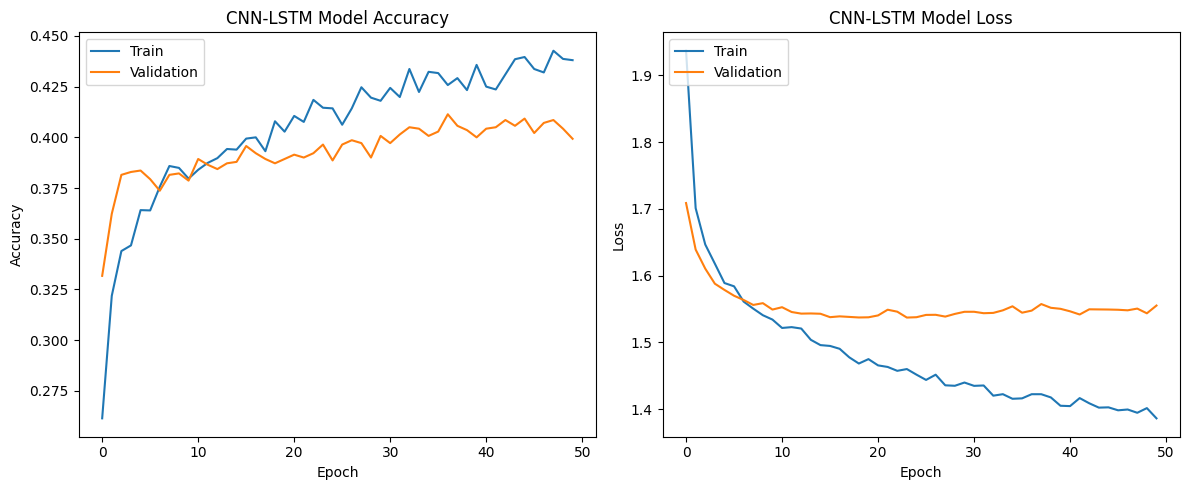

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'history_cnn_lstm' object is available from the model training cell (33f5af2d)

if 'history_cnn_lstm' in locals():
    print("Plotting CNN-LSTM training history...")
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_cnn_lstm.history['accuracy'])
    plt.plot(history_cnn_lstm.history['val_accuracy'])
    plt.title('CNN-LSTM Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history_cnn_lstm.history['loss'])
    plt.plot(history_cnn_lstm.history['val_loss'])
    plt.title('CNN-LSTM Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("CNN-LSTM model training history not found. Please ensure the model training cell (33f5af2d) was run successfully.")

### Step 8: Confusion Matrix for CNN-LSTM Model

This step involves generating and displaying the confusion matrix to visualize the performance of the CNN-LSTM model across different emotion classes.

Generating confusion matrix for CNN-LSTM model...


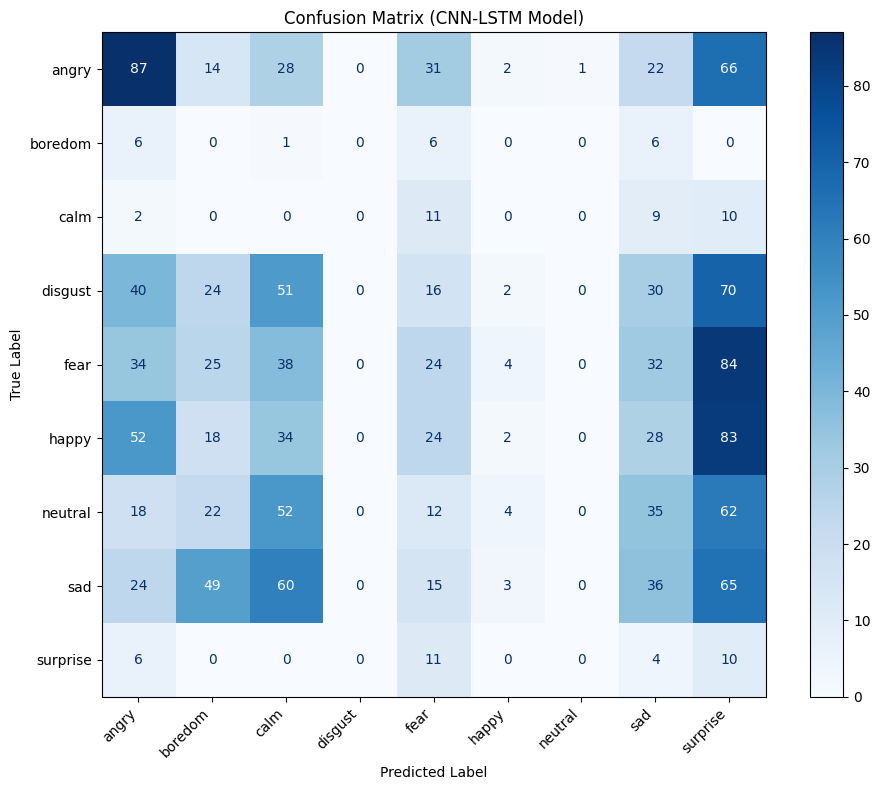

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Ensure y_true_lstm and y_pred_lstm are available from the evaluation cell (above)
# Ensure label_encoder is available from data preparation (cell 75bea77e)

if 'y_true_lstm' in locals() and 'y_pred_lstm' in locals():
    print("Generating confusion matrix for CNN-LSTM model...")
    # Generate the confusion matrix
    cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)

    # Get the class names from the label encoder
    if 'label_encoder' in locals():
        class_names = label_encoder.classes_
    else:
        # Fallback if label_encoder is not found
        class_names = [str(i) for i in range(cm_lstm.shape[0])]
        print("Warning: label_encoder not found, using integer labels for confusion matrix.")


    # Display the confusion matrix using ConfusionMatrixDisplay
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title('Confusion Matrix (CNN-LSTM Model)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping confusion matrix. Please ensure the model evaluation cell (above) was run successfully.")

# save model to disk > API

In [ ]:
import joblib
import os

# Define the directory to save the model
model_dir = "/content/drive/MyDrive/models" # You can change this path if needed
os.makedirs(model_dir, exist_ok=True)

# Define the filename for the saved model
svm_model_filename = os.path.join(model_dir, "best_svm_model.joblib")
label_encoder_filename = os.path.join(model_dir, "label_encoder.joblib")
scaler_filename = os.path.join(model_dir, "scaler.joblib")


# Check if best_svm_model, label_encoder, and scaler are defined
if 'best_svm_model' in locals() and best_svm_model is not None:
    # Save the best_svm_model to disk
    joblib.dump(best_svm_model, svm_model_filename)
    print(f"Best SVM model saved to: {svm_model_filename}")
else:
    print("Error: best_svm_model is not defined. Please run the SVM training and tuning cells first.")

if 'label_encoder' in locals() and label_encoder is not None:
    # Save the label_encoder to disk (needed for mapping predictions back to labels)
    joblib.dump(label_encoder, label_encoder_filename)
    print(f"Label encoder saved to: {label_encoder_filename}")
else:
    print("Warning: label_encoder is not defined. You might need it to interpret predictions.")


if 'scaler' in locals() and scaler is not None:
    # Save the scaler to disk (needed for scaling new data before prediction)
    joblib.dump(scaler, scaler_filename)
    print(f"Scaler saved to: {scaler_filename}")
else:
    print("Warning: scaler is not defined. You will need to scale new data before using the saved model.")

Best SVM model saved to: /content/drive/MyDrive/models/best_svm_model.joblib
Label encoder saved to: /content/drive/MyDrive/models/label_encoder.joblib
Scaler saved to: /content/drive/MyDrive/models/scaler.joblib


In [ ]:
import joblib
import os
import numpy as np
import librosa
import pandas as pd # Needed for DataFrame creation for scaling

# Define the directory where the model files are saved
model_dir = "/content/drive/MyDrive/models" # Ensure this path is accessible in your API environment

# Define the target sample rate used during training
TARGET_SAMPLE_RATE = 16000 # Make sure this matches the rate used in preprocessing (cell 0soCkKWhl-Ey)
N_MFCC = 13 # Make sure this matches the number of MFCCs used (cell VQ6SU9DbYoy4 or a5cb44e3)


# --- Load Saved Components ---
try:
    loaded_svm_model = joblib.load(os.path.join(model_dir, "best_svm_model.joblib"))
    loaded_label_encoder = joblib.load(os.path.join(model_dir, "label_encoder.joblib"))
    loaded_scaler = joblib.load(os.path.join(model_dir, "scaler.joblib"))
    print("Saved model components loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading saved model components: {e}")
    print("Please ensure the model files exist in the specified model_dir.")
    loaded_svm_model = loaded_label_encoder = loaded_scaler = None


# --- Function to Preprocess and Predict for New Audio ---
def predict_emotion(audio_path, model, scaler, label_encoder, sr=TARGET_SAMPLE_RATE, n_mfcc=N_MFCC):
    """
    Loads an audio file, extracts features, scales them, and predicts the emotion.

    Args:
        audio_path (str): Path to the new audio file.
        model: Loaded trained SVM model.
        scaler: Loaded fitted StandardScaler.
        label_encoder: Loaded fitted LabelEncoder.
        sr (int): Target sample rate.
        n_mfcc (int): Number of MFCC features to extract.

    Returns:
        str: Predicted emotion label, or None if processing fails.
    """
    if model is None or scaler is None or label_encoder is None:
        print("Error: Model components not loaded. Cannot make prediction.")
        return None

    try:
        # 1. Load and Resample Audio
        y, current_sr = librosa.load(audio_path, sr=sr) # librosa automatically resamples if sr is specified

        # 2. Extract Features (MFCC mean)
        # Apply the same feature extraction logic as used during training
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean_features = np.mean(mfccs, axis=1) # Shape (n_mfcc,)

        # You would also extract pitch and energy if they were used in your training data
        # For this example, we only used MFCC means based on the simplified preparation in cell a5cb44e3
        # If pitch and energy were used, you'd calculate them here:
        # pitch_mean, energy_mean = pitch_energy(audio_path) # Need the pitch_energy function defined

        # Combine all features into a single feature vector (matching the training data)
        # If you only used MFCCs:
        feature_vector = mfcc_mean_features

        # If you used MFCCs, pitch, and energy, you'd combine them like this (ensure order matches training data):
        # feature_vector = np.concatenate((mfcc_mean_features, [pitch_mean], [energy_mean])) # Needs pitch_mean and energy_mean to be calculated and not NaN


        # Ensure feature_vector is 2D for scaling (scaler expects [n_samples, n_features])
        feature_vector_2d = feature_vector.reshape(1, -1)

        # 3. Scale Features
        scaled_features = scaler.transform(feature_vector_2d)

        # 4. Make a Prediction
        predicted_label_encoded = model.predict(scaled_features) # Returns 1D array of encoded labels

        # 5. Decode the Prediction
        predicted_label = label_encoder.inverse_transform(predicted_label_encoded)

        return predicted_label[0] # Return the first (and only) predicted label

    except Exception as e:
        print(f"Error during prediction: {e}")
        return None

# --- Example Usage (Assuming you have a test audio file) ---
# Replace 'path/to/your/test_audio.wav' with the actual path to an audio file
# Example: Use a path from your test set DataFrame (if available)
# test_audio_path = segmented_df[segmented_df['split'] == 'test']['path'].iloc[0] # Get a path from your test set

# For demonstration, let's assume a dummy path (replace with real path for testing)
# You would load audio from your API request here
dummy_audio_path = "/content/drive/MyDrive/datasets/Segmented_Audio/CREMA-D_CREMA_1001_1001_DFA_ANG_XX_rs16k_trim_clean_seg_000.wav" # Example path from your data

if loaded_svm_model is not None and os.path.exists(dummy_audio_path):
    print(f"\nAttempting to predict emotion for: {dummy_audio_path}")
    predicted_emotion = predict_emotion(dummy_audio_path, loaded_svm_model, loaded_scaler, loaded_label_encoder)

    if predicted_emotion:
        print(f"Predicted Emotion: {predicted_emotion}")
    else:
        print("Failed to predict emotion.")
elif not os.path.exists(dummy_audio_path):
    print(f"\nDummy audio file not found at {dummy_audio_path}. Cannot run example prediction.")

Saved model components loaded successfully.

Dummy audio file not found at /content/drive/MyDrive/datasets/Segmented_Audio/CREMA-D_CREMA_1001_1001_DFA_ANG_XX_rs16k_trim_clean_seg_000.wav. Cannot run example prediction.


**Integration into an API Framework (e.g., Flask):**

To use this in a web API, you would typically:

1.  Install a web framework (e.g., `pip install Flask` or `pip install fastapi uvicorn`).
2.  Create a Flask/FastAPI application.
3.  Load the model components *once* when the application starts (e.g., in a global variable or within the app's initialization).
4.  Define an API endpoint (e.g., `/predict_emotion`).
5.  This endpoint would accept incoming audio data (e.g., via a POST request).
6.  Inside the endpoint function, save the incoming audio temporarily to a file or process it from memory.
7.  Call the `predict_emotion` function with the path to the new audio data (or process the audio stream directly).
8.  Return the predicted emotion label as a JSON response.

Here's a *very basic* conceptual Flask example (requires more error handling and proper file handling):

In [ ]:
from google.colab import files

# Replace the path with your actual saved paths
files.download('/content/drive/MyDrive/models/best_svm_model.joblib')
files.download('/content/drive/MyDrive/models/scaler.joblib')
files.download('/content/drive/MyDrive/models/label_encoder.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>